<a href="https://colab.research.google.com/github/Shamima21/TumorPhylogenyLearning/blob/main/Feature_corelation__Learning_Conserved_Evolutionary_Patterns_of_Cancer_Metastasis_from_Tumour_Phylogenies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1. SETUP
# ============================================================

required_packages <- c(
  "igraph",
  "dplyr",
  "tidyr",
  "ggplot2",
  "purrr",
  "tibble",
  "cluster"
)

new_packages <- required_packages[
  !(required_packages %in% installed.packages()[, "Package"])
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}

library(igraph)
library(dplyr)
library(tidyr)
library(ggplot2)
library(purrr)
library(tibble)
library(cluster)

set.seed(42)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘purrr’


The following objects are masked from ‘package:igraph’:

    compose, simplify



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [ ]:
# ============================================================
# 2. LOAD DATA
# ============================================================

tree_file <- "/content/sample_data/20221109_TRACERx421_phylogenetic_trees.rds"

stopifnot(file.exists(tree_file))

trees <- readRDS(tree_file)

cat("Object class:", class(trees), "\n")
cat("Number of entries:", length(trees), "\n")
cat("First patient IDs:\n")

head(names(trees))

Object class: list 
Number of entries: 403 
First patient IDs:


[1] "CRUK0005" "CRUK0057" "CRUK0039" "CRUK0196" "CRUK0023" "CRUK0050"

In [ ]:
# ============================================================
# 3. TREE STANDARDIZATION
# ============================================================

standardize_tree <- function(patient_object, patient_id = NA_character_) {

  corrected_tree <- patient_object$graph_pyclone$Corrected_tree
  trunk <- patient_object$graph_pyclone$trunk
  edge_lengths <- patient_object$graph_pyclone$edgelength

  # No valid tree
  if (is.null(corrected_tree) || length(corrected_tree) == 0) {
    return(NULL)
  }

  # Convert edge matrix into data frame
  edges <- as.data.frame(
    corrected_tree,
    stringsAsFactors = FALSE
  )

  if (ncol(edges) < 2) {
    return(NULL)
  }

  edges <- edges[, 1:2]

  colnames(edges) <- c("parent", "child")

  edges$parent <- as.character(edges$parent)
  edges$child  <- as.character(edges$child)

  trunk <- as.character(trunk)

  # Construct directed graph
  g <- graph_from_data_frame(
    edges,
    directed = TRUE
  )

  # Identify node types
  nodes <- tibble(
    cluster = V(g)$name,
    indegree = degree(g, mode = "in"),
    outdegree = degree(g, mode = "out")
  ) %>%
    mutate(
      node_type = case_when(
        cluster == trunk ~ "Trunk",
        outdegree == 0 ~ "Terminal",
        TRUE ~ "Internal"
      )
    )

  # Add mutation counts if available
  if (!is.null(edge_lengths)) {

    mutation_table <- tibble(
      cluster = as.character(names(edge_lengths)),
      mutation_count = as.numeric(edge_lengths)
    )

    nodes <- nodes %>%
      left_join(
        mutation_table,
        by = "cluster"
      )
  } else {

    nodes$mutation_count <- NA_real_

  }

  return(
    list(
      patient_id = patient_id,
      graph = g,
      edges = edges,
      nodes = nodes,
      trunk = trunk
    )
  )
}

In [ ]:
#TEST
test_tree <- standardize_tree(
  trees[["CRUK0005"]],
  "CRUK0005"
)

test_tree$edges
test_tree$nodes
test_tree$trunk

parent,child
<chr>,<chr>
4,3
2,4
19,5
3,9
13,12
9,13
12,18
20,19
3,20


cluster,indegree,outdegree,node_type,mutation_count
<chr>,<dbl>,<dbl>,<chr>,<dbl>
4,1,1,Internal,177
2,0,2,Trunk,259
19,1,1,Internal,8
3,1,2,Internal,184
13,1,2,Internal,12
9,1,1,Internal,25
12,1,1,Internal,15
20,1,1,Internal,6
5,1,1,Internal,95


[1] "2"

In [ ]:
#CHECK TREE QUALITY
#====================================================
#verify:

#The tree exists.
#The root exists.
#The root has no parent.
#The graph is connected.
#The graph is acyclic (a DAG).
#Every non-root node has exactly one parent.
#A tree with V nodes must have exactly V−1 edges.
#===================================================


validate_tree <- function(std_tree) {

  # Check if the tree exists
  if (is.null(std_tree)) {
    return(FALSE)
  }

  g <- std_tree$graph
  root <- std_tree$trunk

  # Check if the root node exists
  if (!(root %in% V(g)$name)) {
    return(FALSE)
  }

  # Root should have no parent
  root_indegree <- degree(g, v = root, mode = "in")

  # Every non-root node should have exactly one parent
  indegrees <- degree(g, mode = "in")
  non_root <- V(g)$name != root
  valid_parents <- all(indegrees[non_root] == 1)

  # Tree should be connected
  connected <- is_connected(as_undirected(g))

  # Tree should contain no cycles
  acyclic <- is_dag(g)

  # A tree must satisfy |E| = |V| - 1
  valid_edges <- (ecount(g) == vcount(g) - 1)

  return(
    root_indegree == 0 &&
    valid_parents &&
    connected &&
    acyclic &&
    valid_edges
  )
}

In [ ]:
#Standardize all patient trees  And keep the valid ones:
standardized_trees <- map2(
  trees,
  names(trees),
  ~ standardize_tree(.x, .y)
)

names(standardized_trees) <- names(trees)
valid_tree <- map_lgl(
  standardized_trees,
  validate_tree
)

table(valid_tree)
standardized_trees_valid <-
  standardized_trees[valid_tree]

length(standardized_trees_valid)

valid_tree
FALSE  TRUE 
    5   398 

[1] 398

In [ ]:
# ============================================================
# 4. QUANTITATIVE FEATURE EXTRACTION
# ============================================================

extract_tree_features <- function(std_tree) {

  g <- std_tree$graph
  nodes <- std_tree$nodes
  root <- std_tree$trunk

  # Basic counts
  n_nodes <- vcount(g)
  n_edges <- ecount(g)

  n_terminal <- sum(
    nodes$node_type == "Terminal"
  )

  n_internal <- sum(
    nodes$node_type == "Internal"
  )

  n_branching <- sum(
    nodes$outdegree > 1
  )

  # Degree-based features
  max_outdegree <- max(
    nodes$outdegree,
    na.rm = TRUE
  )

  mean_outdegree <- mean(
    nodes$outdegree,
    na.rm = TRUE
  )

  # Distance from root
  d <- distances(
    g,
    v = root,
    to = V(g),
    mode = "out"
  )

  depths <- as.numeric(d[1, ])

  depths <- depths[
    is.finite(depths)
  ]

  max_depth <- max(depths)
  mean_depth <- mean(depths)

  # Terminal-node depths
  terminal_nodes <- nodes$cluster[
    nodes$node_type == "Terminal"
  ]

  terminal_depths <- distances(
    g,
    v = root,
    to = terminal_nodes,
    mode = "out"
  )

  terminal_depths <-
    as.numeric(terminal_depths[1, ])

  mean_terminal_depth <-
    mean(terminal_depths)

  max_terminal_depth <-
    max(terminal_depths)

  # Mutation-related features
  mut <- nodes$mutation_count

  total_mutations <- sum(
    mut,
    na.rm = TRUE
  )

  mean_mutations <- mean(
    mut,
    na.rm = TRUE
  )

  max_mutations <- max(
    mut,
    na.rm = TRUE
  )

  # Trunk mutation count
  trunk_mutations <- nodes %>%
    filter(cluster == root) %>%
    pull(mutation_count)

  if (length(trunk_mutations) == 0) {
    trunk_mutations <- NA_real_
  }

  tibble(
    patient_id = std_tree$patient_id,

    n_nodes = n_nodes,
    n_edges = n_edges,

    n_internal = n_internal,
    n_terminal = n_terminal,
    n_branching_nodes = n_branching,

    max_outdegree = max_outdegree,
    mean_outdegree = mean_outdegree,

    max_depth = max_depth,
    mean_depth = mean_depth,

    mean_terminal_depth = mean_terminal_depth,
    max_terminal_depth = max_terminal_depth,

    trunk_mutations = trunk_mutations,
    total_mutations = total_mutations,
    mean_mutations_per_clone = mean_mutations,
    max_mutations_per_clone = max_mutations
  )
}

In [ ]:
#Test on one patient:

extract_tree_features(test_tree)

patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,max_terminal_depth,trunk_mutations,total_mutations,mean_mutations_per_clone,max_mutations_per_clone
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,5,7,259,1321,88.06667,462


In [ ]:
# ============================================================
# 5. CREATE FEATURE MATRIX
# ============================================================

feature_matrix <- purrr::map_dfr(
  standardized_trees,
  extract_tree_features
)

# Check result
dim(feature_matrix)
head(feature_matrix)
summary(feature_matrix)

Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”


[1] 403  16

patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,max_terminal_depth,trunk_mutations,total_mutations,mean_mutations_per_clone,max_mutations_per_clone
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,5.000000,7,259,1321,88.06667,462
CRUK0057,6,5,3,2,1,2,0.8333333,3,1.500000,2.500000,3,1040,1149,191.50000,1040
CRUK0039,5,4,2,2,1,2,0.8000000,2,1.200000,2.000000,2,1003,1099,219.80000,1003
CRUK0196,7,6,3,3,2,2,0.8571429,3,1.714286,2.666667,3,652,724,103.42857,652
CRUK0023,11,10,6,4,2,3,0.9090909,4,2.000000,2.750000,4,220,351,31.90909,220
CRUK0050,4,3,1,2,1,2,0.7500000,2,1.250000,2.000000,2,176,197,49.25000,176


     patient_id     n_nodes         n_edges         n_internal    
 Length   :403   Min.   : 1.00   Min.   : 1.000   Min.   : 0.000  
 N.unique :403   1st Qu.: 6.00   1st Qu.: 5.000   1st Qu.: 2.000  
 N.blank  :  0   Median : 9.00   Median : 8.000   Median : 5.000  
 Min.nchar:  8   Mean   :10.15   Mean   : 9.164   Mean   : 5.643  
 Max.nchar: 16   3rd Qu.:13.00   3rd Qu.:12.000   3rd Qu.: 8.000  
                 Max.   :40.00   Max.   :39.000   Max.   :31.000  
                                                                  
   n_terminal     n_branching_nodes max_outdegree   mean_outdegree  
 Min.   : 0.000   Min.   :0.000     Min.   :1.000   Min.   :0.5000  
 1st Qu.: 2.000   1st Qu.:1.000     1st Qu.:2.000   1st Qu.:0.8333  
 Median : 3.000   Median :2.000     Median :2.000   Median :0.8889  
 Mean   : 3.509   Mean   :2.012     Mean   :2.382   Mean   :0.8632  
 3rd Qu.: 4.000   3rd Qu.:3.000     3rd Qu.:3.000   3rd Qu.:0.9286  
 Max.   :10.000   Max.   :7.000     Max.   :7.000 

In [ ]:
#sAVE ALL FEATURES
write.csv(
  feature_matrix,
  "TRACERx421_tree_features.csv",
  row.names = FALSE
)

In [ ]:
# ============================================================
# BIOLOGICAL / EVOLUTIONARY FEATURE EXTRACTION
# ============================================================

extract_biological_features <- function(std_tree) {

  if (is.null(std_tree)) {
    return(NULL)
  }

  g     <- std_tree$graph
  nodes <- std_tree$nodes
  root  <- std_tree$trunk

  # ----------------------------------------------------------
  # 1. Mutation information
  # ----------------------------------------------------------

  mut <- nodes$mutation_count

  # Total mutation burden
  total_mutations <- sum(mut, na.rm = TRUE)

  # Trunk mutation burden
  trunk_mutations <- nodes$mutation_count[
    nodes$cluster == root
  ]

  if (length(trunk_mutations) == 0 ||
      is.na(trunk_mutations)) {
    trunk_mutations <- 0
  }

  # Branch mutations = all non-trunk mutations
  branch_mutations <- sum(
    nodes$mutation_count[
      nodes$cluster != root
    ],
    na.rm = TRUE
  )

  # ----------------------------------------------------------
  # 2. Trunk vs branch mutation contribution
  # ----------------------------------------------------------

  if (total_mutations > 0) {

    trunk_mutation_fraction <-
      trunk_mutations / total_mutations

    branch_mutation_fraction <-
      branch_mutations / total_mutations

  } else {

    trunk_mutation_fraction <- NA_real_
    branch_mutation_fraction <- NA_real_
  }

  # Ratio between early and later mutation burden
  if (branch_mutations > 0) {

    trunk_branch_ratio <-
      trunk_mutations / branch_mutations

  } else {

    trunk_branch_ratio <- NA_real_
  }

  # ----------------------------------------------------------
  # 3. Branch mutation heterogeneity
  # ----------------------------------------------------------

  non_trunk_mutations <- nodes$mutation_count[
    nodes$cluster != root
  ]

  mean_branch_mutations <- mean(
    non_trunk_mutations,
    na.rm = TRUE
  )

  sd_branch_mutations <- sd(
    non_trunk_mutations,
    na.rm = TRUE
  )

  branch_mutation_variance <- var(
    non_trunk_mutations,
    na.rm = TRUE
  )

  # ----------------------------------------------------------
  # 4. Diversification timing
  # ----------------------------------------------------------

  # Distance of every node from root
  depth_matrix <- distances(
    g,
    v = root,
    to = V(g),
    mode = "out"
  )

  node_depth <- as.numeric(depth_matrix[1, ])

  names(node_depth) <- V(g)$name

  # Nodes that create more than one descendant branch
  branching_nodes <- nodes$cluster[
    nodes$outdegree > 1
  ]

  if (length(branching_nodes) > 0) {

    branching_depths <-
      node_depth[branching_nodes]

    first_branching_depth <-
      min(branching_depths, na.rm = TRUE)

    mean_branching_depth <-
      mean(branching_depths, na.rm = TRUE)

  } else {

    first_branching_depth <- NA_real_
    mean_branching_depth <- NA_real_
  }

  max_depth <- max(
    node_depth[is.finite(node_depth)],
    na.rm = TRUE
  )

  # Normalize diversification timing
  if (!is.na(first_branching_depth) &&
      max_depth > 0) {

    diversification_timing <-
      first_branching_depth / max_depth

  } else {

    diversification_timing <- NA_real_
  }

  # ----------------------------------------------------------
  # Return patient-level biological/evolutionary features
  # ----------------------------------------------------------

  tibble(
    patient_id = std_tree$patient_id,

    trunk_mutations = trunk_mutations,
    branch_mutations = branch_mutations,

    trunk_mutation_fraction =
      trunk_mutation_fraction,

    branch_mutation_fraction =
      branch_mutation_fraction,

    trunk_branch_ratio =
      trunk_branch_ratio,

    mean_branch_mutations =
      mean_branch_mutations,

    sd_branch_mutations =
      sd_branch_mutations,

    branch_mutation_variance =
      branch_mutation_variance,

    first_branching_depth =
      first_branching_depth,

    mean_branching_depth =
      mean_branching_depth,

    diversification_timing =
      diversification_timing
  )
}

In [ ]:
#for all patients
biological_feature_matrix <- map_dfr(
  standardized_trees_valid,
  extract_biological_features
)

dim(biological_feature_matrix)

head(biological_feature_matrix)

#save:

write.csv(
  biological_feature_matrix,
  "TRACERx421_biological_features.csv",
  row.names = FALSE
)

[1] 398  12

patient_id,trunk_mutations,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,259,1062,0.1960636,0.80393641,0.2438795,75.85714,127.066220,16145.82418,0,2.0,0.0
CRUK0057,1040,109,0.9051349,0.09486510,9.5412844,21.80000,14.686729,215.70000,0,0.0,0.0
CRUK0039,1003,96,0.9126479,0.08735214,10.4479167,24.00000,17.606817,310.00000,0,0.0,0.0
CRUK0196,652,72,0.9005525,0.09944751,9.0555556,12.00000,5.585696,31.20000,0,1.0,0.0
CRUK0023,220,131,0.6267806,0.37321937,1.6793893,13.10000,8.685237,75.43333,0,0.5,0.0
CRUK0050,176,21,0.8934010,0.10659898,8.3809524,7.00000,1.732051,3.00000,1,1.0,0.5


In [ ]:
# ============================================================
# 6. PATIENT-LEVEL EVOLUTIONARY FEATURE MATRIX
#    Combine Structural + Biological Features
# ============================================================

library(dplyr)

# ------------------------------------------------------------
# 1. Check dimensions of the two matrices
# ------------------------------------------------------------

cat("Structural feature matrix:",
    nrow(feature_matrix), "patients x",
    ncol(feature_matrix), "columns\n")

cat("Biological feature matrix:",
    nrow(biological_feature_matrix), "patients x",
    ncol(biological_feature_matrix), "columns\n")


# ------------------------------------------------------------
# 2. Check patient overlap
# ------------------------------------------------------------

common_patients <- intersect(
  feature_matrix$patient_id,
  biological_feature_matrix$patient_id
)

cat("Patients present in both matrices:",
    length(common_patients), "\n")


# Patients present only in structural matrix
structural_only <- setdiff(
  feature_matrix$patient_id,
  biological_feature_matrix$patient_id
)

# Patients present only in biological matrix
biological_only <- setdiff(
  biological_feature_matrix$patient_id,
  feature_matrix$patient_id
)

cat("Structural only:", length(structural_only), "\n")
cat("Biological only:", length(biological_only), "\n")


# ------------------------------------------------------------
# 3. Remove duplicated feature names before merging
# ------------------------------------------------------------

# trunk_mutations occurs in BOTH matrices.
# Keep it from the structural matrix and remove the duplicate
# from the biological matrix.

biological_features_clean <- biological_feature_matrix %>%
  select(
    -trunk_mutations
  )


# ------------------------------------------------------------
# 4. Merge by patient_id
# ------------------------------------------------------------

patient_level_feature_matrix <- feature_matrix %>%
  inner_join(
    biological_features_clean,
    by = "patient_id"
  )


# ------------------------------------------------------------
# 5. Inspect final patient-level matrix
# ------------------------------------------------------------

cat(
  "\nFinal Patient-Level Evolutionary Feature Matrix:\n"
)

cat(
  nrow(patient_level_feature_matrix),
  "patients x",
  ncol(patient_level_feature_matrix),
  "columns\n"
)

head(patient_level_feature_matrix)

summary(patient_level_feature_matrix)

Structural feature matrix: 403 patients x 16 columns
Biological feature matrix: 398 patients x 12 columns
Patients present in both matrices: 398 
Structural only: 5 
Biological only: 0 

Final Patient-Level Evolutionary Feature Matrix:
398 patients x 26 columns


patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,⋯,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,⋯,1062,0.1960636,0.80393641,0.2438795,75.85714,127.066220,16145.82418,0,2.0,0.0
CRUK0057,6,5,3,2,1,2,0.8333333,3,1.500000,⋯,109,0.9051349,0.09486510,9.5412844,21.80000,14.686729,215.70000,0,0.0,0.0
CRUK0039,5,4,2,2,1,2,0.8000000,2,1.200000,⋯,96,0.9126479,0.08735214,10.4479167,24.00000,17.606817,310.00000,0,0.0,0.0
CRUK0196,7,6,3,3,2,2,0.8571429,3,1.714286,⋯,72,0.9005525,0.09944751,9.0555556,12.00000,5.585696,31.20000,0,1.0,0.0
CRUK0023,11,10,6,4,2,3,0.9090909,4,2.000000,⋯,131,0.6267806,0.37321937,1.6793893,13.10000,8.685237,75.43333,0,0.5,0.0
CRUK0050,4,3,1,2,1,2,0.7500000,2,1.250000,⋯,21,0.8934010,0.10659898,8.3809524,7.00000,1.732051,3.00000,1,1.0,0.5


     patient_id     n_nodes         n_edges         n_internal    
 Length   :398   Min.   : 2.00   Min.   : 1.000   Min.   : 0.000  
 N.unique :398   1st Qu.: 6.00   1st Qu.: 5.000   1st Qu.: 2.000  
 N.blank  :  0   Median : 9.00   Median : 8.000   Median : 5.000  
 Min.nchar:  8   Mean   :10.27   Mean   : 9.266   Mean   : 5.714  
 Max.nchar: 16   3rd Qu.:13.00   3rd Qu.:12.000   3rd Qu.: 8.000  
                 Max.   :40.00   Max.   :39.000   Max.   :31.000  
                                                                  
   n_terminal     n_branching_nodes max_outdegree   mean_outdegree  
 Min.   : 1.000   Min.   :0.000     Min.   :1.000   Min.   :0.5000  
 1st Qu.: 2.000   1st Qu.:1.000     1st Qu.:2.000   1st Qu.:0.8333  
 Median : 3.000   Median :2.000     Median :2.000   Median :0.8889  
 Mean   : 3.553   Mean   :2.038     Mean   :2.399   Mean   :0.8615  
 3rd Qu.: 4.000   3rd Qu.:3.000     3rd Qu.:3.000   3rd Qu.:0.9231  
 Max.   :10.000   Max.   :7.000     Max.   :7.000 

In [ ]:
# ============================================================
# SAVE FINAL PATIENT-LEVEL FEATURE MATRIX
# ============================================================

write.csv(
  patient_level_feature_matrix,
  "TRACERx421_patient_level_evolutionary_feature_matrix.csv",
  row.names = FALSE
)

cat(
  "Saved: TRACERx421_patient_level_evolutionary_feature_matrix.csv\n"
)

Saved: TRACERx421_patient_level_evolutionary_feature_matrix.csv


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




Number of patients: 398 
Number of evolutionary features: 25 
Missing values: 83 
Non-finite values: 83 

Features used for correlation: 25 

ALL SPEARMAN CORRELATION PAIRS
                   Feature_1                Feature_2 Spearman_rho      P_value
1                    n_nodes                  n_edges  1.000000000 0.000000e+00
2                    n_nodes           mean_outdegree  1.000000000 0.000000e+00
3                    n_edges           mean_outdegree  1.000000000 0.000000e+00
4                  max_depth       max_terminal_depth  1.000000000 0.000000e+00
5    trunk_mutation_fraction branch_mutation_fraction -1.000000000 0.000000e+00
6    trunk_mutation_fraction       trunk_branch_ratio  1.000000000 0.000000e+00
7   branch_mutation_fraction       trunk_branch_ratio -1.000000000 0.000000e+00
8        sd_branch_mutations branch_mutation_variance  1.000000000 0.000000e+00
9      first_branching_depth   diversification_timing  0.995778614 0.000000e+00
10           trunk_mutation



Table: Strong associations among evolutionary features (|rho| > 0.70)

|Feature 1                |Feature 2                | Spearman rho | FDR-adjusted p |
|:------------------------|:------------------------|:------------:|:--------------:|
|n_nodes                  |n_edges                  |    1.000     |     <0.001     |
|n_nodes                  |mean_outdegree           |    1.000     |     <0.001     |
|n_edges                  |mean_outdegree           |    1.000     |     <0.001     |
|max_depth                |max_terminal_depth       |    1.000     |     <0.001     |
|trunk_mutation_fraction  |branch_mutation_fraction |    -1.000    |     <0.001     |
|trunk_mutation_fraction  |trunk_branch_ratio       |    1.000     |     <0.001     |
|branch_mutation_fraction |trunk_branch_ratio       |    -1.000    |     <0.001     |
|sd_branch_mutations      |branch_mutation_variance |    1.000     |     <0.001     |
|first_branching_depth    |diversification_timing   |    0.996     


TOP 10 FEATURE ASSOCIATIONS





Table: Top 10 Spearman correlations among evolutionary features

|Feature 1                |Feature 2                | Spearman rho | FDR-adjusted p |
|:------------------------|:------------------------|:------------:|:--------------:|
|n_nodes                  |n_edges                  |    1.000     |     <0.001     |
|n_nodes                  |mean_outdegree           |    1.000     |     <0.001     |
|n_edges                  |mean_outdegree           |    1.000     |     <0.001     |
|max_depth                |max_terminal_depth       |    1.000     |     <0.001     |
|trunk_mutation_fraction  |branch_mutation_fraction |    -1.000    |     <0.001     |
|trunk_mutation_fraction  |trunk_branch_ratio       |    1.000     |     <0.001     |
|branch_mutation_fraction |trunk_branch_ratio       |    -1.000    |     <0.001     |
|sd_branch_mutations      |branch_mutation_variance |    1.000     |     <0.001     |
|first_branching_depth    |diversification_timing   |    0.996     |     


SPEARMAN CORRELATION ANALYSIS COMPLETE
Number of features analyzed: 25 
Total unique feature pairs: 300 
Strongly correlated pairs |rho| > 0.70: 66 

Results and figures saved successfully.


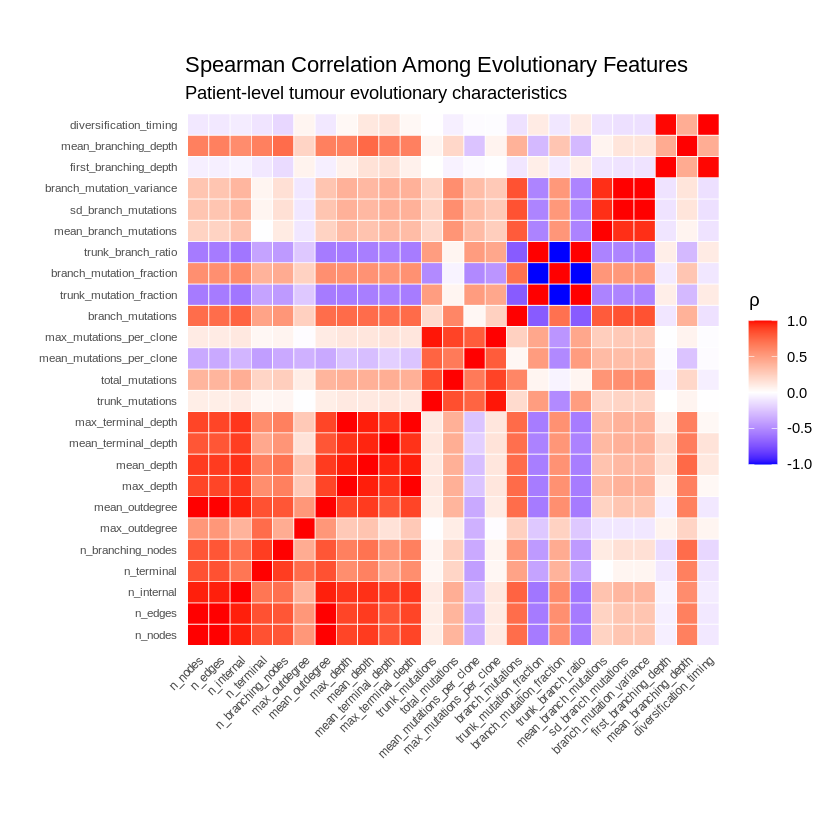

In [ ]:
# ============================================================
# SPEARMAN CORRELATION ANALYSIS
# Evolutionary features capture related but
# non-redundant properties
# ============================================================


# ============================================================
# 0. INSTALL AND LOAD REQUIRED PACKAGES
# ============================================================

packages <- c(
  "ggplot2",
  "dplyr",
  "tidyr",
  "Hmisc",
  "knitr"
)

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(ggplot2)
library(dplyr)
library(tidyr)
library(Hmisc)
library(knitr)


# ============================================================
# 1. PREPARE NUMERIC EVOLUTIONARY FEATURES
# ============================================================

cor_features <- patient_level_feature_matrix %>%
  select(-patient_id) %>%
  select(where(is.numeric))


cat(
  "Number of patients:",
  nrow(cor_features),
  "\n"
)

cat(
  "Number of evolutionary features:",
  ncol(cor_features),
  "\n"
)


# ============================================================
# 2. CHECK MISSING AND NON-FINITE VALUES
# ============================================================

cat(
  "Missing values:",
  sum(is.na(cor_features)),
  "\n"
)

cat(
  "Non-finite values:",
  sum(!is.finite(as.matrix(cor_features))),
  "\n"
)


# Convert Inf/-Inf to NA
cor_features[] <- lapply(
  cor_features,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)


# ============================================================
# 3. REMOVE FEATURES WITH NO VARIATION
# ============================================================

keep_features <- sapply(
  cor_features,
  function(x) {

    values <- x[!is.na(x)]

    length(values) > 1 &&
      length(unique(values)) > 1
  }
)

if (any(!keep_features)) {

  cat(
    "\nRemoved constant/non-informative features:\n"
  )

  print(
    names(cor_features)[!keep_features]
  )
}

cor_features <- cor_features[
  ,
  keep_features,
  drop = FALSE
]


cat(
  "\nFeatures used for correlation:",
  ncol(cor_features),
  "\n"
)


# ============================================================
# 4. SPEARMAN CORRELATION
# ============================================================

spearman_result <- Hmisc::rcorr(
  as.matrix(cor_features),
  type = "spearman"
)


# Correlation matrix
cor_matrix <- spearman_result$r

# Raw p-value matrix
p_matrix <- spearman_result$P


# ============================================================
# 5. EXTRACT UNIQUE FEATURE PAIRS
# ============================================================

upper_index <- upper.tri(
  cor_matrix,
  diag = FALSE
)

row_index <- row(cor_matrix)[upper_index]

col_index <- col(cor_matrix)[upper_index]


correlation_pairs <- data.frame(

  Feature_1 =
    rownames(cor_matrix)[row_index],

  Feature_2 =
    colnames(cor_matrix)[col_index],

  Spearman_rho =
    cor_matrix[upper_index],

  P_value =
    p_matrix[upper_index]
)


# ============================================================
# 6. FDR CORRECTION
# Benjamini-Hochberg method
# ============================================================

correlation_pairs$FDR_adjusted_p <- p.adjust(
  correlation_pairs$P_value,
  method = "BH"
)


# Calculate absolute rho
correlation_pairs$Absolute_rho <- abs(
  correlation_pairs$Spearman_rho
)


# Sort strongest correlations first
correlation_pairs <- correlation_pairs %>%
  arrange(
    desc(Absolute_rho)
  )


# ============================================================
# 7. DISPLAY ALL CORRELATION RESULTS
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "ALL SPEARMAN CORRELATION PAIRS\n"
)

cat(
  "========================================\n"
)

print(
  correlation_pairs
)


# ============================================================
# 8. IDENTIFY STRONGLY CORRELATED FEATURES
# Threshold: |rho| > 0.70
# ============================================================

strong_correlations <- correlation_pairs %>%

  filter(
    Absolute_rho > 0.70
  )


cat(
  "\n========================================\n"
)

cat(
  "STRONG CORRELATIONS |rho| > 0.70\n"
)

cat(
  "========================================\n"
)

print(
  strong_correlations
)


# ============================================================
# 9. CREATE CLEAN TABLE 4.3
# ============================================================

strong_table <- strong_correlations %>%

  mutate(

    Spearman_rho =
      round(
        Spearman_rho,
        3
      ),

    FDR_adjusted_p =
      ifelse(
        FDR_adjusted_p < 0.001,
        "<0.001",
        sprintf(
          "%.3f",
          FDR_adjusted_p
        )
      )

  ) %>%

  select(
    Feature_1,
    Feature_2,
    Spearman_rho,
    FDR_adjusted_p
  )


# ============================================================
# 10. DISPLAY TABLE 4.3
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "TABLE 4.3: STRONGEST FEATURE ASSOCIATIONS\n"
)

cat(
  "========================================\n\n"
)


knitr::kable(

  strong_table,

  caption =
    "Strong associations among evolutionary features (|rho| > 0.70)",

  col.names = c(
    "Feature 1",
    "Feature 2",
    "Spearman rho",
    "FDR-adjusted p"
  ),

  align = c(
    "l",
    "l",
    "c",
    "c"
  )
)


# ============================================================
# 11. CREATE TOP 10 ASSOCIATIONS TABLE
# ============================================================

top10_table <- correlation_pairs %>%

  slice_head(
    n = 10
  ) %>%

  mutate(

    Spearman_rho =
      round(
        Spearman_rho,
        3
      ),

    FDR_adjusted_p =
      ifelse(
        FDR_adjusted_p < 0.001,
        "<0.001",
        sprintf(
          "%.3f",
          FDR_adjusted_p
        )
      )

  ) %>%

  select(
    Feature_1,
    Feature_2,
    Spearman_rho,
    FDR_adjusted_p
  )


cat(
  "\n========================================\n"
)

cat(
  "TOP 10 FEATURE ASSOCIATIONS\n"
)

cat(
  "========================================\n\n"
)


knitr::kable(

  top10_table,

  caption =
    "Top 10 Spearman correlations among evolutionary features",

  col.names = c(
    "Feature 1",
    "Feature 2",
    "Spearman rho",
    "FDR-adjusted p"
  ),

  align = c(
    "l",
    "l",
    "c",
    "c"
  )
)


# ============================================================
# 12. PREPARE CORRELATION MATRIX FOR HEATMAP
# ============================================================

cor_heatmap_df <- as.data.frame(
  as.table(cor_matrix)
)

colnames(
  cor_heatmap_df
) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)


# ============================================================
# 13. CREATE 25 x 25 SPEARMAN HEATMAP
# ============================================================

spearman_heatmap <- ggplot(

  cor_heatmap_df,

  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )

) +

  geom_tile(
    color = "white",
    linewidth = 0.2
  ) +

  scale_fill_gradient2(

    low = "blue",

    mid = "white",

    high = "red",

    midpoint = 0,

    limits = c(
      -1,
      1
    )

  ) +

  labs(

    title =
      "Spearman Correlation Among Evolutionary Features",

    subtitle =
      "Patient-level tumour evolutionary characteristics",

    x = NULL,

    y = NULL,

    fill = expression(rho)

  ) +

  coord_fixed() +

  theme_minimal() +

  theme(

    panel.grid =
      element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1,
        size = 7
      ),

    axis.text.y =
      element_text(
        size = 7
      )

  )


# Display heatmap
print(
  spearman_heatmap
)


# ============================================================
# 14. SAVE HEATMAP
# ============================================================

ggsave(

  filename =
    "Figure_4_3_Spearman_correlation_heatmap.png",

  plot =
    spearman_heatmap,

  width = 11,

  height = 10,

  dpi = 600

)


ggsave(

  filename =
    "Figure_4_3_Spearman_correlation_heatmap.pdf",

  plot =
    spearman_heatmap,

  width = 11,

  height = 10

)


# ============================================================
# 15. SAVE TABLE 4.3
# ============================================================

write.csv(

  strong_table,

  "Table_4_3_Strong_Spearman_Associations.csv",

  row.names = FALSE

)


# ============================================================
# 16. SAVE TOP 10 ASSOCIATIONS
# ============================================================

write.csv(

  top10_table,

  "Top_10_Spearman_Feature_Associations.csv",

  row.names = FALSE

)


# ============================================================
# 17. SAVE ALL PAIRWISE RESULTS
# ============================================================

write.csv(

  correlation_pairs,

  "Spearman_All_Feature_Pairs.csv",

  row.names = FALSE

)


# ============================================================
# 18. SAVE FULL CORRELATION MATRIX
# ============================================================

write.csv(

  round(
    cor_matrix,
    4
  ),

  "Spearman_Correlation_Matrix.csv",

  row.names = TRUE

)


# ============================================================
# 19. SUMMARY
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "SPEARMAN CORRELATION ANALYSIS COMPLETE\n"
)

cat(
  "========================================\n"
)

cat(
  "Number of features analyzed:",
  ncol(cor_features),
  "\n"
)

cat(
  "Total unique feature pairs:",
  nrow(correlation_pairs),
  "\n"
)

cat(
  "Strongly correlated pairs |rho| > 0.70:",
  nrow(strong_correlations),
  "\n"
)

cat(
  "\nResults and figures saved successfully.\n"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘litedown’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘markdown’, ‘png’, ‘jpeg’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘gridtext’, ‘showtextdb’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘ggtext’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘reticulate’, ‘RSpectra’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Insta

Patients: 398 
Original features: 25 

Removed zero-variance features:
character(0)

Remaining missing values: 0 

CORRELATION-BASED FEATURE REDUCTION
Original features: 25 
Reduced features: 4 

Removed features:
 [1] "mean_depth"               "n_nodes"                 
 [3] "branch_mutations"         "n_edges"                 
 [5] "n_internal"               "mean_outdegree"          
 [7] "trunk_mutation_fraction"  "max_depth"               
 [9] "branch_mutation_fraction" "total_mutations"         
[11] "trunk_branch_ratio"       "max_terminal_depth"      
[13] "mean_mutations_per_clone" "mean_terminal_depth"     
[15] "sd_branch_mutations"      "n_branching_nodes"       
[17] "branch_mutation_variance" "mean_branching_depth"    
[19] "max_mutations_per_clone"  "diversification_timing"  
[21] "max_outdegree"           

Retained features:
[1] "n_terminal"            "trunk_mutations"       "mean_branch_mutations"
[4] "first_branching_depth"
   k silhouette
1  2  0.3952246
2  3  0.

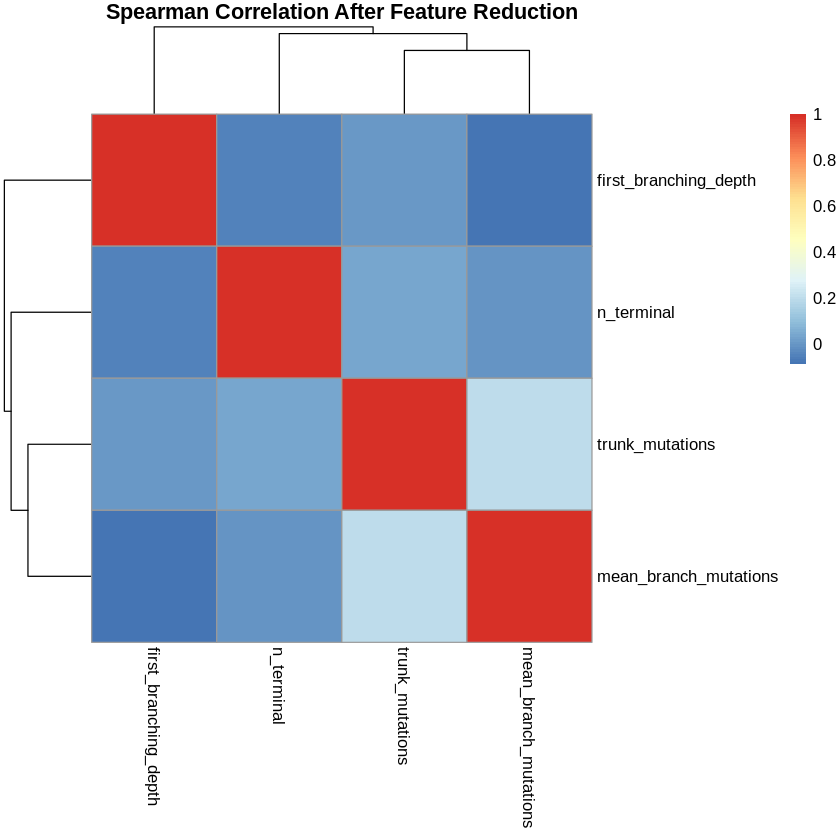


Optimal number of clusters: 3 

K-means cluster sizes:
kmeans_cluster
  1   2   3 
 20 315  63 

Hierarchical cluster sizes:
hc_cluster
  1   2   3 
306  63  29 

PAM cluster sizes:
pam_cluster
  1   2   3 
256  61  81 
               Comparison       ARI
1 K-means vs Hierarchical 0.9198042
2          K-means vs PAM 0.4562312
3     Hierarchical vs PAM 0.4344079


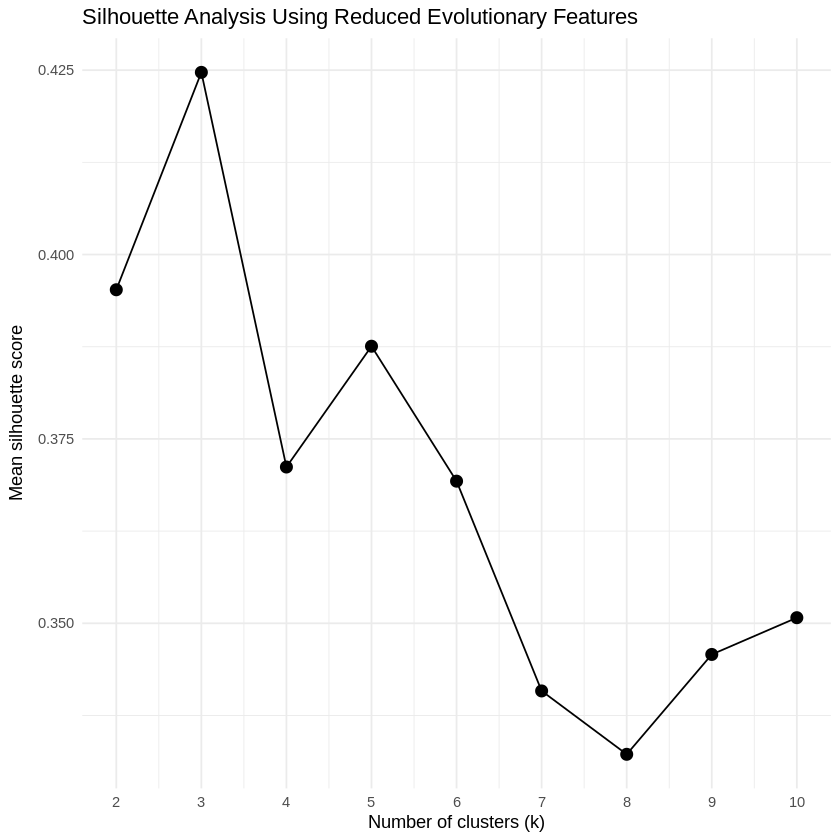

# A tibble: 3 × 9
  Cluster n_terminal_median n_terminal_mean trunk_mutations_median
  <fct>               <dbl>           <dbl>                  <dbl>
1 1                       3            3.25                  1782.
2 2                       3            3.58                   354 
3 3                       3            3.49                   369 
# ℹ 5 more variables: trunk_mutations_mean <dbl>,
#   mean_branch_mutations_median <dbl>, mean_branch_mutations_mean <dbl>,
#   first_branching_depth_median <dbl>, first_branching_depth_mean <dbl>
# A tibble: 3 × 5
  Cluster n_terminal trunk_mutations mean_branch_mutations first_branching_depth
  <fct>        <dbl>           <dbl>                 <dbl>                 <dbl>
1 1          -0.159            2.84                  2.37                -0.0951
2 2           0.0164          -0.154                -0.109               -0.406 
3 3          -0.0318          -0.132                -0.205                2.06  


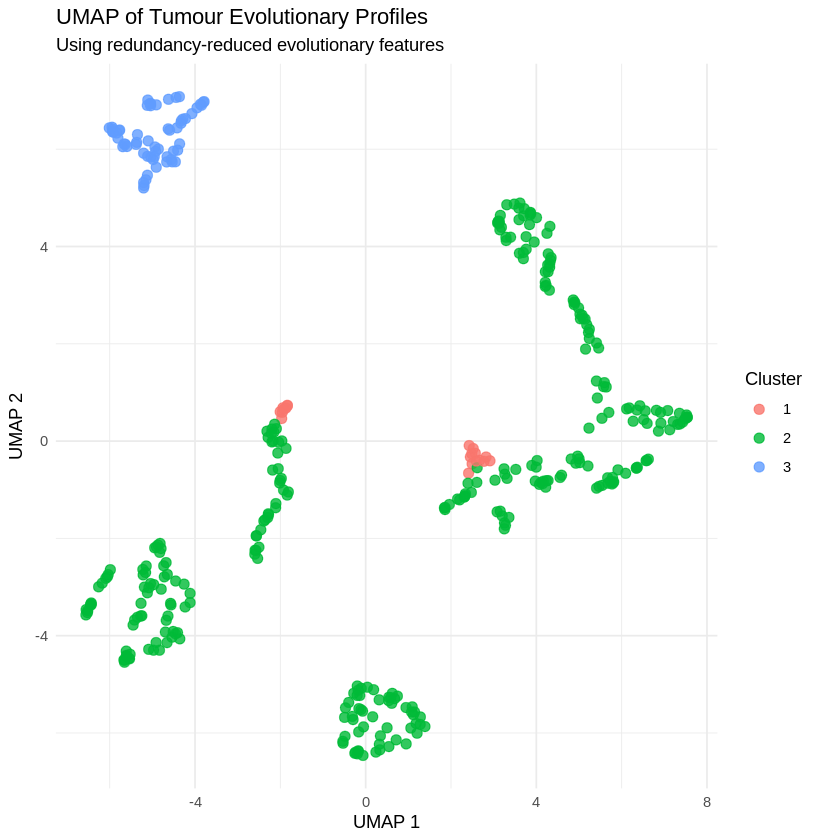

                Feature Chi_square      P_value FDR_adjusted_p
1 first_branching_depth 380.796283 2.047094e-83   8.188376e-83
2       trunk_mutations  40.414438 1.675391e-09   3.350783e-09
3 mean_branch_mutations  33.651532 4.927908e-08   6.570545e-08
4            n_terminal   1.230505 5.405043e-01   5.405043e-01


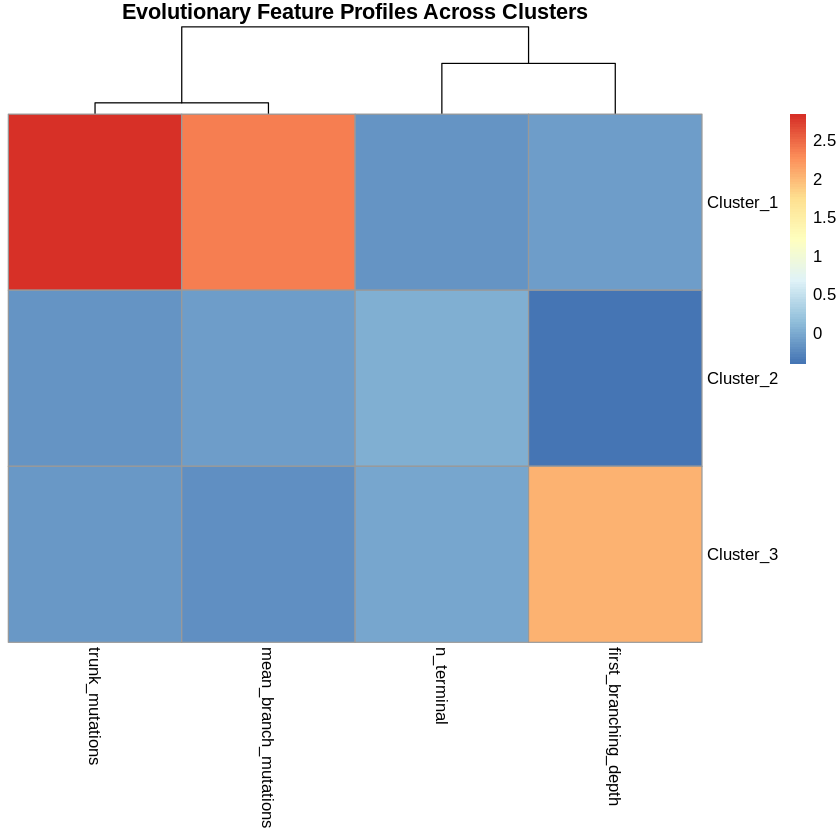


ARI: Original features vs reduced features = 0.047786 

REDUCED-FEATURE ANALYSIS COMPLETE
Patients: 398 
Original features: 25 
Retained features: 4 
Optimal k: 3 
K-means vs Hierarchical ARI: 0.92 
K-means vs PAM ARI: 0.456 
Original vs Reduced ARI: 0.048 
Significant cluster-associated features: 3 


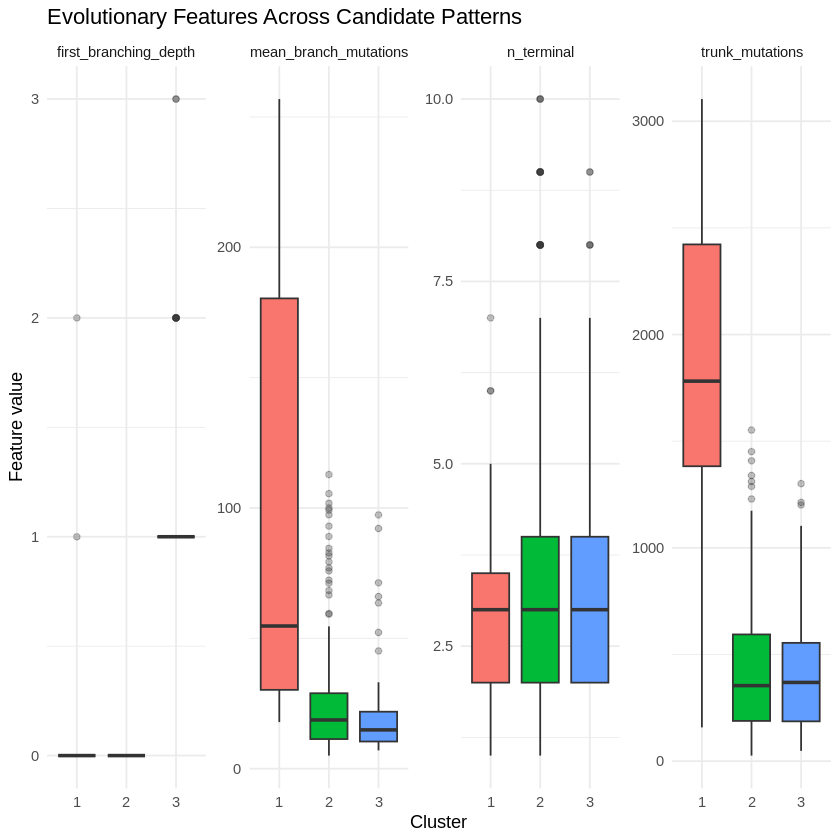

In [ ]:
# ============================================================
# REDUCED-FEATURE CLUSTERING ANALYSIS
# Starting object:
# patient_level_feature_matrix
# columns:
# patient_id + numeric evolutionary features
# ============================================================


# ============================================================
# 0. INSTALL AND LOAD PACKAGES
# ============================================================

packages <- c(
  "dplyr",
  "tidyr",
  "ggplot2",
  "cluster",
  "factoextra",
  "umap",
  "mclust",
  "pheatmap"
)

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(dplyr)
library(tidyr)
library(ggplot2)
library(cluster)
library(factoextra)
library(umap)
library(mclust)
library(pheatmap)

set.seed(42)


# ============================================================
# 1. PREPARE NUMERIC FEATURE MATRIX
# ============================================================

patient_ids <- patient_level_feature_matrix$patient_id

X <- patient_level_feature_matrix %>%
  select(-patient_id) %>%
  select(where(is.numeric))


# Convert Inf / -Inf to NA
X[] <- lapply(
  X,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)


cat("Patients:", nrow(X), "\n")
cat("Original features:", ncol(X), "\n")


# ============================================================
# 2. REMOVE ZERO-VARIANCE FEATURES
# ============================================================

keep_variance <- sapply(
  X,
  function(x) {
    v <- var(x, na.rm = TRUE)
    !is.na(v) && v > 0
  }
)

cat("\nRemoved zero-variance features:\n")
print(names(X)[!keep_variance])

X <- X[, keep_variance, drop = FALSE]


# ============================================================
# 3. HANDLE MISSING VALUES
# Median imputation
# ============================================================

for (j in seq_along(X)) {

  if (any(is.na(X[[j]]))) {

    med <- median(
      X[[j]],
      na.rm = TRUE
    )

    X[[j]][is.na(X[[j]])] <- med
  }
}

cat(
  "\nRemaining missing values:",
  sum(is.na(X)),
  "\n"
)


# ============================================================
# 4. CALCULATE SPEARMAN CORRELATION
# ============================================================

cor_matrix <- cor(
  X,
  method = "spearman",
  use = "pairwise.complete.obs"
)


# ============================================================
# 5. REMOVE HIGHLY CORRELATED FEATURES
# Threshold = |rho| > 0.70
#
# Strategy:
# iteratively remove the feature with the highest
# average absolute correlation among offending pairs
# ============================================================

remove_high_cor <- function(data, cutoff = 0.70) {

  current_data <- data
  removed <- character(0)

  repeat {

    cm <- cor(
      current_data,
      method = "spearman",
      use = "pairwise.complete.obs"
    )

    diag(cm) <- 0

    high_pairs <- which(
      abs(cm) > cutoff,
      arr.ind = TRUE
    )

    if (nrow(high_pairs) == 0) {
      break
    }

    mean_abs_cor <- apply(
      abs(cm),
      1,
      mean,
      na.rm = TRUE
    )

    feature_to_remove <- names(
      which.max(mean_abs_cor)
    )

    removed <- c(
      removed,
      feature_to_remove
    )

    current_data <- current_data %>%
      select(
        -all_of(feature_to_remove)
      )
  }

  list(
    reduced_data = current_data,
    removed_features = removed
  )
}


cor_reduction <- remove_high_cor(
  X,
  cutoff = 0.70
)

X_reduced <- cor_reduction$reduced_data

removed_features <- cor_reduction$removed_features


cat("\n========================================\n")
cat("CORRELATION-BASED FEATURE REDUCTION\n")
cat("========================================\n")

cat(
  "Original features:",
  ncol(X),
  "\n"
)

cat(
  "Reduced features:",
  ncol(X_reduced),
  "\n"
)

cat("\nRemoved features:\n")
print(removed_features)

cat("\nRetained features:\n")
print(colnames(X_reduced))


# ============================================================
# 6. SAVE RETAINED / REMOVED FEATURE LIST
# ============================================================

write.csv(
  data.frame(
    Removed_feature = removed_features
  ),
  "Removed_Highly_Correlated_Features.csv",
  row.names = FALSE
)

write.csv(
  data.frame(
    Retained_feature = colnames(X_reduced)
  ),
  "Retained_Evolutionary_Features.csv",
  row.names = FALSE
)


# ============================================================
# 7. CORRELATION HEATMAP AFTER REDUCTION
# ============================================================

reduced_cor <- cor(
  X_reduced,
  method = "spearman"
)

pheatmap(
  reduced_cor,
  main =
    "Spearman Correlation After Feature Reduction"
)


# save correlation matrix
write.csv(
  round(reduced_cor, 4),
  "Reduced_Feature_Spearman_Correlation.csv",
  row.names = TRUE
)


# ============================================================
# 8. SCALE REDUCED FEATURES
# ============================================================

X_scaled <- scale(
  X_reduced
)

X_scaled <- as.data.frame(
  X_scaled
)

rownames(X_scaled) <- patient_ids


# ============================================================
# 9. SILHOUETTE ANALYSIS
# k = 2 to 10
# ============================================================

silhouette_scores <- data.frame(
  k = 2:10,
  silhouette = NA_real_
)

for (k in 2:10) {

  km <- kmeans(
    X_scaled,
    centers = k,
    nstart = 100
  )

  sil <- silhouette(
    km$cluster,
    dist(X_scaled)
  )

  silhouette_scores$silhouette[
    silhouette_scores$k == k
  ] <- mean(
    sil[, 3]
  )
}


print(silhouette_scores)


# ============================================================
# 10. SILHOUETTE PLOT
# ============================================================

silhouette_plot <- ggplot(
  silhouette_scores,
  aes(
    x = k,
    y = silhouette
  )
) +
  geom_line() +
  geom_point(size = 3) +
  scale_x_continuous(
    breaks = 2:10
  ) +
  labs(
    title =
      "Silhouette Analysis Using Reduced Evolutionary Features",
    x =
      "Number of clusters (k)",
    y =
      "Mean silhouette score"
  ) +
  theme_minimal()


print(
  silhouette_plot
)


ggsave(
  "Reduced_Feature_Silhouette_Analysis.pdf",
  silhouette_plot,
  width = 7,
  height = 5
)


# ============================================================
# 11. SELECT OPTIMAL k
# ============================================================

best_k <- silhouette_scores$k[
  which.max(
    silhouette_scores$silhouette
  )
]

cat(
  "\nOptimal number of clusters:",
  best_k,
  "\n"
)


# ============================================================
# 12. FINAL K-MEANS
# ============================================================

set.seed(42)

kmeans_final <- kmeans(
  X_scaled,
  centers = best_k,
  nstart = 200
)

kmeans_cluster <- kmeans_final$cluster


cat("\nK-means cluster sizes:\n")
print(
  table(kmeans_cluster)
)


# ============================================================
# 13. HIERARCHICAL CLUSTERING
# Ward.D2
# ============================================================

distance_matrix <- dist(
  X_scaled
)

hc <- hclust(
  distance_matrix,
  method = "ward.D2"
)

hc_cluster <- cutree(
  hc,
  k = best_k
)


cat("\nHierarchical cluster sizes:\n")
print(
  table(hc_cluster)
)


# ============================================================
# 14. PAM CLUSTERING
# ============================================================

pam_model <- pam(
  X_scaled,
  k = best_k
)

pam_cluster <- pam_model$clustering


cat("\nPAM cluster sizes:\n")
print(
  table(pam_cluster)
)


# ============================================================
# 15. ARI BETWEEN CLUSTERING METHODS
# ============================================================

ari_kmeans_hc <- adjustedRandIndex(
  kmeans_cluster,
  hc_cluster
)

ari_kmeans_pam <- adjustedRandIndex(
  kmeans_cluster,
  pam_cluster
)

ari_hc_pam <- adjustedRandIndex(
  hc_cluster,
  pam_cluster
)


ARI_table <- data.frame(
  Comparison = c(
    "K-means vs Hierarchical",
    "K-means vs PAM",
    "Hierarchical vs PAM"
  ),
  ARI = c(
    ari_kmeans_hc,
    ari_kmeans_pam,
    ari_hc_pam
  )
)


print(
  ARI_table
)


write.csv(
  ARI_table,
  "Reduced_Feature_Clustering_ARI.csv",
  row.names = FALSE
)


# ============================================================
# 16. UMAP
# ============================================================

set.seed(42)

umap_result <- umap(
  X_scaled
)

umap_df <- data.frame(
  patient_id = patient_ids,
  UMAP1 = umap_result$layout[, 1],
  UMAP2 = umap_result$layout[, 2],
  Cluster =
    factor(kmeans_cluster)
)


umap_plot <- ggplot(
  umap_df,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = Cluster
  )
) +
  geom_point(
    size = 2.5,
    alpha = 0.8
  ) +
  labs(
    title =
      "UMAP of Tumour Evolutionary Profiles",
    subtitle =
      "Using redundancy-reduced evolutionary features",
    x = "UMAP 1",
    y = "UMAP 2"
  ) +
  theme_minimal()


print(
  umap_plot
)


ggsave(
  "Reduced_Feature_UMAP.pdf",
  umap_plot,
  width = 7,
  height = 6
)


# ============================================================
# 17. CREATE FINAL PATIENT CLUSTER TABLE
# ============================================================

cluster_results <- data.frame(
  patient_id = patient_ids,
  Kmeans_cluster =
    kmeans_cluster,
  Hierarchical_cluster =
    hc_cluster,
  PAM_cluster =
    pam_cluster
)


write.csv(
  cluster_results,
  "Reduced_Feature_Patient_Clusters.csv",
  row.names = FALSE
)


# ============================================================
# 18. CLUSTER-WISE FEATURE CHARACTERIZATION
# ============================================================

feature_cluster_df <- X_reduced %>%
  mutate(
    patient_id = patient_ids,
    Cluster =
      factor(kmeans_cluster)
  )


cluster_summary <- feature_cluster_df %>%
  group_by(
    Cluster
  ) %>%
  summarise(
    across(
      where(is.numeric),
      list(
        median =
          ~ median(.x, na.rm = TRUE),
        mean =
          ~ mean(.x, na.rm = TRUE)
      )
    ),
    .groups = "drop"
  )


print(
  cluster_summary
)


write.csv(
  cluster_summary,
  "Reduced_Feature_Cluster_Profiles.csv",
  row.names = FALSE
)


# ============================================================
# 19. STANDARDIZED CLUSTER CENTROIDS
# ============================================================

scaled_cluster_df <- X_scaled %>%
  mutate(
    Cluster =
      factor(kmeans_cluster)
  )


cluster_centroids <- scaled_cluster_df %>%
  group_by(
    Cluster
  ) %>%
  summarise(
    across(
      everything(),
      mean
    ),
    .groups = "drop"
  )


print(
  cluster_centroids
)


write.csv(
  cluster_centroids,
  "Standardized_Cluster_Centroids.csv",
  row.names = FALSE
)


# ============================================================
# 20. HEATMAP OF CLUSTER CENTROIDS
# ============================================================

centroid_matrix <- as.matrix(
  cluster_centroids[, -1]
)

rownames(
  centroid_matrix
) <- paste0(
  "Cluster_",
  cluster_centroids$Cluster
)


pheatmap(
  centroid_matrix,
  cluster_rows = FALSE,
  main =
    "Evolutionary Feature Profiles Across Clusters"
)


# ============================================================
# 21. KRUSKAL-WALLIS TEST
# ============================================================

kw_results <- lapply(
  colnames(X_reduced),
  function(feature) {

    test_data <- data.frame(
      value =
        X_reduced[[feature]],
      cluster =
        factor(kmeans_cluster)
    )

    kw <- kruskal.test(
      value ~ cluster,
      data = test_data
    )

    data.frame(
      Feature = feature,
      Chi_square =
        unname(kw$statistic),
      P_value =
        kw$p.value
    )
  }
)


kw_results <- bind_rows(
  kw_results
)


kw_results$FDR_adjusted_p <- p.adjust(
  kw_results$P_value,
  method = "BH"
)


kw_results <- kw_results %>%
  arrange(
    FDR_adjusted_p
  )


print(
  kw_results
)


write.csv(
  kw_results,
  "Cluster_Feature_Kruskal_Wallis.csv",
  row.names = FALSE
)


# ============================================================
# 22. LONG FORMAT FOR BOXPLOTS
# ============================================================

plot_df <- X_reduced %>%
  mutate(
    patient_id = patient_ids,
    Cluster =
      factor(kmeans_cluster)
  ) %>%
  pivot_longer(
    cols =
      -c(patient_id, Cluster),
    names_to =
      "Feature",
    values_to =
      "Value"
  )


boxplot_figure <- ggplot(
  plot_df,
  aes(
    x = Cluster,
    y = Value,
    fill = Cluster
  )
) +
  geom_boxplot(
    outlier.alpha = 0.3
  ) +
  facet_wrap(
    ~ Feature,
    scales = "free_y",
    ncol = 4
  ) +
  labs(
    title =
      "Evolutionary Features Across Candidate Patterns",
    x =
      "Cluster",
    y =
      "Feature value"
  ) +
  theme_minimal() +
  theme(
    legend.position =
      "none"
  )


print(
  boxplot_figure
)


ggsave(
  "Reduced_Feature_Cluster_Boxplots.pdf",
  boxplot_figure,
  width = 12,
  height = 10
)


# ============================================================
# 23. OPTIONAL:
# COMPARE ORIGINAL 25-FEATURE CLUSTERING
# WITH REDUCED-FEATURE CLUSTERING
#
# This section assumes original K-means clustering
# will be recalculated using all original features.
# ============================================================

X_original <- X

X_original_scaled <- scale(
  X_original
)


set.seed(42)

original_kmeans <- kmeans(
  X_original_scaled,
  centers = best_k,
  nstart = 200
)


original_cluster <- original_kmeans$cluster


ari_original_vs_reduced <- adjustedRandIndex(
  original_cluster,
  kmeans_cluster
)


cat(
  "\nARI: Original features vs reduced features =",
  ari_original_vs_reduced,
  "\n"
)


write.csv(
  data.frame(
    Comparison =
      "Original 25-feature vs Reduced-feature K-means",
    ARI =
      ari_original_vs_reduced
  ),
  "Original_vs_Reduced_ARI.csv",
  row.names = FALSE
)


# ============================================================
# 24. SAVE FINAL REDUCED FEATURE MATRIX
# ============================================================

final_reduced_matrix <- X_reduced %>%
  mutate(
    patient_id =
      patient_ids,
    .before = 1
  )


write.csv(
  final_reduced_matrix,
  "TRACERx421_Reduced_Evolutionary_Feature_Matrix.csv",
  row.names = FALSE
)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

cat("\n========================================\n")
cat("REDUCED-FEATURE ANALYSIS COMPLETE\n")
cat("========================================\n")

cat(
  "Patients:",
  nrow(X_reduced),
  "\n"
)

cat(
  "Original features:",
  ncol(X),
  "\n"
)

cat(
  "Retained features:",
  ncol(X_reduced),
  "\n"
)

cat(
  "Optimal k:",
  best_k,
  "\n"
)

cat(
  "K-means vs Hierarchical ARI:",
  round(ari_kmeans_hc, 3),
  "\n"
)

cat(
  "K-means vs PAM ARI:",
  round(ari_kmeans_pam, 3),
  "\n"
)

cat(
  "Original vs Reduced ARI:",
  round(ari_original_vs_reduced, 3),
  "\n"
)

cat(
  "Significant cluster-associated features:",
  sum(
    kw_results$FDR_adjusted_p < 0.05
  ),
  "\n"
)

Patients: 398 
Selected features: 7 

Selected feature names:
[1] "n_terminal"              "n_branching_nodes"      
[3] "max_depth"               "total_mutations"        
[5] "trunk_mutation_fraction" "mean_branch_mutations"  
[7] "first_branching_depth"  

Missing values before handling: 21 
                        n_terminal n_branching_nodes max_depth total_mutations
n_terminal                   1.000             0.900     0.579           0.221
n_branching_nodes            0.900             1.000     0.644           0.256
max_depth                    0.579             0.644     1.000           0.412
total_mutations              0.221             0.256     0.412           1.000
trunk_mutation_fraction     -0.394            -0.437    -0.565           0.052
mean_branch_mutations       -0.005             0.107     0.350           0.546
first_branching_depth       -0.046            -0.096     0.100          -0.040
                        trunk_mutation_fraction mean_branch_mutations
n

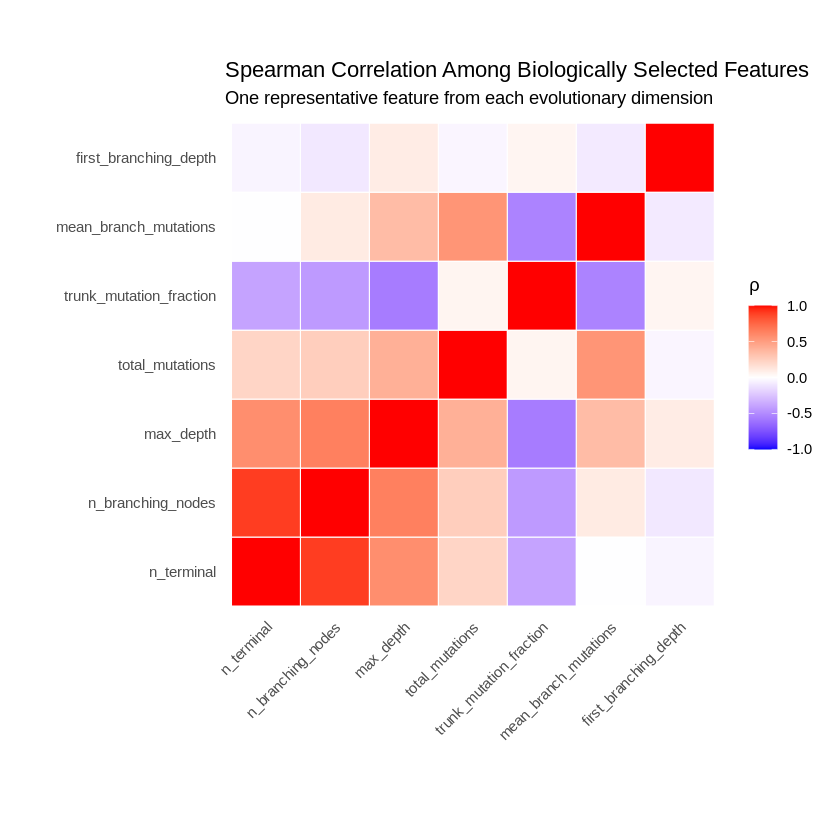

In [ ]:
# ============================================================
# BIOLOGICALLY GUIDED FEATURE REDUCTION
# One representative feature per evolutionary dimension
# ============================================================

library(dplyr)
library(ggplot2)
library(tidyr)

# ============================================================
# 1. DEFINE BIOLOGICAL / EVOLUTIONARY DIMENSIONS
# ============================================================

feature_groups <- list(

  # ----------------------------------------
  # 1. TREE SIZE
  # ----------------------------------------
  tree_size = c(
    "n_nodes",
    "n_edges",
    "n_internal",
    "n_terminal"
  ),

  # ----------------------------------------
  # 2. BRANCHING COMPLEXITY
  # ----------------------------------------
  branching_complexity = c(
    "n_branching_nodes",
    "max_outdegree",
    "mean_outdegree"
  ),

  # ----------------------------------------
  # 3. EVOLUTIONARY DEPTH
  # ----------------------------------------
  evolutionary_depth = c(
    "max_depth",
    "mean_depth",
    "mean_terminal_depth",
    "max_terminal_depth"
  ),

  # ----------------------------------------
  # 4. MUTATION BURDEN
  # ----------------------------------------
  mutation_burden = c(
    "trunk_mutations",
    "branch_mutations",
    "total_mutations",
    "mean_mutations_per_clone",
    "max_mutations_per_clone"
  ),

  # ----------------------------------------
  # 5. TRUNK-vs-BRANCH MUTATION ALLOCATION
  # ----------------------------------------
  trunk_branch_allocation = c(
    "trunk_mutation_fraction",
    "branch_mutation_fraction",
    "trunk_branch_ratio"
  ),

  # ----------------------------------------
  # 6. BRANCH MUTATION HETEROGENEITY
  # ----------------------------------------
  branch_heterogeneity = c(
    "mean_branch_mutations",
    "sd_branch_mutations",
    "branch_mutation_variance"
  ),

  # ----------------------------------------
  # 7. DIVERSIFICATION TIMING
  # ----------------------------------------
  diversification_timing = c(
    "first_branching_depth",
    "mean_branching_depth",
    "diversification_timing"
  )
)


# ============================================================
# 2. MANUALLY CHOOSE ONE REPRESENTATIVE FEATURE
# FROM EACH DIMENSION
# ============================================================

selected_features <- c(

  # Tree size
  "n_terminal",

  # Branching complexity
  "n_branching_nodes",

  # Evolutionary depth
  "max_depth",

  # Mutation burden
  "total_mutations",

  # Trunk vs branch mutation allocation
  "trunk_mutation_fraction",

  # Branch mutation heterogeneity
  "mean_branch_mutations",

  # Diversification timing
  "first_branching_depth"
)


# ============================================================
# 3. CHECK THAT ALL SELECTED FEATURES EXIST
# ============================================================

missing_features <- setdiff(
  selected_features,
  colnames(patient_level_feature_matrix)
)

if (length(missing_features) > 0) {

  stop(
    paste(
      "These features are missing:",
      paste(missing_features, collapse = ", ")
    )
  )
}


# ============================================================
# 4. CREATE BIOLOGICALLY REDUCED FEATURE MATRIX
# ============================================================

biological_reduced_matrix <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(selected_features)
  )


cat(
  "Patients:",
  nrow(biological_reduced_matrix),
  "\n"
)

cat(
  "Selected features:",
  length(selected_features),
  "\n"
)

cat(
  "\nSelected feature names:\n"
)

print(
  selected_features
)


# ============================================================
# 5. CHECK MISSING / NON-FINITE VALUES
# ============================================================

numeric_features <- biological_reduced_matrix %>%
  select(-patient_id)


numeric_features[] <- lapply(
  numeric_features,
  function(x) {

    x[is.infinite(x)] <- NA

    x
  }
)


cat(
  "\nMissing values before handling:",
  sum(is.na(numeric_features)),
  "\n"
)


# Median imputation if necessary

numeric_features[] <- lapply(
  numeric_features,
  function(x) {

    if (any(is.na(x))) {

      x[is.na(x)] <- median(
        x,
        na.rm = TRUE
      )
    }

    x
  }
)


# Rebuild matrix

biological_reduced_matrix <- data.frame(

  patient_id =
    patient_level_feature_matrix$patient_id,

  numeric_features
)


# ============================================================
# 6. SPEARMAN CORRELATION AMONG SELECTED FEATURES
# ============================================================

biological_cor <- cor(

  numeric_features,

  method = "spearman",

  use = "pairwise.complete.obs"
)


print(
  round(
    biological_cor,
    3
  )
)


# ============================================================
# 7. FIND REMAINING HIGH CORRELATIONS
# ============================================================

upper_idx <- upper.tri(
  biological_cor,
  diag = FALSE
)


remaining_correlations <- data.frame(

  Feature_1 =
    rownames(biological_cor)[
      row(biological_cor)[upper_idx]
    ],

  Feature_2 =
    colnames(biological_cor)[
      col(biological_cor)[upper_idx]
    ],

  Spearman_rho =
    biological_cor[upper_idx]

) %>%

  mutate(
    Absolute_rho =
      abs(Spearman_rho)
  ) %>%

  arrange(
    desc(Absolute_rho)
  )


cat(
  "\nPairwise correlations among selected features:\n"
)

print(
  remaining_correlations
)


cat(
  "\nRemaining pairs with |rho| > 0.70:\n"
)

print(
  remaining_correlations %>%
    filter(
      Absolute_rho > 0.70
    )
)


# ============================================================
# 8. CREATE HEATMAP
# ============================================================

heatmap_df <- as.data.frame(
  as.table(
    biological_cor
  )
)


colnames(
  heatmap_df
) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)


biological_heatmap <- ggplot(

  heatmap_df,

  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )

) +

  geom_tile(
    color = "white",
    linewidth = 0.3
  ) +

  scale_fill_gradient2(

    low = "blue",

    mid = "white",

    high = "red",

    midpoint = 0,

    limits = c(-1, 1)

  ) +

  coord_fixed() +

  labs(

    title =
      "Spearman Correlation Among Biologically Selected Features",

    subtitle =
      "One representative feature from each evolutionary dimension",

    x = NULL,

    y = NULL,

    fill = expression(rho)

  ) +

  theme_minimal() +

  theme(

    panel.grid =
      element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1,
        size = 9
      ),

    axis.text.y =
      element_text(
        size = 9
      )
  )


print(
  biological_heatmap
)


# ============================================================
# 9. SAVE RESULTS
# ============================================================

write.csv(

  biological_reduced_matrix,

  "Biologically_Reduced_Feature_Matrix.csv",

  row.names = FALSE
)


write.csv(

  remaining_correlations,

  "Biologically_Selected_Feature_Correlations.csv",

  row.names = FALSE
)


ggsave(

  "Biologically_Selected_Feature_Correlation_Heatmap.pdf",

  biological_heatmap,

  width = 8,

  height = 7
)


ggsave(

  "Biologically_Selected_Feature_Correlation_Heatmap.png",

  biological_heatmap,

  width = 8,

  height = 7,

  dpi = 600
)


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "BIOLOGICALLY GUIDED FEATURE SELECTION COMPLETE\n"
)

cat(
  "========================================\n"
)

cat(
  "Original features: 25\n"
)

cat(
  "Selected features:",
  length(selected_features),
  "\n"
)

cat(
  "\nSelected features:\n"
)

print(
  selected_features
)

Missing values before imputation: 21 
Patients: 398 
Final features: 6 
[1] "n_terminal"              "max_depth"              
[3] "total_mutations"         "trunk_mutation_fraction"
[5] "mean_branch_mutations"   "first_branching_depth"  
                        n_terminal max_depth total_mutations
n_terminal                   1.000     0.579           0.221
max_depth                    0.579     1.000           0.412
total_mutations              0.221     0.412           1.000
trunk_mutation_fraction     -0.394    -0.565           0.052
mean_branch_mutations       -0.005     0.350           0.546
first_branching_depth       -0.046     0.100          -0.040
                        trunk_mutation_fraction mean_branch_mutations
n_terminal                               -0.394                -0.005
max_depth                                -0.565                 0.350
total_mutations                           0.052                 0.546
trunk_mutation_fraction                   1.000      

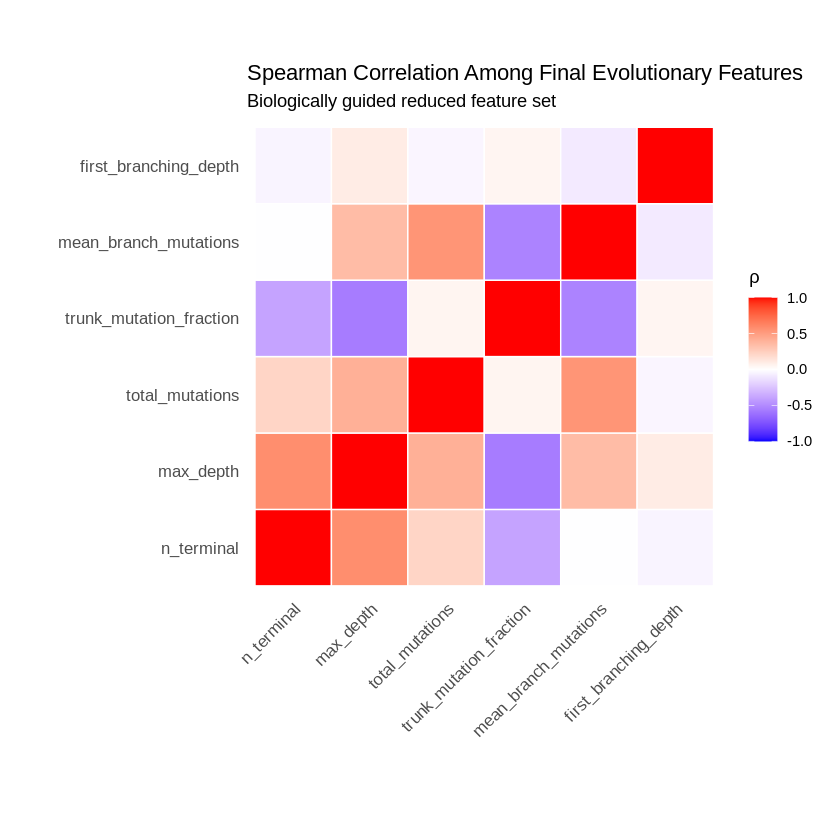

In [ ]:
# ============================================================
# FINAL BIOLOGICALLY REDUCED FEATURE MATRIX
# ============================================================

library(dplyr)
library(ggplot2)

final_selected_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

# ------------------------------------------------------------
# 1. Create final feature matrix
# ------------------------------------------------------------

final_reduced_matrix <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(final_selected_features)
  )

# ------------------------------------------------------------
# 2. Handle Inf / NA
# ------------------------------------------------------------

final_numeric <- final_reduced_matrix %>%
  select(-patient_id)

final_numeric[] <- lapply(
  final_numeric,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)

cat(
  "Missing values before imputation:",
  sum(is.na(final_numeric)),
  "\n"
)

final_numeric[] <- lapply(
  final_numeric,
  function(x) {
    if (any(is.na(x))) {
      x[is.na(x)] <- median(x, na.rm = TRUE)
    }
    x
  }
)

# ------------------------------------------------------------
# 3. Rebuild final matrix
# ------------------------------------------------------------

final_reduced_matrix <- data.frame(
  patient_id = patient_level_feature_matrix$patient_id,
  final_numeric
)

cat(
  "Patients:",
  nrow(final_reduced_matrix),
  "\n"
)

cat(
  "Final features:",
  ncol(final_numeric),
  "\n"
)

print(
  colnames(final_numeric)
)

# ------------------------------------------------------------
# 4. Spearman correlation
# ------------------------------------------------------------

final_cor <- cor(
  final_numeric,
  method = "spearman",
  use = "pairwise.complete.obs"
)

print(
  round(final_cor, 3)
)

# ------------------------------------------------------------
# 5. Extract pairwise correlations
# ------------------------------------------------------------

upper_idx <- upper.tri(
  final_cor,
  diag = FALSE
)

final_pairs <- data.frame(
  Feature_1 =
    rownames(final_cor)[row(final_cor)[upper_idx]],

  Feature_2 =
    colnames(final_cor)[col(final_cor)[upper_idx]],

  Spearman_rho =
    final_cor[upper_idx]
) %>%
  mutate(
    Absolute_rho = abs(Spearman_rho)
  ) %>%
  arrange(
    desc(Absolute_rho)
  )

cat(
  "\nPairwise correlations:\n"
)

print(
  final_pairs
)

cat(
  "\nRemaining pairs with |rho| > 0.70:\n"
)

print(
  final_pairs %>%
    filter(Absolute_rho > 0.70)
)

# ------------------------------------------------------------
# 6. Maximum remaining correlation
# ------------------------------------------------------------

temp_cor <- abs(final_cor)

diag(temp_cor) <- NA

max_cor <- max(
  temp_cor,
  na.rm = TRUE
)

cat(
  "\nMaximum remaining |rho|:",
  round(max_cor, 3),
  "\n"
)

# ------------------------------------------------------------
# 7. Heatmap
# ------------------------------------------------------------

heatmap_df <- as.data.frame(
  as.table(final_cor)
)

colnames(
  heatmap_df
) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)

final_heatmap <- ggplot(
  heatmap_df,
  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.4
  ) +
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0,
    limits = c(-1, 1)
  ) +
  coord_fixed() +
  labs(
    title =
      "Spearman Correlation Among Final Evolutionary Features",

    subtitle =
      "Biologically guided reduced feature set",

    x = NULL,
    y = NULL,
    fill = expression(rho)
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1,
        size = 10
      ),

    axis.text.y =
      element_text(
        size = 10
      )
  )

print(final_heatmap)

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------

write.csv(
  final_reduced_matrix,
  "Final_Biologically_Reduced_Feature_Matrix.csv",
  row.names = FALSE
)

write.csv(
  final_pairs,
  "Final_Feature_Correlation_Pairs.csv",
  row.names = FALSE
)

ggsave(
  "Final_Reduced_Feature_Spearman_Heatmap.pdf",
  final_heatmap,
  width = 8,
  height = 7
)

ggsave(
  "Final_Reduced_Feature_Spearman_Heatmap.png",
  final_heatmap,
  width = 8,
  height = 7,
  dpi = 600
)

cat(
  "\n========================================\n"
)

cat(
  "FINAL REDUCED MATRIX COMPLETE\n"
)

cat(
  "========================================\n"
)

cat(
  "Patients:",
  nrow(final_reduced_matrix),
  "\n"
)

cat(
  "Features:",
  ncol(final_numeric),
  "\n"
)

cat(
  "Maximum remaining |rho|:",
  round(max_cor, 3),
  "\n"
)

Patients: 398 
Selected features: 6 

Final selected features:
[1] "n_terminal"              "max_depth"              
[3] "total_mutations"         "trunk_mutation_fraction"
[5] "mean_branch_mutations"   "first_branching_depth"  

Missing values before imputation: 21 
Missing values after imputation: 0 

Final matrix dimension: 398 patients × 6 features

Final Spearman correlation matrix:
                        n_terminal max_depth total_mutations
n_terminal                   1.000     0.579           0.221
max_depth                    0.579     1.000           0.412
total_mutations              0.221     0.412           1.000
trunk_mutation_fraction     -0.394    -0.565           0.052
mean_branch_mutations       -0.005     0.350           0.546
first_branching_depth       -0.046     0.100          -0.040
                        trunk_mutation_fraction mean_branch_mutations
n_terminal                               -0.394                -0.005
max_depth                               

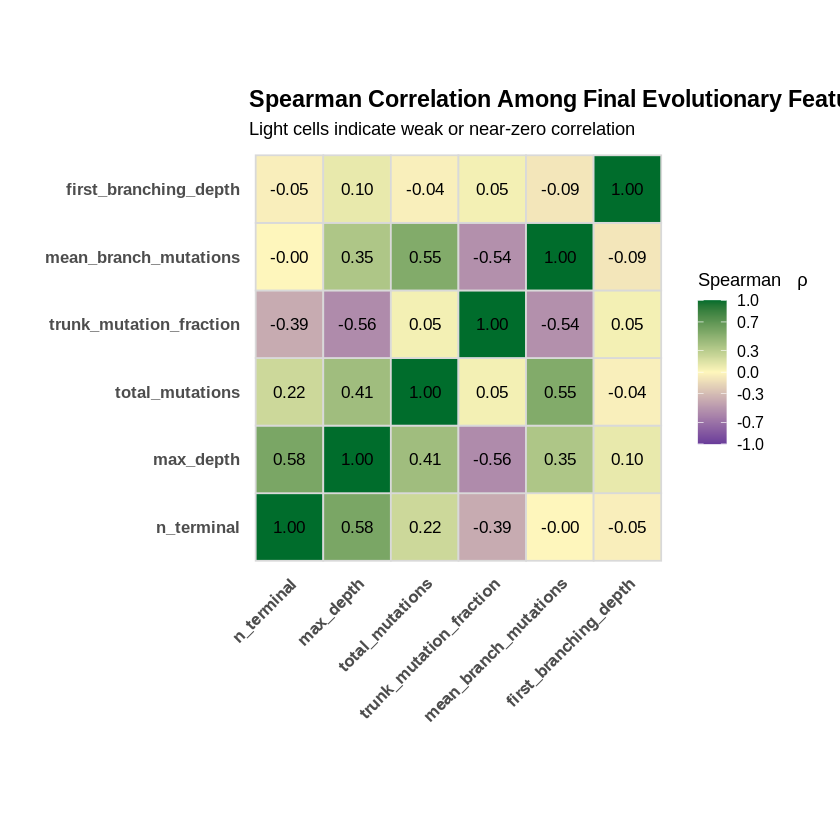

In [ ]:
# ============================================================
# FINAL BIOLOGICALLY REDUCED FEATURE MATRIX
# WITH CLEAR CORRELATION HEATMAP
# ============================================================

library(dplyr)
library(ggplot2)

# ============================================================
# 1. SELECT FINAL BIOLOGICALLY REPRESENTATIVE FEATURES
# ============================================================

final_selected_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

# ============================================================
# 2. CREATE FINAL REDUCED FEATURE MATRIX
# ============================================================

final_reduced_matrix <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(final_selected_features)
  )

cat("Patients:", nrow(final_reduced_matrix), "\n")
cat("Selected features:", length(final_selected_features), "\n\n")

cat("Final selected features:\n")
print(final_selected_features)


# ============================================================
# 3. HANDLE Inf / -Inf / NA
# ============================================================

final_numeric <- final_reduced_matrix %>%
  select(-patient_id)

# Convert Inf and -Inf to NA
final_numeric[] <- lapply(
  final_numeric,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)

cat(
  "\nMissing values before imputation:",
  sum(is.na(final_numeric)),
  "\n"
)

# Median imputation
final_numeric[] <- lapply(
  final_numeric,
  function(x) {

    if (any(is.na(x))) {

      x[is.na(x)] <- median(
        x,
        na.rm = TRUE
      )
    }

    x
  }
)

cat(
  "Missing values after imputation:",
  sum(is.na(final_numeric)),
  "\n"
)


# ============================================================
# 4. REBUILD FINAL PATIENT-LEVEL MATRIX
# ============================================================

final_reduced_matrix <- data.frame(
  patient_id = patient_level_feature_matrix$patient_id,
  final_numeric
)

cat(
  "\nFinal matrix dimension:",
  nrow(final_reduced_matrix),
  "patients ×",
  ncol(final_numeric),
  "features\n"
)


# ============================================================
# 5. COMPUTE SPEARMAN CORRELATION
# ============================================================

final_cor <- cor(
  final_numeric,
  method = "spearman",
  use = "pairwise.complete.obs"
)

cat("\nFinal Spearman correlation matrix:\n")

print(
  round(final_cor, 3)
)


# ============================================================
# 6. EXTRACT UNIQUE PAIRWISE CORRELATIONS
# ============================================================

upper_idx <- upper.tri(
  final_cor,
  diag = FALSE
)

final_pairs <- data.frame(

  Feature_1 =
    rownames(final_cor)[row(final_cor)[upper_idx]],

  Feature_2 =
    colnames(final_cor)[col(final_cor)[upper_idx]],

  Spearman_rho =
    final_cor[upper_idx]

) %>%

  mutate(
    Absolute_rho = abs(Spearman_rho)
  ) %>%

  arrange(
    desc(Absolute_rho)
  )


cat(
  "\nPairwise Spearman correlations:\n"
)

print(final_pairs)


# ============================================================
# 7. CHECK STRONG CORRELATIONS
# Threshold: |rho| > 0.70
# ============================================================

strong_pairs <- final_pairs %>%
  filter(
    Absolute_rho > 0.70
  )

cat(
  "\nPairs with |rho| > 0.70:\n"
)

if (nrow(strong_pairs) == 0) {

  cat(
    "None. No strong correlation remains.\n"
  )

} else {

  print(strong_pairs)

}


# ============================================================
# 8. MAXIMUM REMAINING CORRELATION
# ============================================================

temp_cor <- abs(final_cor)

diag(temp_cor) <- NA

max_cor <- max(
  temp_cor,
  na.rm = TRUE
)

cat(
  "\nMaximum remaining |rho|:",
  round(max_cor, 3),
  "\n"
)


# ============================================================
# 9. PREPARE DATA FOR HEATMAP
# ============================================================

heatmap_df <- as.data.frame(
  as.table(final_cor)
)

colnames(
  heatmap_df
) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)


# ============================================================
# 10. CREATE CLEAR CORRELATION HEATMAP
# ============================================================

final_heatmap <- ggplot(
  heatmap_df,
  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )
) +

  geom_tile(
    color = "grey85",
    linewidth = 0.5
  ) +

  # Add correlation value inside each cell
  geom_text(
    aes(
      label = sprintf("%.2f", Spearman_rho)
    ),
    size = 3.6
  ) +

  # Purple = negative
  # Light yellow = near zero / weak correlation
  # Dark green = positive
  scale_fill_gradient2(
    low = "#6A3D9A",
    mid = "#FFF7BC",
    high = "#006D2C",
    midpoint = 0,
    limits = c(-1, 1),
    breaks = c(-1, -0.7, -0.3, 0, 0.3, 0.7, 1)
  ) +

  coord_fixed() +

  labs(
    title =
      "Spearman Correlation Among Final Evolutionary Features",

    subtitle =
      "Light cells indicate weak or near-zero correlation",

    x = NULL,
    y = NULL,

    fill =
      expression("Spearman " ~ rho)
  ) +

  theme_minimal(base_size = 12) +

  theme(

    panel.grid =
      element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1,
        size = 10,
        face = "bold"
      ),

    axis.text.y =
      element_text(
        size = 10,
        face = "bold"
      ),

    plot.title =
      element_text(
        face = "bold",
        size = 14
      ),

    plot.subtitle =
      element_text(
        size = 11
      ),

    legend.title =
      element_text(
        size = 11
      )
  )


print(final_heatmap)


# ============================================================
# 11. SAVE FINAL MATRIX
# ============================================================

write.csv(
  final_reduced_matrix,
  "Final_Biologically_Reduced_Feature_Matrix.csv",
  row.names = FALSE
)


# ============================================================
# 12. SAVE PAIRWISE CORRELATIONS
# ============================================================

write.csv(
  final_pairs,
  "Final_Feature_Correlation_Pairs.csv",
  row.names = FALSE
)


# ============================================================
# 13. SAVE HEATMAP
# ============================================================

ggsave(
  filename =
    "Final_Reduced_Feature_Spearman_Heatmap.pdf",

  plot =
    final_heatmap,

  width = 9,
  height = 7
)


ggsave(
  filename =
    "Final_Reduced_Feature_Spearman_Heatmap.png",

  plot =
    final_heatmap,

  width = 9,
  height = 7,

  dpi = 600
)


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "FINAL BIOLOGICALLY REDUCED MATRIX COMPLETE\n"
)

cat(
  "========================================\n"
)

cat(
  "Patients:",
  nrow(final_reduced_matrix),
  "\n"
)

cat(
  "Final features:",
  ncol(final_numeric),
  "\n"
)

cat(
  "Strong correlation pairs (|rho| > 0.70):",
  nrow(strong_pairs),
  "\n"
)

cat(
  "Maximum remaining |rho|:",
  round(max_cor, 3),
  "\n"
)

cat(
  "========================================\n"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘BH’, ‘sitmo’, ‘FNN’, ‘RcppAnnoy’, ‘dqrng’, ‘RcppProgress’


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘uwot’


The following object is masked from ‘package:umap’:

    umap




Patients: 398 
Features: 6 
Missing values before imputation: 21 
Missing values after imputation: 0 

Scaled matrix dimension: 398 6 
   k silhouette
1  2  0.2408694
2  3  0.2550279
3  4  0.2442572
4  5  0.2169240
5  6  0.2157078
6  7  0.2049415
7  8  0.2025418
8  9  0.2093932
9 10  0.2148175

K-means cluster sizes:
kmeans_cluster
  1   2   3   4 
146 116  84  52 

Hierarchical cluster sizes:
hc_cluster
  1   2   3   4 
 54 171 109  64 

PAM cluster sizes:
pam_cluster
  1   2   3   4 
 91 158  93  56 

CLUSTER AGREEMENT (ARI)
               Comparison       ARI
1 K-means vs Hierarchical 0.3497529
2          K-means vs PAM 0.3832335
3     Hierarchical vs PAM 0.4862997

Mean silhouette for k = 4: 0.2443 


17:16:38 UMAP embedding parameters a = 1.577 b = 0.8951

17:16:38 Converting dataframe to numerical matrix

17:16:38 Read 398 rows and found 6 numeric columns

17:16:38 Using FNN for neighbor search, n_neighbors = 15

17:16:38 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 15

17:16:39 Initializing from normalized Laplacian + noise (using RSpectra)

17:16:39 Commencing optimization for 500 epochs, with 7420 positive edges

17:16:39 Using rng type: pcg

17:16:40 Optimization finished



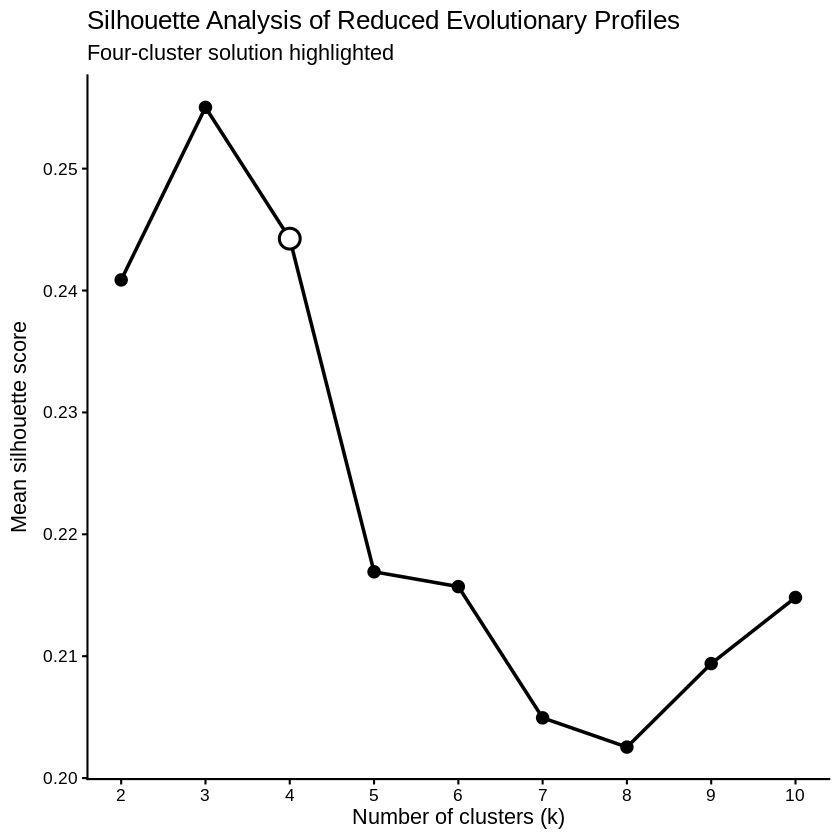

,patient_id,kmeans_cluster,hierarchical_cluster,pam_cluster,UMAP1,UMAP2
,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>
CRUK0005,CRUK0005,3,1,1,-1.991165,1.6472853
CRUK0057,CRUK0057,1,2,2,1.491734,-1.3635562
CRUK0039,CRUK0039,1,2,3,1.539933,-1.6592704
CRUK0196,CRUK0196,1,3,3,2.806025,-0.5923531
CRUK0023,CRUK0023,1,2,2,2.549427,1.4918407
CRUK0050,CRUK0050,4,4,3,-7.242586,-3.1673728



Cluster feature profiles:
# A tibble: 4 × 13
  Cluster n_terminal_median n_terminal_mean max_depth_median max_depth_mean
  <fct>               <dbl>           <dbl>            <dbl>          <dbl>
1 1                     2              2.62                3           2.63
2 2                     5              5.53                5           5.68
3 3                     2.5            2.74                4           4.45
4 4                     3              3.08                4           4.25
# ℹ 8 more variables: total_mutations_median <dbl>, total_mutations_mean <dbl>,
#   trunk_mutation_fraction_median <dbl>, trunk_mutation_fraction_mean <dbl>,
#   mean_branch_mutations_median <dbl>, mean_branch_mutations_mean <dbl>,
#   first_branching_depth_median <dbl>, first_branching_depth_mean <dbl>

Standardized cluster centroids:
          n_terminal max_depth total_mutations trunk_mutation_fraction
Cluster 1      -0.49     -0.81           -0.55                    0.63
Cluster 2       1.

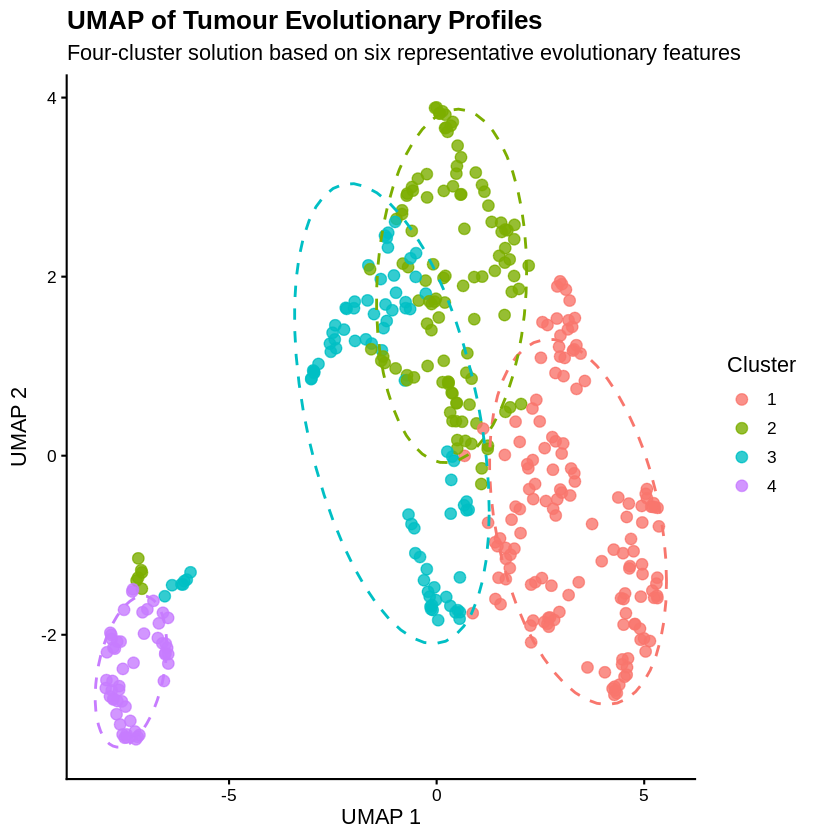


FEATURE DIFFERENCES ACROSS CLUSTERS
                  Feature Chi_square      p_value          FDR
1   first_branching_depth  294.98762 1.209370e-63 7.256219e-63
2   mean_branch_mutations  218.50535 4.224858e-47 1.267457e-46
3               max_depth  197.56973 1.413387e-42 2.826773e-42
4              n_terminal  170.83192 8.415227e-37 1.262284e-36
5 trunk_mutation_fraction  136.28944 2.384773e-29 2.861727e-29
6         total_mutations   96.25513 9.921095e-21 9.921095e-21


Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


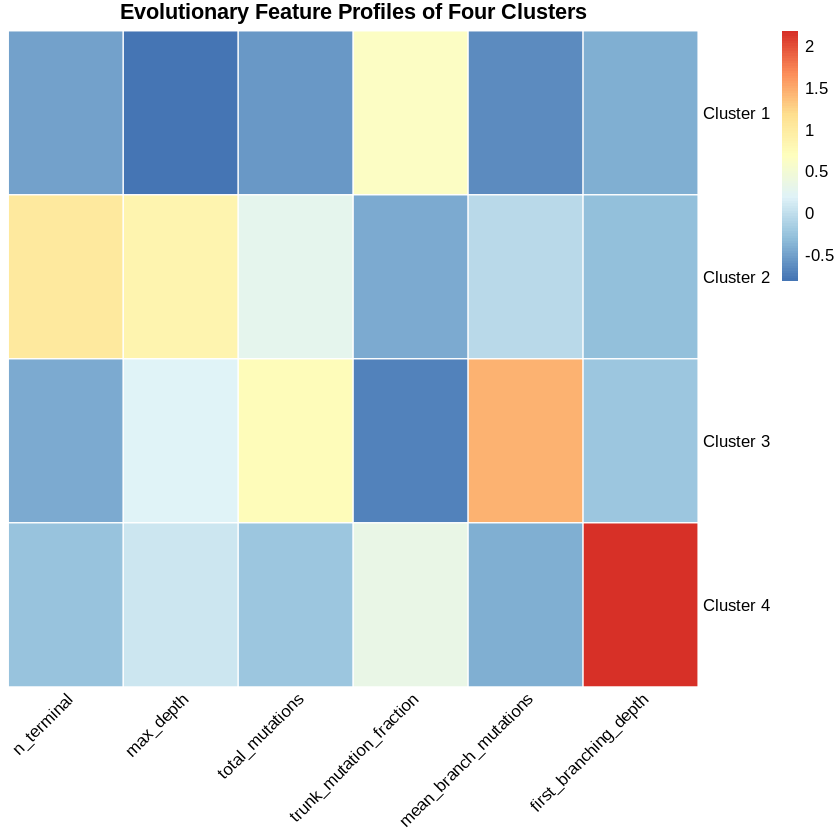


Cluster sizes:
  Cluster Patients Percentage
1       1      146      36.68
2       2      116      29.15
3       3       84      21.11
4       4       52      13.07


Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”



FOUR-CLUSTER ANALYSIS COMPLETE
Patients: 398 
Features: 6 
Requested clusters: 4
Mean silhouette (k=4): 0.2443 

K-means cluster sizes:
kmeans_cluster
  1   2   3   4 
146 116  84  52 

ARI:
               Comparison       ARI
1 K-means vs Hierarchical 0.3497529
2          K-means vs PAM 0.3832335
3     Hierarchical vs PAM 0.4862997

Analysis complete.


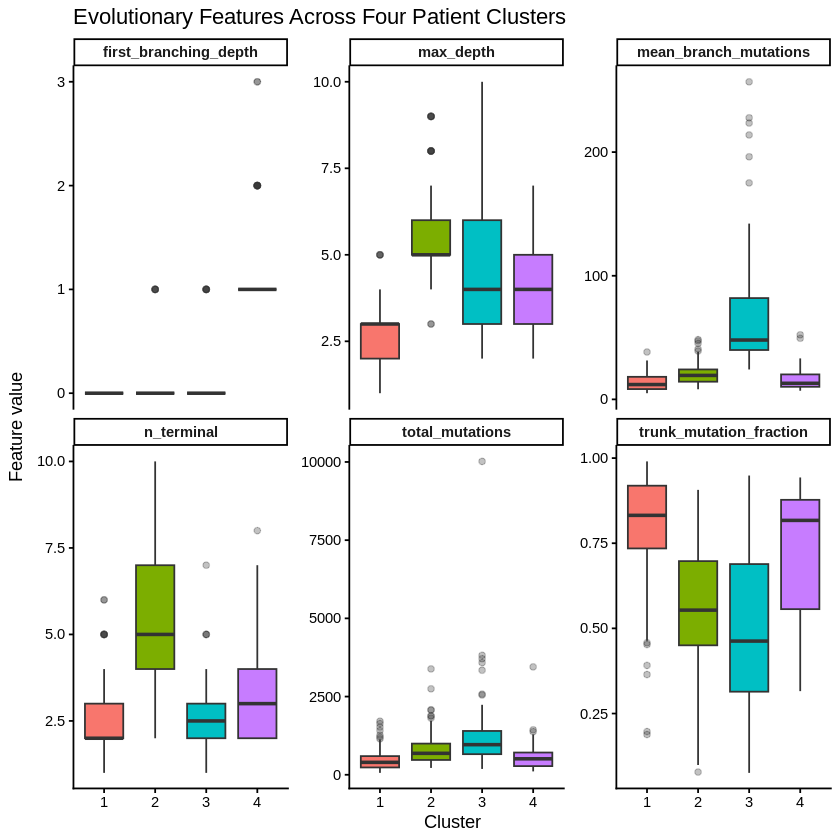

In [ ]:
# ============================================================
# FINAL REDUCED FEATURE ANALYSIS
# K = 4 CLUSTERING + UMAP + ARI + CLUSTER CHARACTERIZATION
# ============================================================

# ------------------------------------------------------------
# 0. PACKAGES
# ------------------------------------------------------------

packages <- c(
  "dplyr",
  "tidyr",
  "ggplot2",
  "cluster",
  "mclust",
  "uwot",
  "pheatmap"
)

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(dplyr)
library(tidyr)
library(ggplot2)
library(cluster)
library(mclust)
library(uwot)
library(pheatmap)

set.seed(42)


# ============================================================
# 1. FINAL SIX FEATURES
# ============================================================

final_selected_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

final_data <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(final_selected_features)
  )


cat("Patients:", nrow(final_data), "\n")
cat("Features:", length(final_selected_features), "\n")


# ============================================================
# 2. HANDLE Inf / NA
# ============================================================

X <- final_data %>%
  select(-patient_id)

X[] <- lapply(
  X,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)

cat(
  "Missing values before imputation:",
  sum(is.na(X)),
  "\n"
)

# Median imputation
X[] <- lapply(
  X,
  function(x) {

    if (any(is.na(x))) {

      x[is.na(x)] <-
        median(x, na.rm = TRUE)
    }

    x
  }
)

cat(
  "Missing values after imputation:",
  sum(is.na(X)),
  "\n"
)


# ============================================================
# 3. TRANSFORMATION
# Mutation-count variables are strongly right-skewed
# ============================================================

X_transformed <- X

X_transformed$total_mutations <-
  log1p(X_transformed$total_mutations)

X_transformed$mean_branch_mutations <-
  log1p(X_transformed$mean_branch_mutations)


# ============================================================
# 4. STANDARDIZATION
# Mean = 0, SD = 1
# ============================================================

X_scaled <- scale(X_transformed)

X_scaled <- as.data.frame(X_scaled)

rownames(X_scaled) <- final_data$patient_id


cat(
  "\nScaled matrix dimension:",
  dim(X_scaled),
  "\n"
)


# ============================================================
# 5. SILHOUETTE ANALYSIS k = 2 TO 10
# Keep this even though we will inspect k = 4
# ============================================================

silhouette_results <- data.frame(
  k = 2:10,
  silhouette = NA_real_
)

for (k in 2:10) {

  set.seed(42)

  km_temp <- kmeans(
    X_scaled,
    centers = k,
    nstart = 100,
    iter.max = 1000
  )

  sil_temp <- silhouette(
    km_temp$cluster,
    dist(X_scaled)
  )

  silhouette_results$silhouette[
    silhouette_results$k == k
  ] <- mean(sil_temp[, 3])
}


print(silhouette_results)


# ------------------------------------------------------------
# Silhouette plot
# ------------------------------------------------------------

silhouette_plot <- ggplot(
  silhouette_results,
  aes(
    x = k,
    y = silhouette
  )
) +

  geom_line(
    linewidth = 1
  ) +

  geom_point(
    size = 3
  ) +

  geom_point(
    data = subset(
      silhouette_results,
      k == 4
    ),
    size = 5,
    shape = 21,
    fill = "white",
    stroke = 1.3
  ) +

  scale_x_continuous(
    breaks = 2:10
  ) +

  labs(
    title = "Silhouette Analysis of Reduced Evolutionary Profiles",
    subtitle = "Four-cluster solution highlighted",
    x = "Number of clusters (k)",
    y = "Mean silhouette score"
  ) +

  theme_classic(base_size = 13)


print(silhouette_plot)


# ============================================================
# 6. K-MEANS — FIXED k = 4
# ============================================================

set.seed(42)

k4_kmeans <- kmeans(
  X_scaled,
  centers = 4,
  nstart = 200,
  iter.max = 1000
)

kmeans_cluster <- factor(
  k4_kmeans$cluster,
  levels = 1:4
)


cat(
  "\nK-means cluster sizes:\n"
)

print(
  table(kmeans_cluster)
)


# ============================================================
# 7. HIERARCHICAL CLUSTERING — k = 4
# ============================================================

distance_matrix <- dist(
  X_scaled,
  method = "euclidean"
)

hc <- hclust(
  distance_matrix,
  method = "ward.D2"
)

hc_cluster <- factor(
  cutree(
    hc,
    k = 4
  ),
  levels = 1:4
)


cat(
  "\nHierarchical cluster sizes:\n"
)

print(
  table(hc_cluster)
)


# ============================================================
# 8. PAM — k = 4
# ============================================================

pam_fit <- pam(
  X_scaled,
  k = 4
)

pam_cluster <- factor(
  pam_fit$clustering,
  levels = 1:4
)


cat(
  "\nPAM cluster sizes:\n"
)

print(
  table(pam_cluster)
)


# ============================================================
# 9. ARI BETWEEN CLUSTERING METHODS
# ============================================================

ARI_table <- data.frame(

  Comparison = c(
    "K-means vs Hierarchical",
    "K-means vs PAM",
    "Hierarchical vs PAM"
  ),

  ARI = c(

    adjustedRandIndex(
      kmeans_cluster,
      hc_cluster
    ),

    adjustedRandIndex(
      kmeans_cluster,
      pam_cluster
    ),

    adjustedRandIndex(
      hc_cluster,
      pam_cluster
    )
  )
)


cat(
  "\n========================================\n"
)

cat(
  "CLUSTER AGREEMENT (ARI)\n"
)

cat(
  "========================================\n"
)

print(ARI_table)


# ============================================================
# 10. SILHOUETTE SCORE FOR k = 4
# ============================================================

sil_k4 <- silhouette(
  as.integer(kmeans_cluster),
  distance_matrix
)

mean_sil_k4 <- mean(
  sil_k4[, 3]
)


cat(
  "\nMean silhouette for k = 4:",
  round(mean_sil_k4, 4),
  "\n"
)


# ============================================================
# 11. UMAP
# ============================================================

set.seed(42)

umap_result <- uwot::umap(

  X_scaled,

  n_neighbors = 15,

  min_dist = 0.10,

  metric = "euclidean",

  n_components = 2,

  scale = FALSE,

  verbose = TRUE
)


umap_df <- data.frame(

  patient_id =
    final_data$patient_id,

  UMAP1 =
    umap_result[, 1],

  UMAP2 =
    umap_result[, 2],

  Cluster =
    kmeans_cluster
)


# ============================================================
# 12. FOUR-CLUSTER UMAP PLOT
# ============================================================

umap_plot <- ggplot(
  umap_df,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = Cluster
  )
) +

  geom_point(
    size = 2.8,
    alpha = 0.80
  ) +

  stat_ellipse(
    aes(
      group = Cluster
    ),
    linewidth = 0.8,
    linetype = 2,
    level = 0.80,
    show.legend = FALSE
  ) +

  labs(
    title =
      "UMAP of Tumour Evolutionary Profiles",

    subtitle =
      "Four-cluster solution based on six representative evolutionary features",

    x = "UMAP 1",

    y = "UMAP 2",

    color = "Cluster"
  ) +

  theme_classic(
    base_size = 13
  ) +

  theme(

    legend.position = "right",

    plot.title =
      element_text(
        face = "bold"
      )
  )


print(umap_plot)


# ============================================================
# 13. PATIENT CLUSTER ASSIGNMENTS
# ============================================================

patient_clusters <- data.frame(

  patient_id =
    final_data$patient_id,

  kmeans_cluster =
    kmeans_cluster,

  hierarchical_cluster =
    hc_cluster,

  pam_cluster =
    pam_cluster,

  UMAP1 =
    umap_result[, 1],

  UMAP2 =
    umap_result[, 2]
)


head(patient_clusters)


# ============================================================
# 14. CLUSTER FEATURE PROFILES
# ============================================================

cluster_profile_data <- final_data

cluster_profile_data$Cluster <-
  kmeans_cluster


cluster_profiles <- cluster_profile_data %>%

  group_by(Cluster) %>%

  summarise(

    across(

      all_of(final_selected_features),

      list(
        median = ~ median(
          .x,
          na.rm = TRUE
        ),

        mean = ~ mean(
          .x,
          na.rm = TRUE
        )
      )
    ),

    .groups = "drop"
  )


cat(
  "\nCluster feature profiles:\n"
)

print(cluster_profiles)


# ============================================================
# 15. STANDARDIZED CLUSTER CENTROIDS
# ============================================================

centroid_df <- as.data.frame(
  k4_kmeans$centers
)

centroid_df$Cluster <-
  paste0(
    "Cluster ",
    1:4
  )

rownames(centroid_df) <-
  centroid_df$Cluster

centroid_matrix <- centroid_df %>%
  select(-Cluster) %>%
  as.matrix()


cat(
  "\nStandardized cluster centroids:\n"
)

print(
  round(
    centroid_matrix,
    2
  )
)


# ============================================================
# 16. CLUSTER PROFILE HEATMAP
# ============================================================

pheatmap(

  centroid_matrix,

  cluster_rows = FALSE,

  cluster_cols = FALSE,

  border_color = "white",

  main =
    "Evolutionary Feature Profiles of Four Clusters",

  angle_col = 45
)


# ============================================================
# 17. KRUSKAL-WALLIS TEST
# Which features distinguish the four clusters?
# ============================================================

statistical_results <- lapply(

  final_selected_features,

  function(feature) {

    test <- kruskal.test(

      cluster_profile_data[[feature]] ~

        cluster_profile_data$Cluster
    )

    data.frame(

      Feature = feature,

      Chi_square =
        unname(test$statistic),

      p_value =
        test$p.value
    )
  }
)


statistical_results <-
  bind_rows(statistical_results)


# BH FDR correction

statistical_results <-
  statistical_results %>%

  mutate(

    FDR =
      p.adjust(
        p_value,
        method = "BH"
      )

  ) %>%

  arrange(FDR)


cat(
  "\n========================================\n"
)

cat(
  "FEATURE DIFFERENCES ACROSS CLUSTERS\n"
)

cat(
  "========================================\n"
)

print(statistical_results)


# ============================================================
# 18. FEATURE BOXPLOTS
# ============================================================

boxplot_data <- cluster_profile_data %>%

  pivot_longer(

    cols =
      all_of(final_selected_features),

    names_to =
      "Feature",

    values_to =
      "Value"
  )


feature_boxplots <- ggplot(

  boxplot_data,

  aes(
    x = Cluster,
    y = Value,
    fill = Cluster
  )

) +

  geom_boxplot(
    outlier.alpha = 0.3
  ) +

  facet_wrap(
    ~ Feature,
    scales = "free_y",
    ncol = 3
  ) +

  labs(

    title =
      "Evolutionary Features Across Four Patient Clusters",

    x =
      "Cluster",

    y =
      "Feature value"

  ) +

  theme_classic(
    base_size = 11
  ) +

  theme(
    legend.position = "none",

    strip.text =
      element_text(
        face = "bold"
      )
  )


print(feature_boxplots)


# ============================================================
# 19. CLUSTER SIZE TABLE
# ============================================================

cluster_size_table <- data.frame(

  Cluster =
    names(
      table(kmeans_cluster)
    ),

  Patients =
    as.numeric(
      table(kmeans_cluster)
    )
)


cluster_size_table$Percentage <-

  round(

    100 *

      cluster_size_table$Patients /

      sum(
        cluster_size_table$Patients
      ),

    2
  )


cat(
  "\nCluster sizes:\n"
)

print(
  cluster_size_table
)


# ============================================================
# 20. SAVE RESULTS
# ============================================================

write.csv(

  patient_clusters,

  "K4_Patient_Cluster_Assignments.csv",

  row.names = FALSE
)


write.csv(

  cluster_profiles,

  "K4_Cluster_Feature_Profiles.csv",

  row.names = FALSE
)


write.csv(

  statistical_results,

  "K4_Feature_Kruskal_Wallis_FDR.csv",

  row.names = FALSE
)


write.csv(

  ARI_table,

  "K4_Clustering_Method_ARI.csv",

  row.names = FALSE
)


write.csv(

  cluster_size_table,

  "K4_Cluster_Sizes.csv",

  row.names = FALSE
)


write.csv(

  silhouette_results,

  "Reduced_Feature_Silhouette_k2_k10.csv",

  row.names = FALSE
)


# ============================================================
# 21. SAVE FIGURES
# ============================================================

ggsave(

  "K4_UMAP_Final_Reduced_Features.pdf",

  umap_plot,

  width = 8,

  height = 6
)


ggsave(

  "K4_UMAP_Final_Reduced_Features.png",

  umap_plot,

  width = 8,

  height = 6,

  dpi = 600
)


ggsave(

  "K4_Feature_Boxplots.pdf",

  feature_boxplots,

  width = 11,

  height = 8
)


ggsave(

  "Reduced_Feature_Silhouette_Analysis.pdf",

  silhouette_plot,

  width = 7,

  height = 5
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

cat(
  "\n============================================\n"
)

cat(
  "FOUR-CLUSTER ANALYSIS COMPLETE\n"
)

cat(
  "============================================\n"
)

cat(
  "Patients:",
  nrow(final_data),
  "\n"
)

cat(
  "Features:",
  length(final_selected_features),
  "\n"
)

cat(
  "Requested clusters: 4\n"
)

cat(
  "Mean silhouette (k=4):",
  round(mean_sil_k4, 4),
  "\n"
)

cat(
  "\nK-means cluster sizes:\n"
)

print(
  table(kmeans_cluster)
)

cat(
  "\nARI:\n"
)

print(ARI_table)

cat(
  "\nAnalysis complete.\n"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




FINAL SIX-FEATURE MATRIX
Patients: 398 
Features: 6 
[1] "n_terminal"              "max_depth"              
[3] "total_mutations"         "trunk_mutation_fraction"
[5] "mean_branch_mutations"   "first_branching_depth"  

Missing values before imputation: 21 
                                        Feature Missing
n_terminal                           n_terminal       0
max_depth                             max_depth       0
total_mutations                 total_mutations       0
trunk_mutation_fraction trunk_mutation_fraction       0
mean_branch_mutations     mean_branch_mutations       0
first_branching_depth     first_branching_depth      21

Missing values after imputation: 0 

Scaled feature matrix: 398 patients x 6 features

SILHOUETTE ANALYSIS
   k average_silhouette
1  2          0.2408694
2  3          0.2550279
3  4          0.2442572
4  5          0.2169240
5  6          0.2157078
6  7          0.2049415
7  8          0.2025418
8  9          0.2093932
9 10          0.2148175

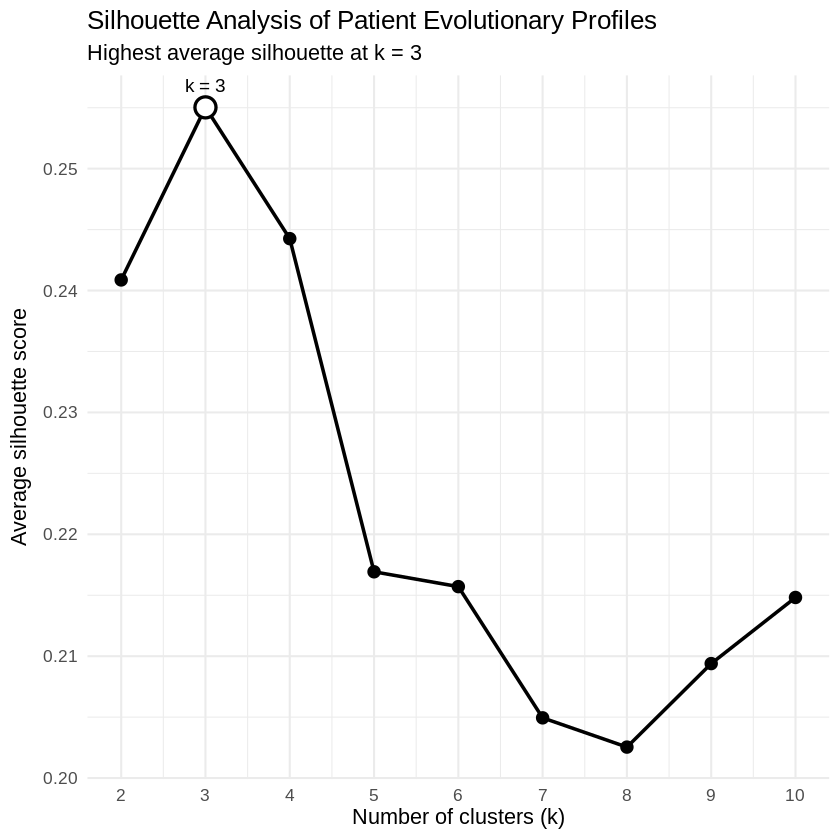

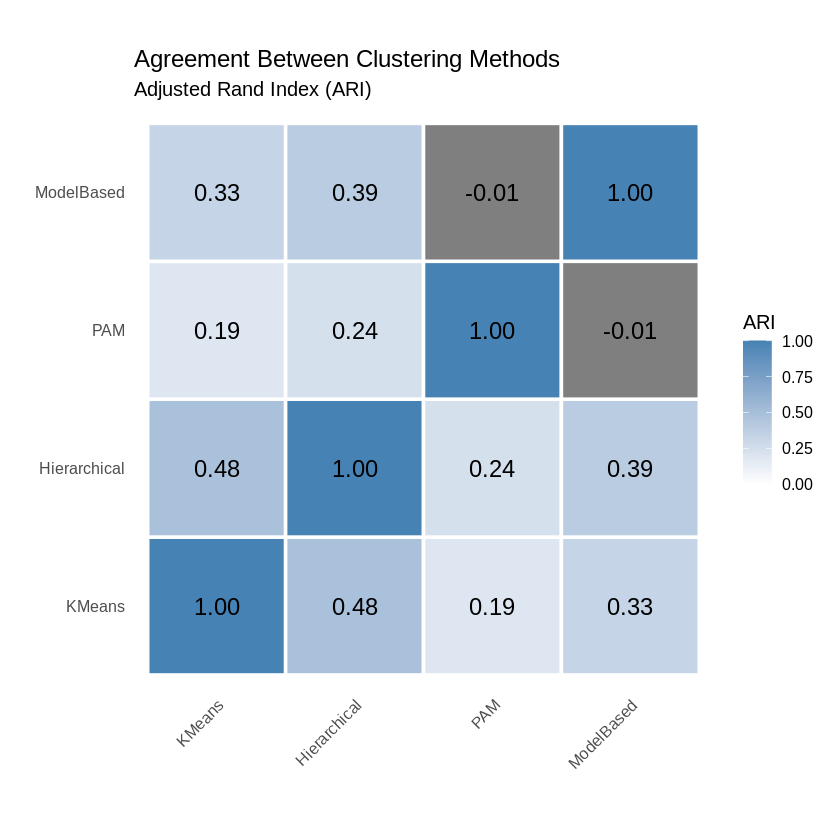

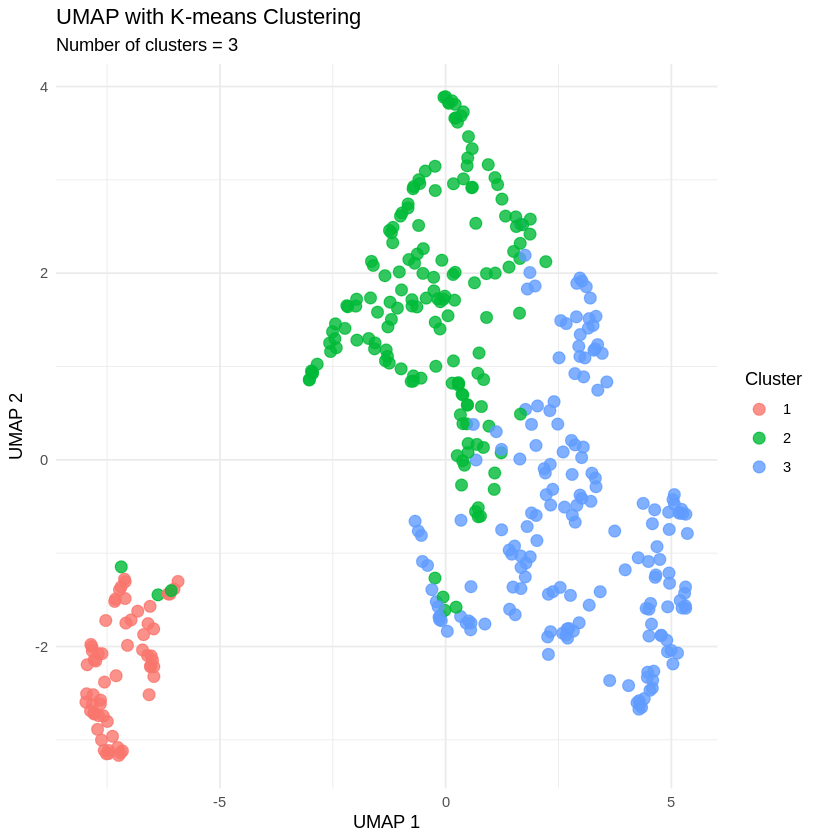

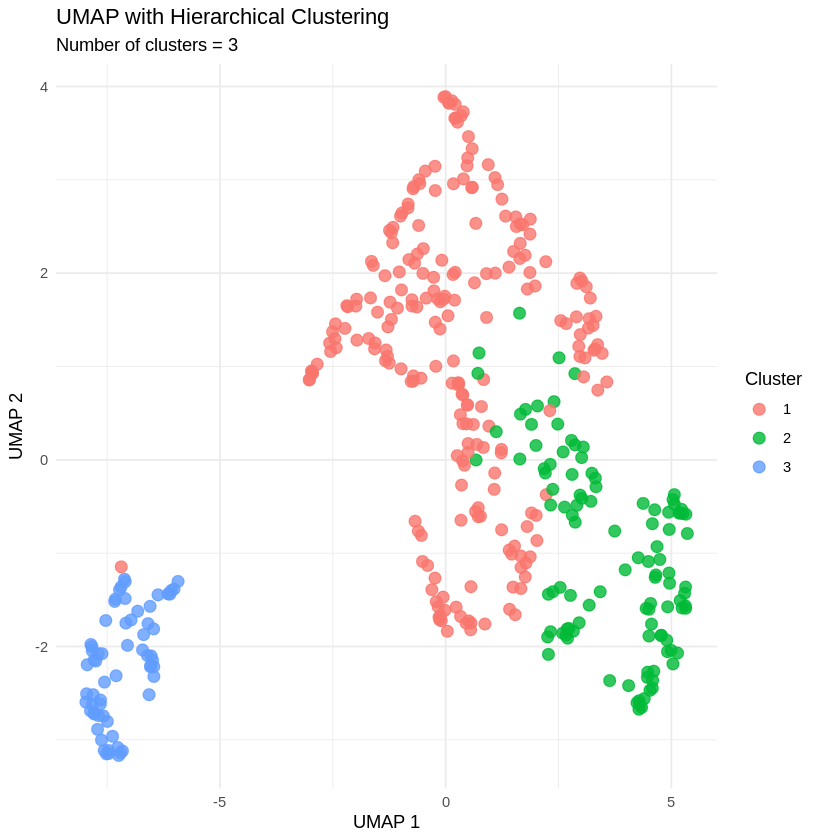

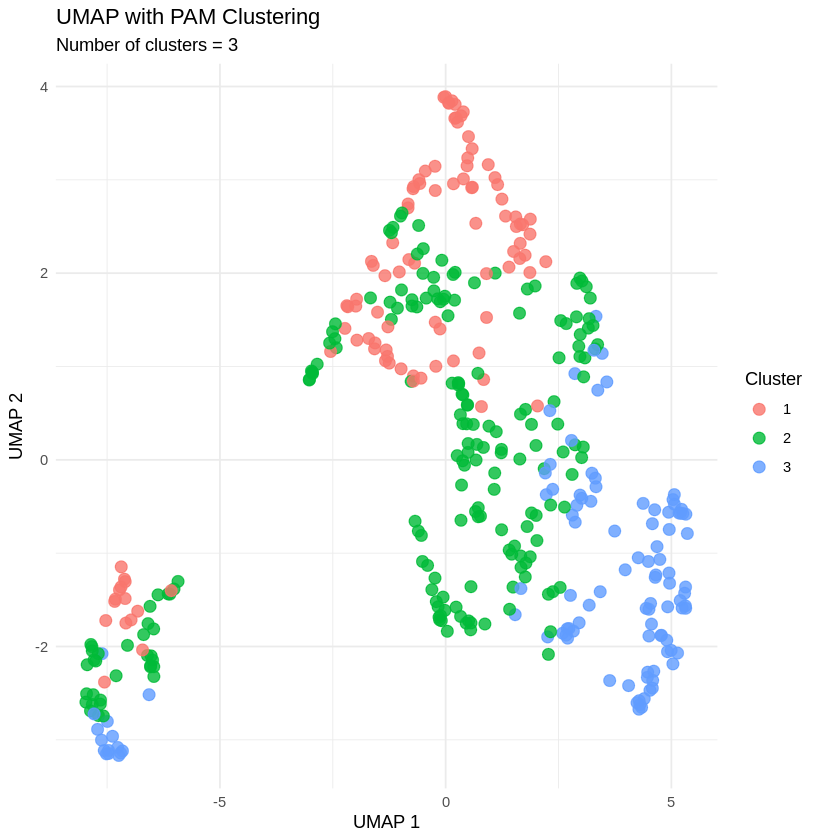

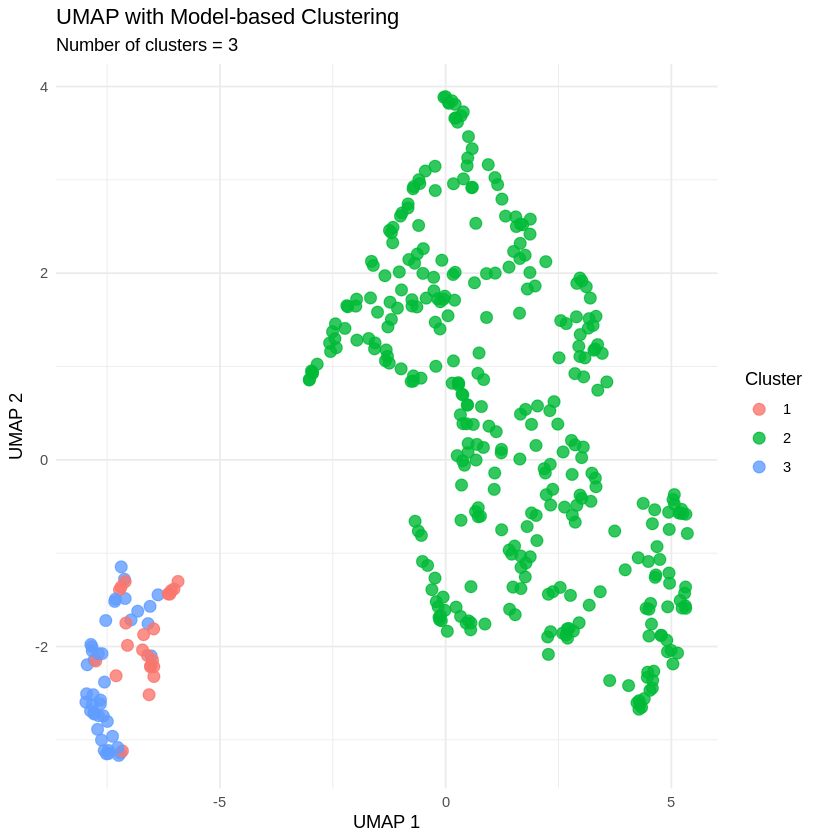


K-MEANS CLUSTER SIZES
  Cluster Patients Percentage
1       1       62      15.58
2       2      161      40.45
3       3      175      43.97

STANDARDIZED CLUSTER CENTROIDS
          n_terminal max_depth total_mutations trunk_mutation_fraction
Cluster 1      -0.09      0.13           -0.14                    0.19
Cluster 2       0.53      0.78            0.49                   -0.70
Cluster 3      -0.45     -0.77           -0.40                    0.58
          mean_branch_mutations first_branching_depth
Cluster 1                 -0.24                  2.10
Cluster 2                  0.56                 -0.37
Cluster 3                 -0.43                 -0.41


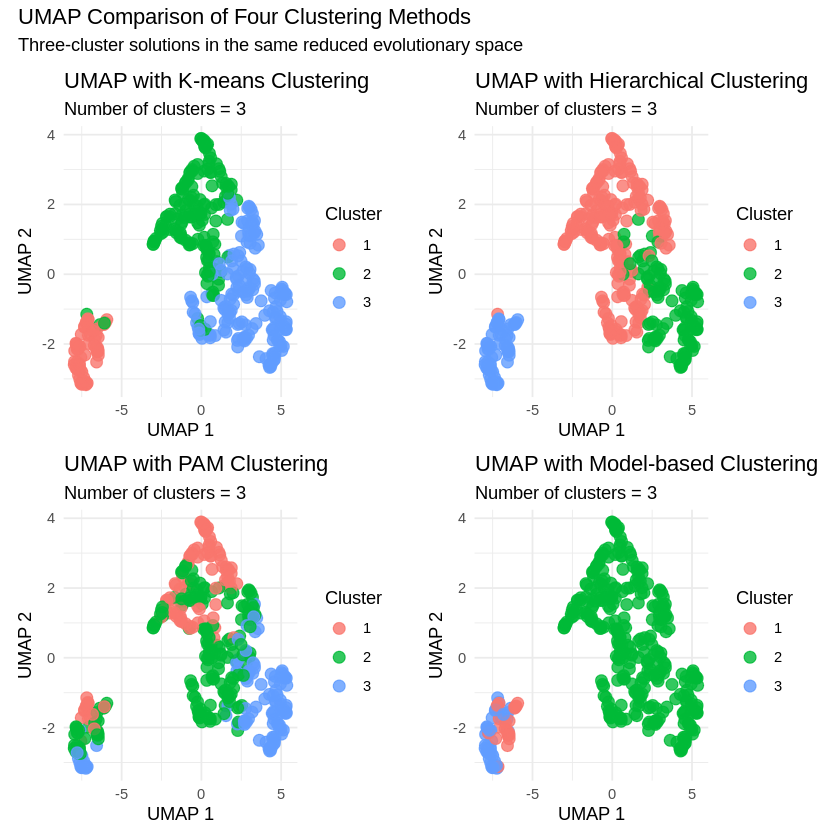


CLUSTER FEATURE PROFILES
# A tibble: 3 × 13
  Cluster n_terminal_median n_terminal_mean max_depth_median max_depth_mean
  <fct>               <dbl>           <dbl>            <dbl>          <dbl>
1 1                       3            3.39                4           4.35
2 2                       4            4.56                5           5.55
3 3                       2            2.69                3           2.71
# ℹ 8 more variables: total_mutations_median <dbl>, total_mutations_mean <dbl>,
#   trunk_mutation_fraction_median <dbl>, trunk_mutation_fraction_mean <dbl>,
#   mean_branch_mutations_median <dbl>, mean_branch_mutations_mean <dbl>,
#   first_branching_depth_median <dbl>, first_branching_depth_mean <dbl>


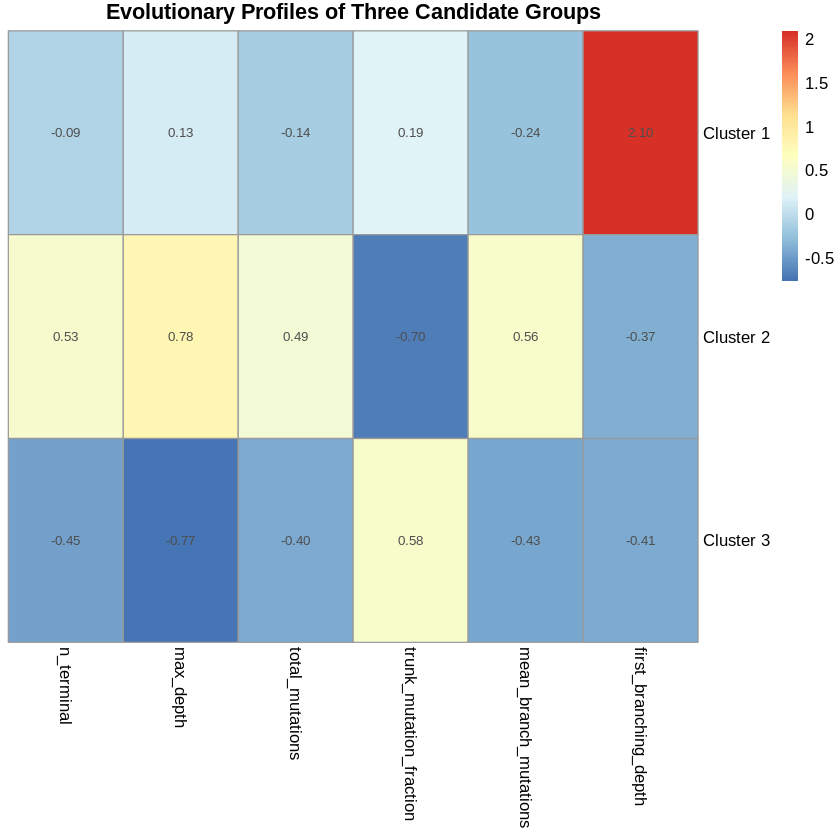


KRUSKAL-WALLIS + BH-FDR
                  Feature Chi_square      p_value          FDR
1   first_branching_depth  375.00816 3.698397e-82 2.219038e-81
2               max_depth  220.46783 1.336653e-48 4.009960e-48
3 trunk_mutation_fraction  144.61535 3.955263e-32 7.910527e-32
4   mean_branch_mutations   95.26978 2.053197e-21 3.079795e-21
5              n_terminal   92.35185 8.831840e-21 1.059821e-20
6         total_mutations   65.55523 5.819191e-15 5.819191e-15

REPRESENTATIVE PATIENTS
3 PATIENTS PER CLUSTER
# A tibble: 9 × 3
  patient_id       cluster distance_to_centroid
  <chr>              <int>                <dbl>
1 CRUK0051               1                0.735
2 CRUK0579               1                0.780
3 CRUK0679               1                1.06 
4 CRUK0586_Tumour2       2                0.513
5 CRUK0068               2                0.634
6 CRUK0284               2                0.651
7 CRUK0078               3                0.403
8 CRUK0625               3          

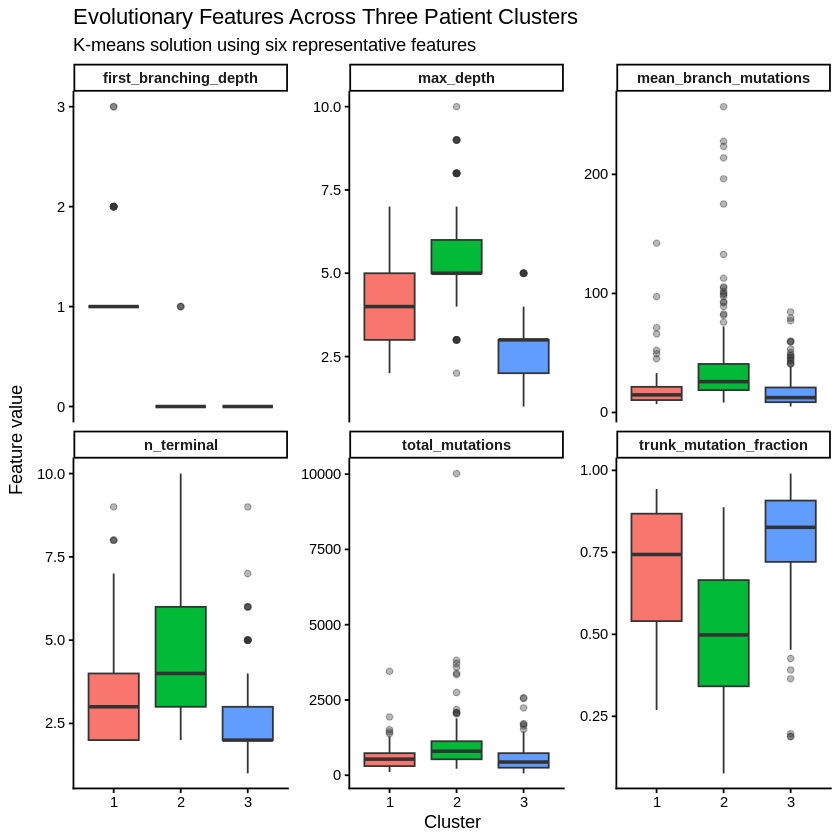


FINAL SIX-FEATURE ANALYSIS COMPLETE

Patients: 398 
Features: 6 
Optimal k from silhouette: 3 
Final k: 3 

Silhouette analysis:
   k average_silhouette
1  2          0.2408694
2  3          0.2550279
3  4          0.2442572
4  5          0.2169240
5  6          0.2157078
6  7          0.2049415
7  8          0.2025418
8  9          0.2093932
9 10          0.2148175

Cluster size comparison:

K-means:
cluster_kmeans
  1   2   3 
 62 161 175 

Hierarchical:
cluster_hierarchical
  1   2   3 
225 109  64 

PAM:
cluster_pam
  1   2   3 
 99 192 107 

Model-based:
cluster_mclust
  1   2   3 
 23 333  42 

Method silhouette scores:
        Method Average_Silhouette
1      K-means          0.2550279
2 Hierarchical          0.1878091
3          PAM          0.1599972
4  Model-based          0.1810263

ARI matrix:
             KMeans Hierarchical    PAM ModelBased
KMeans        1.000        0.482  0.186      0.332
Hierarchical  0.482        1.000  0.239      0.393
PAM           0.186        0.

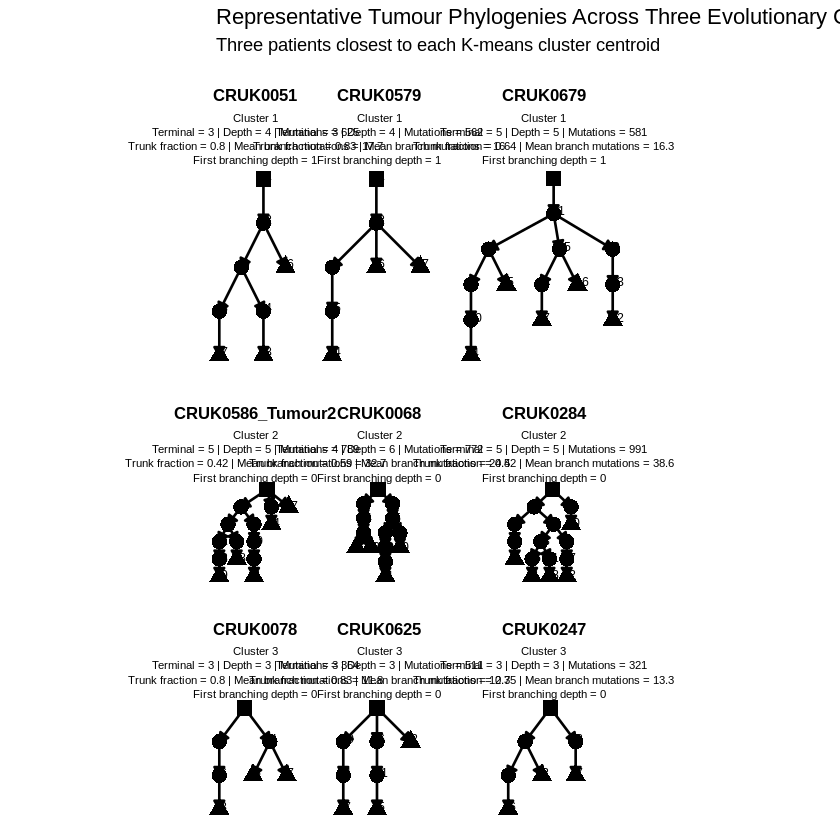

In [ ]:
# ============================================================
# FINAL ANALYSIS
#
# 6 FINAL FEATURES
# -> PREPROCESSING
# -> SILHOUETTE ANALYSIS (k = 2:10)
# -> OPTIMAL k = 3
# -> 4 CLUSTERING METHODS
#       1. K-MEANS
#       2. HIERARCHICAL
#       3. PAM
#       4. GMM / MODEL-BASED
# -> METHOD SILHOUETTE COMPARISON
# -> ADJUSTED RAND INDEX (ARI)
# -> ARI HEATMAP
# -> UMAP FOR ALL FOUR METHODS
# -> K-MEANS CLUSTER CHARACTERIZATION
# -> STANDARDIZED CENTROID HEATMAP
# -> FEATURE BOXPLOTS
# -> KRUSKAL-WALLIS + BH-FDR
# -> 3 REPRESENTATIVE PATIENTS PER CLUSTER
# -> 9 ACTUAL REPRESENTATIVE TUMOUR TREES
# -> SAVE ALL OUTPUTS
# ============================================================


# ============================================================
# 0. INSTALL AND LOAD PACKAGES
# ============================================================

required_packages <- c(
  "dplyr",
  "tidyr",
  "ggplot2",
  "cluster",
  "mclust",
  "uwot",
  "igraph",
  "pheatmap",
  "patchwork"
)

new_packages <- required_packages[
  !(required_packages %in% rownames(installed.packages()))
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(cluster)
  library(mclust)
  library(uwot)
  library(igraph)
  library(pheatmap)
  library(patchwork)
})

set.seed(42)


# ============================================================
# 1. FINAL SIX BIOLOGICALLY REPRESENTATIVE FEATURES
# ============================================================

final_selected_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

# Check features exist
missing_features <- setdiff(
  final_selected_features,
  colnames(patient_level_feature_matrix)
)

if (length(missing_features) > 0) {

  stop(
    paste(
      "Missing features:",
      paste(missing_features, collapse = ", ")
    )
  )
}


final_data <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(final_selected_features)
  )


cat("\n========================================\n")
cat("FINAL SIX-FEATURE MATRIX\n")
cat("========================================\n")

cat(
  "Patients:",
  nrow(final_data),
  "\n"
)

cat(
  "Features:",
  length(final_selected_features),
  "\n"
)

print(
  final_selected_features
)


# ============================================================
# 2. PREPROCESSING
# ============================================================

X_raw <- final_data %>%
  select(-patient_id)


# ------------------------------------------------------------
# 2.1 Convert Inf / -Inf to NA
# ------------------------------------------------------------

X_raw[] <- lapply(
  X_raw,
  function(x) {

    x[is.infinite(x)] <- NA

    x
  }
)


cat(
  "\nMissing values before imputation:",
  sum(is.na(X_raw)),
  "\n"
)


# Save missingness per feature
missingness_table <- data.frame(

  Feature =
    colnames(X_raw),

  Missing =
    sapply(
      X_raw,
      function(x) sum(is.na(x))
    )
)


print(
  missingness_table
)


# ------------------------------------------------------------
# 2.2 Median imputation
# ------------------------------------------------------------

X_imputed <- X_raw

X_imputed[] <- lapply(
  X_imputed,
  function(x) {

    if (any(is.na(x))) {

      med <- median(
        x,
        na.rm = TRUE
      )

      x[is.na(x)] <- med
    }

    x
  }
)


cat(
  "\nMissing values after imputation:",
  sum(is.na(X_imputed)),
  "\n"
)


# ------------------------------------------------------------
# 2.3 Log-transform mutation burden variables
# ------------------------------------------------------------

X_transformed <- X_imputed

X_transformed$total_mutations <-
  log1p(
    X_transformed$total_mutations
  )

X_transformed$mean_branch_mutations <-
  log1p(
    X_transformed$mean_branch_mutations
  )


# ------------------------------------------------------------
# 2.4 Z-score standardization
# ------------------------------------------------------------

scaled_features <- scale(
  X_transformed
)

scaled_features <- as.data.frame(
  scaled_features
)

rownames(
  scaled_features
) <- final_data$patient_id


cat(
  "\nScaled feature matrix:",
  nrow(scaled_features),
  "patients x",
  ncol(scaled_features),
  "features\n"
)


# ============================================================
# 3. EUCLIDEAN DISTANCE MATRIX
# ============================================================

patient_dist <- dist(
  scaled_features,
  method = "euclidean"
)


# ============================================================
# 4. SILHOUETTE ANALYSIS
# k = 2 TO 10
# ============================================================

silhouette_results <- data.frame(

  k = 2:10,

  average_silhouette =
    NA_real_
)


for (k in 2:10) {

  set.seed(42)

  temp_kmeans <- kmeans(

    scaled_features,

    centers = k,

    nstart = 200,

    iter.max = 1000
  )


  temp_silhouette <- cluster::silhouette(

    temp_kmeans$cluster,

    patient_dist
  )


  silhouette_results$average_silhouette[
    silhouette_results$k == k
  ] <- mean(
    temp_silhouette[, 3]
  )
}


cat("\n========================================\n")
cat("SILHOUETTE ANALYSIS\n")
cat("========================================\n")

print(
  silhouette_results
)


optimal_k <- silhouette_results$k[
  which.max(
    silhouette_results$average_silhouette
  )
]


max_silhouette <- max(
  silhouette_results$average_silhouette
)


cat(
  "\nOptimal number of clusters:",
  optimal_k,
  "\n"
)

cat(
  "Maximum average silhouette:",
  round(max_silhouette, 4),
  "\n"
)


# ============================================================
# 5. SILHOUETTE PLOT
# ============================================================

silhouette_plot <- ggplot(

  silhouette_results,

  aes(
    x = k,
    y = average_silhouette
  )

) +

  geom_line(
    linewidth = 1
  ) +

  geom_point(
    size = 3
  ) +

  geom_point(

    data = silhouette_results %>%
      filter(k == optimal_k),

    size = 5,

    shape = 21,

    fill = "white",

    stroke = 1.4
  ) +

  geom_text(

    data = silhouette_results %>%
      filter(k == optimal_k),

    aes(
      label = paste0(
        "k = ",
        optimal_k
      )
    ),

    vjust = -1.2,

    size = 4
  ) +

  scale_x_continuous(
    breaks = 2:10
  ) +

  labs(

    title =
      "Silhouette Analysis of Patient Evolutionary Profiles",

    subtitle =
      paste0(
        "Highest average silhouette at k = ",
        optimal_k
      ),

    x =
      "Number of clusters (k)",

    y =
      "Average silhouette score"
  ) +

  theme_minimal(
    base_size = 13
  )


print(
  silhouette_plot
)


# ============================================================
# 6. FINAL NUMBER OF CLUSTERS
# ============================================================

# Silhouette analysis should identify k = 3.
# For the final analysis, use three clusters.

k_final <- 3


# ============================================================
# 7. K-MEANS CLUSTERING
# ============================================================

set.seed(42)

kmeans_result <- kmeans(

  scaled_features,

  centers = k_final,

  nstart = 500,

  iter.max = 1000
)


cluster_kmeans <-
  kmeans_result$cluster


# ============================================================
# 8. HIERARCHICAL CLUSTERING
# ============================================================

hierarchical_result <- hclust(

  patient_dist,

  method = "ward.D2"
)


cluster_hierarchical <- cutree(

  hierarchical_result,

  k = k_final
)


# ============================================================
# 9. PAM CLUSTERING
# ============================================================

pam_result <- cluster::pam(

  scaled_features,

  k = k_final
)


cluster_pam <-
  pam_result$clustering


# ============================================================
# 10. GMM / MODEL-BASED CLUSTERING
# ============================================================

set.seed(42)

mclust_result <- mclust::Mclust(

  scaled_features,

  G = k_final,

  verbose = FALSE
)


cluster_mclust <-
  mclust_result$classification


# ============================================================
# 11. CLUSTER SIZE COMPARISON
# ============================================================

cat("\n========================================\n")
cat("CLUSTER SIZE COMPARISON\n")
cat("========================================\n")


cat("\nK-means:\n")

print(
  table(cluster_kmeans)
)


cat("\nHierarchical:\n")

print(
  table(cluster_hierarchical)
)


cat("\nPAM:\n")

print(
  table(cluster_pam)
)


cat("\nModel-based / GMM:\n")

print(
  table(cluster_mclust)
)


# ============================================================
# 12. PATIENT CLUSTER ASSIGNMENT TABLE
# ============================================================

cluster_assignment_table <- data.frame(

  patient_id =
    final_data$patient_id,

  KMeans =
    cluster_kmeans,

  Hierarchical =
    cluster_hierarchical,

  PAM =
    cluster_pam,

  ModelBased =
    cluster_mclust
)


cat(
  "\nFirst cluster assignments:\n"
)

print(
  head(cluster_assignment_table)
)


# ============================================================
# 13. SILHOUETTE SCORE FOR EACH CLUSTERING METHOD
# ============================================================

sil_kmeans <- cluster::silhouette(
  cluster_kmeans,
  patient_dist
)

sil_hierarchical <- cluster::silhouette(
  cluster_hierarchical,
  patient_dist
)

sil_pam <- cluster::silhouette(
  cluster_pam,
  patient_dist
)

sil_mclust <- cluster::silhouette(
  cluster_mclust,
  patient_dist
)


method_silhouette <- data.frame(

  Method = c(
    "K-means",
    "Hierarchical",
    "PAM",
    "Model-based"
  ),

  Average_Silhouette = c(

    mean(
      sil_kmeans[, 3]
    ),

    mean(
      sil_hierarchical[, 3]
    ),

    mean(
      sil_pam[, 3]
    ),

    mean(
      sil_mclust[, 3]
    )
  )
)


cat("\n========================================\n")
cat("METHOD SILHOUETTE SCORES\n")
cat("========================================\n")

print(
  method_silhouette
)


# ============================================================
# 14. ADJUSTED RAND INDEX MATRIX
# ============================================================

cluster_list <- list(

  KMeans =
    cluster_kmeans,

  Hierarchical =
    cluster_hierarchical,

  PAM =
    cluster_pam,

  ModelBased =
    cluster_mclust
)


method_names <- names(
  cluster_list
)


ari_matrix <- matrix(

  NA_real_,

  nrow =
    length(cluster_list),

  ncol =
    length(cluster_list),

  dimnames = list(
    method_names,
    method_names
  )
)


for (i in seq_along(cluster_list)) {

  for (j in seq_along(cluster_list)) {

    ari_matrix[i, j] <-

      mclust::adjustedRandIndex(

        cluster_list[[i]],

        cluster_list[[j]]
      )
  }
}


cat("\n========================================\n")
cat("ADJUSTED RAND INDEX (ARI) MATRIX\n")
cat("========================================\n")

print(
  round(
    ari_matrix,
    3
  )
)


# ============================================================
# 15. ARI HEATMAP
# ============================================================

ari_df <- as.data.frame(
  as.table(
    ari_matrix
  )
)


colnames(
  ari_df
) <- c(
  "Method1",
  "Method2",
  "ARI"
)


ari_heatmap <- ggplot(

  ari_df,

  aes(
    x = Method1,
    y = Method2,
    fill = ARI
  )

) +

  geom_tile(
    color = "white",
    linewidth = 1
  ) +

  geom_text(

    aes(
      label = sprintf(
        "%.2f",
        ARI
      )
    ),

    size = 5
  ) +

  scale_fill_gradient(

    low = "white",

    high = "steelblue",

    limits = c(0, 1)
  ) +

  labs(

    title =
      "Agreement Between Clustering Methods",

    subtitle =
      "Adjusted Rand Index (ARI)",

    x = NULL,

    y = NULL,

    fill = "ARI"
  ) +

  coord_fixed() +

  theme_minimal(
    base_size = 12
  ) +

  theme(

    panel.grid =
      element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1
      )
  )


print(
  ari_heatmap
)


# ============================================================
# 16. UMAP EMBEDDING
# SAME UMAP COORDINATES FOR ALL METHODS
# ============================================================

set.seed(42)

umap_result <- uwot::umap(

  scaled_features,

  n_neighbors = 15,

  min_dist = 0.10,

  n_components = 2,

  metric = "euclidean"
)


# ============================================================
# 17. UMAP DATA FRAME
# ============================================================

umap_comparison <- data.frame(

  patient_id =
    final_data$patient_id,

  UMAP1 =
    umap_result[, 1],

  UMAP2 =
    umap_result[, 2],

  KMeans =
    factor(cluster_kmeans),

  Hierarchical =
    factor(cluster_hierarchical),

  PAM =
    factor(cluster_pam),

  ModelBased =
    factor(cluster_mclust)
)


# ============================================================
# 18. UMAP + K-MEANS
# ============================================================

umap_kmeans_plot <- ggplot(

  umap_comparison,

  aes(
    x = UMAP1,
    y = UMAP2,
    color = KMeans
  )

) +

  geom_point(
    size = 3,
    alpha = 0.8
  ) +

  labs(

    title =
      "UMAP with K-means Clustering",

    subtitle =
      paste(
        "Number of clusters =",
        k_final
      ),

    x =
      "UMAP 1",

    y =
      "UMAP 2",

    color =
      "Cluster"
  ) +

  theme_minimal()


print(
  umap_kmeans_plot
)


# ============================================================
# 19. UMAP + HIERARCHICAL
# ============================================================

umap_hierarchical_plot <- ggplot(

  umap_comparison,

  aes(
    x = UMAP1,
    y = UMAP2,
    color = Hierarchical
  )

) +

  geom_point(
    size = 3,
    alpha = 0.8
  ) +

  labs(

    title =
      "UMAP with Hierarchical Clustering",

    subtitle =
      paste(
        "Number of clusters =",
        k_final
      ),

    x =
      "UMAP 1",

    y =
      "UMAP 2",

    color =
      "Cluster"
  ) +

  theme_minimal()


print(
  umap_hierarchical_plot
)


# ============================================================
# 20. UMAP + PAM
# ============================================================

umap_pam_plot <- ggplot(

  umap_comparison,

  aes(
    x = UMAP1,
    y = UMAP2,
    color = PAM
  )

) +

  geom_point(
    size = 3,
    alpha = 0.8
  ) +

  labs(

    title =
      "UMAP with PAM Clustering",

    subtitle =
      paste(
        "Number of clusters =",
        k_final
      ),

    x =
      "UMAP 1",

    y =
      "UMAP 2",

    color =
      "Cluster"
  ) +

  theme_minimal()


print(
  umap_pam_plot
)


# ============================================================
# 21. UMAP + MODEL-BASED / GMM
# ============================================================

umap_mclust_plot <- ggplot(

  umap_comparison,

  aes(
    x = UMAP1,
    y = UMAP2,
    color = ModelBased
  )

) +

  geom_point(
    size = 3,
    alpha = 0.8
  ) +

  labs(

    title =
      "UMAP with Model-based Clustering",

    subtitle =
      paste(
        "Number of clusters =",
        k_final
      ),

    x =
      "UMAP 1",

    y =
      "UMAP 2",

    color =
      "Cluster"
  ) +

  theme_minimal()


print(
  umap_mclust_plot
)


# ============================================================
# 22. COMBINE FOUR UMAP PLOTS
# ============================================================

umap_four_methods <- (

  umap_kmeans_plot |
  umap_hierarchical_plot

) / (

  umap_pam_plot |
  umap_mclust_plot

) +

  patchwork::plot_annotation(

    title =
      "UMAP Comparison of Four Clustering Methods",

    subtitle =
      "Three-cluster solutions in the same reduced evolutionary space"
  )


print(
  umap_four_methods
)


# ============================================================
# 23. K-MEANS CLUSTER SIZE TABLE
# ============================================================

cluster_size_table <- data.frame(

  Cluster =
    names(
      table(
        cluster_kmeans
      )
    ),

  Patients =
    as.numeric(
      table(
        cluster_kmeans
      )
    )
)


cluster_size_table$Percentage <- round(

  100 *

    cluster_size_table$Patients /

    sum(
      cluster_size_table$Patients
    ),

  2
)


cat("\n========================================\n")
cat("K-MEANS CLUSTER SIZES\n")
cat("========================================\n")

print(
  cluster_size_table
)


# ============================================================
# 24. STANDARDIZED K-MEANS CENTROIDS
# ============================================================

centroid_matrix <-
  kmeans_result$centers


rownames(
  centroid_matrix
) <- paste0(
  "Cluster ",
  1:k_final
)


cat("\n========================================\n")
cat("STANDARDIZED CLUSTER CENTROIDS\n")
cat("========================================\n")


print(
  round(
    centroid_matrix,
    2
  )
)


# ============================================================
# 25. CENTROID HEATMAP
# ============================================================

pheatmap::pheatmap(

  centroid_matrix,

  cluster_rows = FALSE,

  cluster_cols = FALSE,

  display_numbers = TRUE,

  number_format = "%.2f",

  main =
    "Evolutionary Profiles of Three Candidate Groups"
)


# ============================================================
# 26. K-MEANS CLUSTER CHARACTERIZATION DATA
# ============================================================

cluster_feature_data <- data.frame(

  patient_id =
    final_data$patient_id,

  X_imputed,

  Cluster =
    factor(
      cluster_kmeans
    )
)


# ============================================================
# 27. FEATURE PROFILE BY CLUSTER
# ============================================================

cluster_summary <- cluster_feature_data %>%

  group_by(
    Cluster
  ) %>%

  summarise(

    across(

      all_of(
        final_selected_features
      ),

      list(

        median =
          ~ median(
            .x,
            na.rm = TRUE
          ),

        mean =
          ~ mean(
            .x,
            na.rm = TRUE
          )
      )
    ),

    .groups =
      "drop"
  )


cat("\n========================================\n")
cat("CLUSTER FEATURE PROFILES\n")
cat("========================================\n")


print(
  cluster_summary
)


# ============================================================
# 28. FEATURE BOXPLOTS
# ============================================================

boxplot_data <- cluster_feature_data %>%

  pivot_longer(

    cols =
      all_of(
        final_selected_features
      ),

    names_to =
      "Feature",

    values_to =
      "Value"
  )


feature_boxplots <- ggplot(

  boxplot_data,

  aes(
    x = Cluster,
    y = Value,
    fill = Cluster
  )

) +

  geom_boxplot(
    outlier.alpha = 0.35
  ) +

  facet_wrap(

    ~ Feature,

    scales = "free_y",

    ncol = 3
  ) +

  labs(

    title =
      "Evolutionary Features Across Three Patient Clusters",

    subtitle =
      "K-means solution using six representative features",

    x =
      "Cluster",

    y =
      "Feature value"
  ) +

  theme_classic(
    base_size = 11
  ) +

  theme(

    legend.position =
      "none",

    strip.text =
      element_text(
        face = "bold"
      )
  )


print(
  feature_boxplots
)


# ============================================================
# 29. KRUSKAL-WALLIS TEST
# ============================================================

KW_results <- lapply(

  final_selected_features,

  function(feature) {

    feature_values <-
      cluster_feature_data[[feature]]

    cluster_labels <-
      cluster_feature_data$Cluster


    test <- kruskal.test(

      x =
        feature_values,

      g =
        cluster_labels
    )


    data.frame(

      Feature =
        feature,

      Chi_square =
        unname(
          test$statistic
        ),

      p_value =
        test$p.value
    )
  }
)


KW_results <- bind_rows(
  KW_results
)


# ============================================================
# 30. BH FALSE DISCOVERY RATE CORRECTION
# ============================================================

KW_results <- KW_results %>%

  mutate(

    FDR =
      p.adjust(
        p_value,
        method = "BH"
      )
  ) %>%

  arrange(
    FDR
  )


cat("\n========================================\n")
cat("KRUSKAL-WALLIS + BH-FDR\n")
cat("========================================\n")


print(
  KW_results
)


# ============================================================
# 31. CALCULATE DISTANCE TO K-MEANS CENTROID
# ============================================================

calculate_centroid_distance <- function(cluster_id) {

  patient_index <- which(
    cluster_kmeans == cluster_id
  )


  current_X <- as.matrix(

    scaled_features[
      patient_index,
      ,
      drop = FALSE
    ]
  )


  centroid_vector <-

    kmeans_result$centers[
      cluster_id,
    ]


  difference_matrix <- sweep(

    current_X,

    MARGIN = 2,

    STATS = centroid_vector,

    FUN = "-"
  )


  centroid_distances <- sqrt(

    rowSums(
      difference_matrix^2
    )
  )


  data.frame(

    patient_id =
      final_data$patient_id[
        patient_index
      ],

    cluster =
      cluster_id,

    distance_to_centroid =
      centroid_distances,

    stringsAsFactors =
      FALSE
  )
}


# ============================================================
# 32. CALCULATE DISTANCES FOR ALL THREE CLUSTERS
# ============================================================

cluster_ids <- sort(
  unique(
    cluster_kmeans
  )
)


all_centroid_distances <- bind_rows(

  lapply(

    cluster_ids,

    calculate_centroid_distance
  )
)


# ============================================================
# 33. SELECT 3 REPRESENTATIVE PATIENTS PER CLUSTER
# ============================================================

n_representatives <- 3


representative_kmeans <- all_centroid_distances %>%

  group_by(
    cluster
  ) %>%

  arrange(
    distance_to_centroid,
    .by_group = TRUE
  ) %>%

  slice_head(
    n = n_representatives
  ) %>%

  ungroup()


cat("\n========================================\n")
cat("REPRESENTATIVE PATIENTS\n")
cat("3 PATIENTS PER CLUSTER\n")
cat("========================================\n")


print(
  representative_kmeans,
  n = Inf
)


# ============================================================
# 34. ADD FEATURE INFORMATION TO REPRESENTATIVES
# ============================================================

representative_table <- representative_kmeans %>%

  left_join(

    patient_level_feature_matrix,

    by = "patient_id"
  ) %>%

  transmute(

    cluster =
      cluster,

    patient_id =
      patient_id,

    distance_to_centroid =
      distance_to_centroid,

    n_terminal =
      n_terminal,

    max_depth =
      max_depth,

    total_mutations =
      total_mutations,

    trunk_mutation_fraction =
      trunk_mutation_fraction,

    mean_branch_mutations =
      mean_branch_mutations,

    first_branching_depth =
      first_branching_depth
  ) %>%

  arrange(

    cluster,

    distance_to_centroid
  )


cat("\n========================================\n")
cat("REPRESENTATIVE PATIENT INFORMATION\n")
cat("========================================\n")


print(
  representative_table,
  n = Inf
)


# ============================================================
# 35. CHECK THAT REPRESENTATIVE TREES EXIST
# ============================================================

if (
  !exists(
    "standardized_trees_valid"
  )
) {

  stop(
    "Object 'standardized_trees_valid' does not exist."
  )
}


tree_names <- names(
  standardized_trees_valid
)


if (is.null(tree_names)) {

  stop(
    "standardized_trees_valid has no patient IDs as list names."
  )
}


representative_table$tree_available <-

  representative_table$patient_id %in%

  tree_names


cat("\n========================================\n")
cat("TREE AVAILABILITY\n")
cat("========================================\n")


print(

  representative_table %>%
    select(
      cluster,
      patient_id,
      tree_available
    ),

  n = Inf
)


# ============================================================
# 36. PREPARE ACTUAL TREE FOR GGPLOT
# ============================================================

make_tree_plot_data <- function(pid) {

  tree_obj <-
    standardized_trees_valid[[pid]]


  if (is.null(tree_obj)) {

    return(NULL)
  }


  g <-
    tree_obj$graph

  nodes <-
    tree_obj$nodes

  root <-
    as.character(
      tree_obj$trunk
    )


  if (
    is.null(g) ||
    igraph::vcount(g) == 0
  ) {

    return(NULL)
  }


  # ----------------------------------------------------------
  # Root
  # ----------------------------------------------------------

  root_index <- which(

    igraph::V(g)$name ==
      root
  )


  if (length(root_index) == 0) {

    root_index <- 1

  } else {

    root_index <- root_index[1]
  }


  # ----------------------------------------------------------
  # Tree layout
  # ----------------------------------------------------------

  layout_matrix <-

    igraph::layout_as_tree(

      g,

      root = root_index,

      circular = FALSE
    )


  vertex_df <- data.frame(

    node =
      igraph::V(g)$name,

    x =
      layout_matrix[, 1],

    y =
      layout_matrix[, 2],

    stringsAsFactors =
      FALSE
  )


  # ----------------------------------------------------------
  # Add node information
  # ----------------------------------------------------------

  vertex_df <- vertex_df %>%

    left_join(

      nodes %>%
        select(
          cluster,
          node_type,
          mutation_count
        ),

      by = c(
        "node" = "cluster"
      )
    )


  # ----------------------------------------------------------
  # Edge information
  # ----------------------------------------------------------

  edge_matrix <-

    igraph::as_edgelist(

      g,

      names = TRUE
    )


  edge_df <- data.frame(

    from =
      edge_matrix[, 1],

    to =
      edge_matrix[, 2],

    stringsAsFactors =
      FALSE
  )


  edge_df <- edge_df %>%

    left_join(

      vertex_df %>%
        select(
          node,
          x,
          y
        ),

      by = c(
        "from" = "node"
      )
    ) %>%

    rename(

      x_from = x,

      y_from = y
    ) %>%

    left_join(

      vertex_df %>%
        select(
          node,
          x,
          y
        ),

      by = c(
        "to" = "node"
      )
    ) %>%

    rename(

      x_to = x,

      y_to = y
    )


  return(

    list(

      vertex =
        vertex_df,

      edge =
        edge_df
    )
  )
}


# ============================================================
# 37. FUNCTION TO PLOT ACTUAL REPRESENTATIVE TREE
# ============================================================

plot_actual_tree <- function(
  pid,
  cluster_id,
  feature_table
) {

  tree_data <-
    make_tree_plot_data(
      pid
    )


  if (is.null(tree_data)) {

    return(

      ggplot() +

        annotate(

          "text",

          x = 0,

          y = 0,

          label =
            paste0(
              "Tree unavailable\n",
              pid
            ),

          size = 5
        ) +

        theme_void()
    )
  }


  vertex_df <-
    tree_data$vertex

  edge_df <-
    tree_data$edge


  info <- feature_table %>%

    filter(
      patient_id == pid
    ) %>%

    slice(1)


  terminal_text <-
    info$n_terminal


  depth_text <-
    info$max_depth


  mutation_text <- round(
    info$total_mutations,
    0
  )


  trunk_text <- round(
    info$trunk_mutation_fraction,
    2
  )


  branch_mut_text <- round(
    info$mean_branch_mutations,
    1
  )


  branching_text <- round(
    info$first_branching_depth,
    2
  )


  # ----------------------------------------------------------
  # ACTUAL TREE PLOT
  # ----------------------------------------------------------

  p <- ggplot() +

    # edges
    geom_segment(

      data =
        edge_df,

      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to
      ),

      linewidth =
        0.75,

      arrow = grid::arrow(

        length =
          grid::unit(
            0.08,
            "inches"
          ),

        type =
          "closed"
      )
    ) +

    # nodes
    geom_point(

      data =
        vertex_df,

      aes(
        x = x,
        y = y,
        shape = node_type
      ),

      size =
        4
    ) +

    # clone/node label
    geom_text(

      data =
        vertex_df,

      aes(
        x = x,
        y = y,
        label = node
      ),

      nudge_x =
        0.12,

      nudge_y =
        0.08,

      size =
        2.6,

      check_overlap =
        TRUE
    ) +

    scale_shape_manual(

      values = c(

        "Trunk" = 15,

        "Internal" = 16,

        "Terminal" = 17
      ),

      na.value = 16
    ) +

    labs(

      title =
        pid,

      subtitle =
        paste0(

          "Cluster ",
          cluster_id,

          "\nTerminal = ",
          terminal_text,

          " | Depth = ",
          depth_text,

          " | Mutations = ",
          mutation_text,

          "\nTrunk fraction = ",
          trunk_text,

          " | Mean branch mutations = ",
          branch_mut_text,

          "\nFirst branching depth = ",
          branching_text
        ),

      x = NULL,

      y = NULL
    ) +

    coord_equal(
      clip = "off"
    ) +

    theme_void() +

    theme(

      plot.title =
        element_text(

          face =
            "bold",

          size =
            10,

          hjust =
            0.5
        ),

      plot.subtitle =
        element_text(

          size =
            6.8,

          hjust =
            0.5,

          lineheight =
            1.05
        ),

      legend.position =
        "none",

      plot.margin =
        margin(
          10,
          10,
          10,
          10
        )
    )


  return(p)
}


# ============================================================
# 38. GENERATE ALL 9 REPRESENTATIVE TREE PLOTS
# ============================================================

tree_plots <- vector(

  mode = "list",

  length =
    nrow(
      representative_table
    )
)


for (
  i in seq_len(
    nrow(
      representative_table
    )
  )
) {

  current_pid <-
    representative_table$patient_id[i]


  current_cluster <-
    representative_table$cluster[i]


  tree_plots[[i]] <-

    plot_actual_tree(

      pid =
        current_pid,

      cluster_id =
        current_cluster,

      feature_table =
        representative_table
    )
}


# ============================================================
# 39. COMBINE 9 TREES
#
# Row 1 = Cluster 1
# Row 2 = Cluster 2
# Row 3 = Cluster 3
# ============================================================

representative_tree_figure <-

  patchwork::wrap_plots(

    tree_plots,

    ncol = 3
  ) +

  patchwork::plot_annotation(

    title =
      "Representative Tumour Phylogenies Across Three Evolutionary Groups",

    subtitle =
      "Three patients closest to each K-means cluster centroid"
  )


print(
  representative_tree_figure
)


# ============================================================
# 40. SAVE TABLES
# ============================================================

write.csv(

  final_data,

  "Final_6_Feature_Matrix.csv",

  row.names = FALSE
)


write.csv(

  missingness_table,

  "Final_6_Feature_Missingness.csv",

  row.names = FALSE
)


write.csv(

  silhouette_results,

  "Final6_Silhouette_k2_to_k10.csv",

  row.names = FALSE
)


write.csv(

  cluster_assignment_table,

  "Final6_k3_Four_Method_Cluster_Assignments.csv",

  row.names = FALSE
)


write.csv(

  method_silhouette,

  "Final6_k3_Method_Silhouette_Scores.csv",

  row.names = FALSE
)


write.csv(

  round(
    ari_matrix,
    4
  ),

  "Final6_k3_ARI_Matrix.csv",

  row.names = TRUE
)


write.csv(

  cluster_size_table,

  "Final6_k3_KMeans_Cluster_Sizes.csv",

  row.names = FALSE
)


write.csv(

  round(
    centroid_matrix,
    4
  ),

  "Final6_k3_Standardized_Centroids.csv",

  row.names = TRUE
)


write.csv(

  cluster_summary,

  "Final6_k3_Cluster_Feature_Profiles.csv",

  row.names = FALSE
)


write.csv(

  KW_results,

  "Final6_k3_Kruskal_Wallis_FDR.csv",

  row.names = FALSE
)


write.csv(

  representative_table,

  "Final6_k3_Representative_Patients_3_Per_Cluster.csv",

  row.names = FALSE
)


# ============================================================
# 41. SAVE FIGURES
# ============================================================

ggsave(

  filename =
    "Final6_Silhouette_Analysis.pdf",

  plot =
    silhouette_plot,

  width = 7,

  height = 5
)


ggsave(

  filename =
    "Final6_Silhouette_Analysis.png",

  plot =
    silhouette_plot,

  width = 7,

  height = 5,

  dpi = 600
)


ggsave(

  filename =
    "Final6_k3_ARI_Heatmap.pdf",

  plot =
    ari_heatmap,

  width = 7,

  height = 6
)


ggsave(

  filename =
    "Final6_k3_ARI_Heatmap.png",

  plot =
    ari_heatmap,

  width = 7,

  height = 6,

  dpi = 600
)


ggsave(

  filename =
    "Final6_k3_UMAP_KMeans.pdf",

  plot =
    umap_kmeans_plot,

  width = 7,

  height = 6
)


ggsave(

  filename =
    "Final6_k3_UMAP_Hierarchical.pdf",

  plot =
    umap_hierarchical_plot,

  width = 7,

  height = 6
)


ggsave(

  filename =
    "Final6_k3_UMAP_PAM.pdf",

  plot =
    umap_pam_plot,

  width = 7,

  height = 6
)


ggsave(

  filename =
    "Final6_k3_UMAP_ModelBased.pdf",

  plot =
    umap_mclust_plot,

  width = 7,

  height = 6
)


ggsave(

  filename =
    "Final6_k3_UMAP_Four_Methods.pdf",

  plot =
    umap_four_methods,

  width = 12,

  height = 10
)


ggsave(

  filename =
    "Final6_k3_UMAP_Four_Methods.png",

  plot =
    umap_four_methods,

  width = 12,

  height = 10,

  dpi = 600
)


ggsave(

  filename =
    "Final6_k3_Feature_Boxplots.pdf",

  plot =
    feature_boxplots,

  width = 11,

  height = 8
)


ggsave(

  filename =
    "Final6_k3_Feature_Boxplots.png",

  plot =
    feature_boxplots,

  width = 11,

  height = 8,

  dpi = 600
)


ggsave(

  filename =
    "Final6_k3_Representative_Trees_9_Patients.pdf",

  plot =
    representative_tree_figure,

  width = 13,

  height = 13
)


ggsave(

  filename =
    "Final6_k3_Representative_Trees_9_Patients.png",

  plot =
    representative_tree_figure,

  width = 13,

  height = 13,

  dpi = 600
)


# ============================================================
# 42. FINAL CONSOLE SUMMARY
# ============================================================

cat("\n")
cat("====================================================\n")
cat("FINAL SIX-FEATURE ANALYSIS COMPLETE\n")
cat("====================================================\n")


cat(
  "\nPatients:",
  nrow(final_data),
  "\n"
)


cat(
  "Features:",
  length(final_selected_features),
  "\n"
)


cat(
  "Optimal k from silhouette:",
  optimal_k,
  "\n"
)


cat(
  "Final k:",
  k_final,
  "\n"
)


cat(
  "\nSilhouette analysis:\n"
)

print(
  silhouette_results
)


cat(
  "\nCluster size comparison:\n"
)


cat("\nK-means:\n")
print(table(cluster_kmeans))

cat("\nHierarchical:\n")
print(table(cluster_hierarchical))

cat("\nPAM:\n")
print(table(cluster_pam))

cat("\nModel-based:\n")
print(table(cluster_mclust))


cat(
  "\nMethod silhouette scores:\n"
)

print(
  method_silhouette
)


cat(
  "\nARI matrix:\n"
)

print(
  round(
    ari_matrix,
    3
  )
)


cat(
  "\nStandardized K-means centroids:\n"
)

print(
  round(
    centroid_matrix,
    2
  )
)


cat(
  "\nCluster feature profiles:\n"
)

print(
  cluster_summary
)


cat(
  "\nKruskal-Wallis + FDR:\n"
)

print(
  KW_results
)


cat(
  "\nRepresentative patients:\n"
)

print(
  representative_table,
  n = Inf
)


cat("\n====================================================\n")
cat("3 CLUSTERS x 3 REPRESENTATIVES = 9 TREES\n")
cat("ALL TABLES AND FIGURES SAVED\n")
cat("====================================================\n")


K-MEANS CLUSTER SIZES

  1   2   3 
 62 161 175 

K-MEANS CENTROIDS
# A tibble: 3 × 7
  cluster n_terminal max_depth total_mutations trunk_mutation_fraction
    <int>      <dbl>     <dbl>           <dbl>                   <dbl>
1       1    -0.0867     0.130          -0.139                   0.194
2       2     0.527      0.783           0.487                  -0.703
3       3    -0.454     -0.767          -0.399                   0.578
# ℹ 2 more variables: mean_branch_mutations <dbl>, first_branching_depth <dbl>

REPRESENTATIVE PATIENTS
# A tibble: 9 × 3
  patient_id       cluster distance_to_centroid
  <chr>              <int>                <dbl>
1 CRUK0051               1                0.735
2 CRUK0579               1                0.780
3 CRUK0679               1                1.06 
4 CRUK0586_Tumour2       2                0.513
5 CRUK0068               2                0.634
6 CRUK0284               2                0.651
7 CRUK0078               3                0.403
8 CR

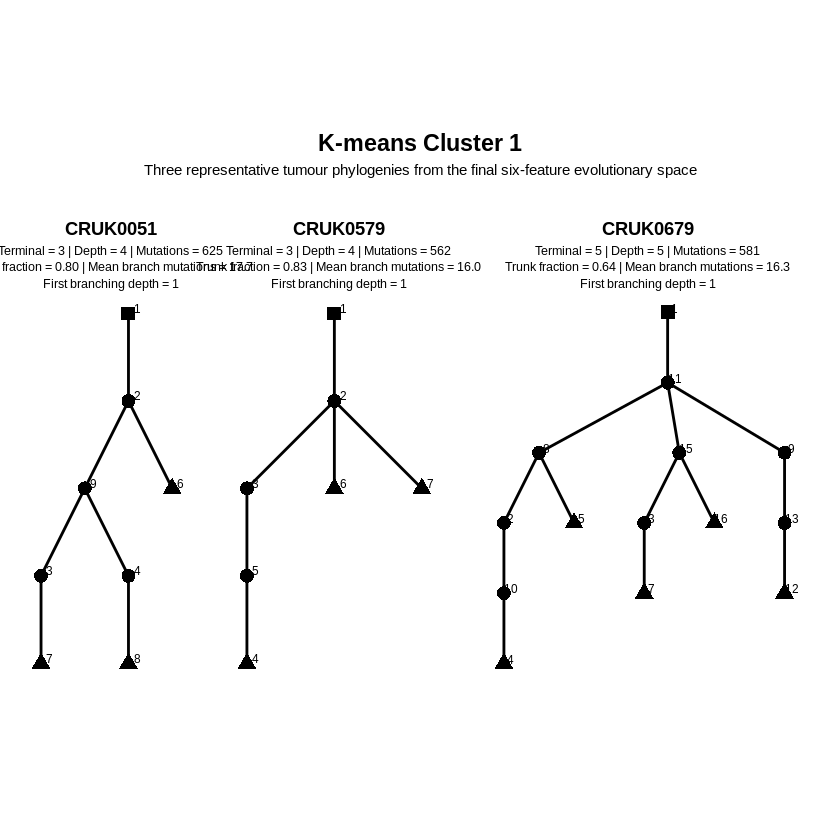

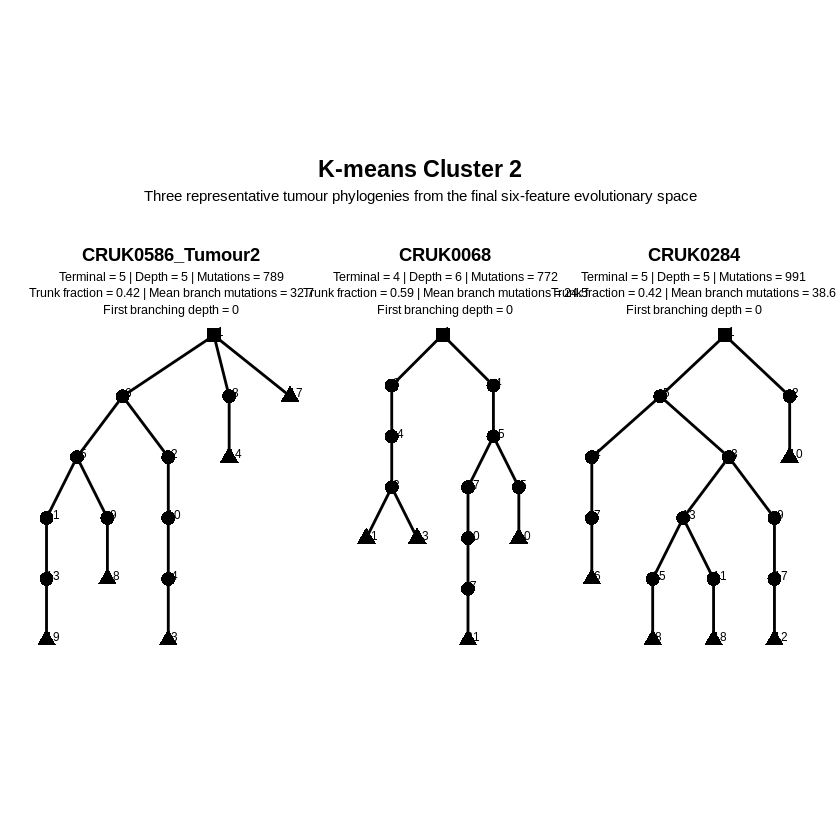

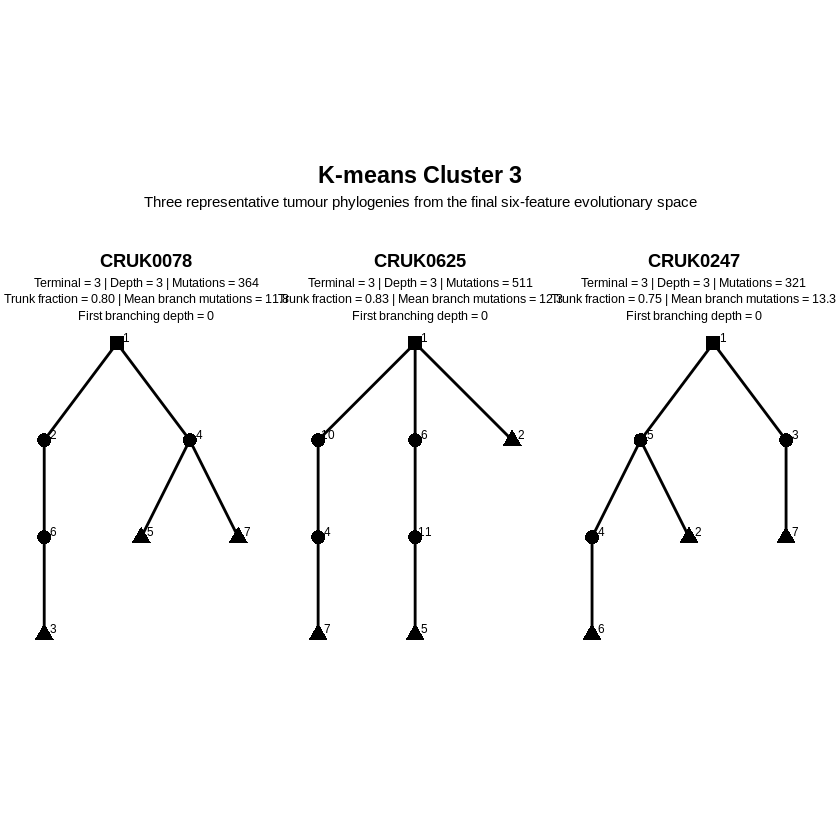


FINAL 6-FEATURE REPRESENTATIVE TREE ANALYSIS COMPLETE

Representative patients:
# A tibble: 9 × 9
  cluster patient_id   distance_to_centroid n_terminal max_depth total_mutations
    <int> <chr>                       <dbl>      <int>     <dbl>           <dbl>
1       1 CRUK0051                    0.735          3         4             625
2       1 CRUK0579                    0.780          3         4             562
3       1 CRUK0679                    1.06           5         5             581
4       2 CRUK0586_Tu…                0.513          5         5             789
5       2 CRUK0068                    0.634          4         6             772
6       2 CRUK0284                    0.651          5         5             991
7       3 CRUK0078                    0.403          3         3             364
8       3 CRUK0625                    0.453          3         3             511
9       3 CRUK0247                    0.454          3         3             321
# ℹ 3 more

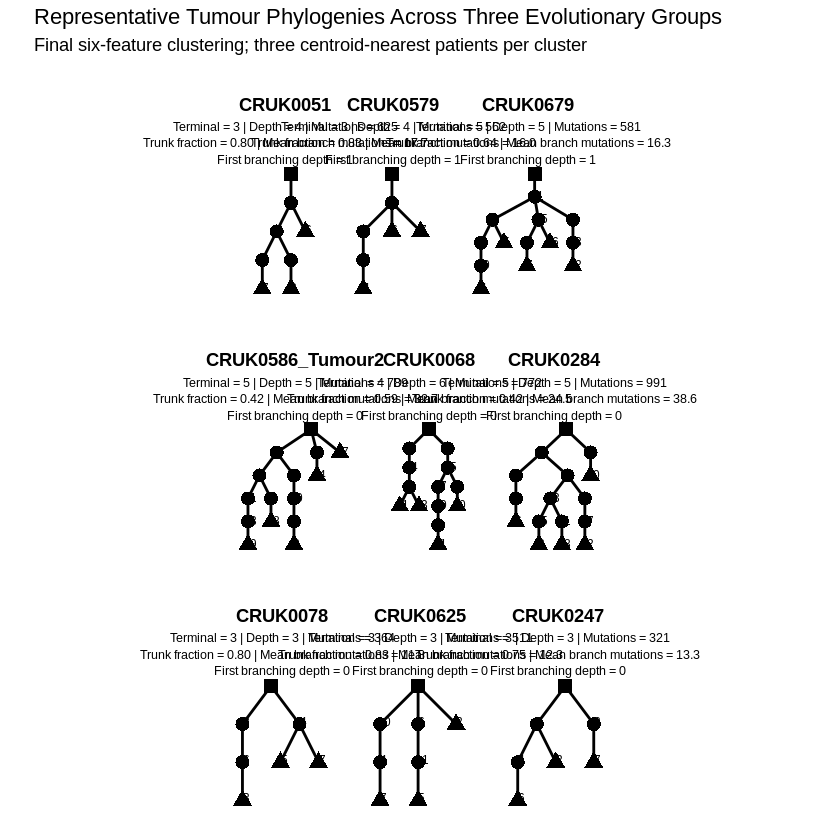

In [ ]:
# ============================================================
# REPRESENTATIVE TREES FOR FINAL 6-FEATURE ANALYSIS
#
# 3 REPRESENTATIVE PATIENTS PER K-MEANS CLUSTER
# 3 CLUSTERS SHOWN SEPARATELY
# UPSIDE-DOWN TREE:
# ROOT AT BOTTOM -> DESCENDANTS / TERMINALS UPWARD
# ============================================================


# ============================================================
# 0. PACKAGES
# ============================================================

required_packages <- c(
  "igraph",
  "dplyr",
  "ggplot2",
  "patchwork"
)

new_packages <- required_packages[
  !(required_packages %in% rownames(installed.packages()))
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}

suppressPackageStartupMessages({
  library(igraph)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
})


# ============================================================
# 1. CHECK REQUIRED OBJECTS
# ============================================================

required_objects <- c(
  "scaled_features",
  "cluster_kmeans",
  "standardized_trees_valid",
  "patient_level_feature_matrix"
)

missing_objects <- required_objects[
  !vapply(
    required_objects,
    exists,
    logical(1)
  )
]

if (length(missing_objects) > 0) {

  stop(
    paste0(
      "Missing objects: ",
      paste(
        missing_objects,
        collapse = ", "
      )
    )
  )
}


# ============================================================
# 2. PREPARE K-MEANS DATA
# ============================================================

kmeans_data <- as.data.frame(
  scaled_features,
  check.names = FALSE
)

kmeans_data$patient_id <-
  rownames(scaled_features)

kmeans_data$cluster <-
  as.integer(cluster_kmeans)


cat(
  "\n========================================\n"
)

cat(
  "K-MEANS CLUSTER SIZES\n"
)

cat(
  "========================================\n"
)

print(
  table(
    kmeans_data$cluster
  )
)


# ============================================================
# 3. IDENTIFY SIX FEATURE COLUMNS
# ============================================================

final_six_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

feature_cols <- intersect(
  final_six_features,
  colnames(kmeans_data)
)

if (length(feature_cols) != 6) {

  stop(
    paste0(
      "Expected 6 scaled features, but found ",
      length(feature_cols),
      ". Found: ",
      paste(feature_cols, collapse = ", ")
    )
  )
}


# ============================================================
# 4. CALCULATE K-MEANS CENTROIDS
# ============================================================

kmeans_centroids <- kmeans_data %>%

  group_by(
    cluster
  ) %>%

  summarise(

    across(
      all_of(feature_cols),
      ~ mean(.x, na.rm = TRUE)
    ),

    .groups = "drop"
  )


cat(
  "\n========================================\n"
)

cat(
  "K-MEANS CENTROIDS\n"
)

cat(
  "========================================\n"
)

print(
  kmeans_centroids
)


# ============================================================
# 5. DISTANCE FROM OWN CLUSTER CENTROID
# ============================================================

calculate_centroid_distance <- function(cluster_id) {

  current_cluster <- kmeans_data %>%
    filter(
      cluster == cluster_id
    )


  centroid_row <- kmeans_centroids %>%
    filter(
      cluster == cluster_id
    )


  centroid_vector <- centroid_row %>%
    select(
      all_of(feature_cols)
    ) %>%
    unlist(
      use.names = FALSE
    )


  X_current <- as.matrix(
    current_cluster[
      ,
      feature_cols,
      drop = FALSE
    ]
  )


  difference_matrix <- sweep(
    X_current,
    MARGIN = 2,
    STATS = centroid_vector,
    FUN = "-"
  )


  distances <- sqrt(
    rowSums(
      difference_matrix^2
    )
  )


  current_cluster$distance_to_centroid <-
    distances


  current_cluster
}


# ============================================================
# 6. CALCULATE DISTANCES FOR ALL CLUSTERS
# ============================================================

cluster_ids <- sort(
  unique(
    kmeans_data$cluster
  )
)


all_centroid_distances <- bind_rows(

  lapply(
    cluster_ids,
    calculate_centroid_distance
  )
)


# ============================================================
# 7. SELECT 3 REPRESENTATIVE PATIENTS PER CLUSTER
# ============================================================

n_representatives <- 3


representative_kmeans <- all_centroid_distances %>%

  group_by(
    cluster
  ) %>%

  arrange(
    distance_to_centroid,
    .by_group = TRUE
  ) %>%

  slice_head(
    n = n_representatives
  ) %>%

  ungroup() %>%

  select(
    patient_id,
    cluster,
    distance_to_centroid
  )


cat(
  "\n========================================\n"
)

cat(
  "REPRESENTATIVE PATIENTS\n"
)

cat(
  "========================================\n"
)

print(
  representative_kmeans,
  n = Inf
)


# ============================================================
# 8. ADD SIX-FEATURE INFORMATION
# ============================================================

representative_table <- representative_kmeans %>%

  left_join(
    patient_level_feature_matrix,
    by = "patient_id"
  ) %>%

  transmute(

    cluster =
      cluster,

    patient_id =
      patient_id,

    distance_to_centroid =
      distance_to_centroid,

    n_terminal =
      n_terminal,

    max_depth =
      max_depth,

    total_mutations =
      total_mutations,

    trunk_mutation_fraction =
      trunk_mutation_fraction,

    mean_branch_mutations =
      mean_branch_mutations,

    first_branching_depth =
      first_branching_depth
  ) %>%

  arrange(
    cluster,
    distance_to_centroid
  )


cat(
  "\n========================================\n"
)

cat(
  "REPRESENTATIVE TREE INFORMATION\n"
)

cat(
  "========================================\n"
)

print(
  representative_table,
  n = Inf
)


# ============================================================
# 9. CHECK TREE AVAILABILITY
# ============================================================

tree_names <- names(
  standardized_trees_valid
)

if (is.null(tree_names)) {

  stop(
    "standardized_trees_valid has no patient IDs."
  )
}


missing_tree_ids <- setdiff(

  representative_table$patient_id,

  tree_names
)


if (length(missing_tree_ids) > 0) {

  stop(
    paste0(
      "Tree missing for: ",
      paste(
        missing_tree_ids,
        collapse = ", "
      )
    )
  )
}


# ============================================================
# 10. FUNCTION TO PREPARE ONE TREE
# UPSIDE-DOWN:
# root at bottom, descendants upward
# ============================================================

prepare_tree_data <- function(pid) {

  std_tree <-
    standardized_trees_valid[[pid]]


  if (is.null(std_tree)) {

    stop(
      paste(
        "Tree object not found:",
        pid
      )
    )
  }


  g <- std_tree$graph


  if (
    is.null(g) ||
    igraph::vcount(g) == 0
  ) {

    stop(
      paste(
        "Invalid graph for:",
        pid
      )
    )
  }


  root <- as.character(
    std_tree$trunk
  )[1]


  root_index <- match(
    root,
    igraph::V(g)$name
  )


  if (is.na(root_index)) {

    stop(
      paste(
        "Root not found for:",
        pid
      )
    )
  }


  # ----------------------------------------------------------
  # igraph tree layout
  # ----------------------------------------------------------

  layout_matrix <- igraph::layout_as_tree(

    g,

    root = root_index,

    circular = FALSE
  )


  # ==========================================================
  # IMPORTANT ORIENTATION CHANGE
  #
  # OLD:
  # y = -layout_matrix[,2]
  #
  # NEW UPSIDE-DOWN:
  # y = layout_matrix[,2]
  #
  # Root will be at bottom.
  # Descendants will extend upward.
  # ==========================================================

  node_df <- data.frame(

    node =
      as.character(
        igraph::V(g)$name
      ),

    x =
      layout_matrix[, 1],

    y =
      layout_matrix[, 2],

    stringsAsFactors =
      FALSE
  )


  # ----------------------------------------------------------
  # Node metadata
  # ----------------------------------------------------------

  if (
    !is.null(std_tree$nodes) &&
    "cluster" %in% colnames(std_tree$nodes)
  ) {

    node_info <- std_tree$nodes %>%

      transmute(

        node =
          as.character(cluster),

        node_type = if (
          "node_type" %in%
          colnames(std_tree$nodes)
        ) {

          as.character(node_type)

        } else {

          NA_character_
        }
      )


    node_df <- node_df %>%

      left_join(
        node_info,
        by = "node"
      )

  } else {

    node_df$node_type <-
      NA_character_
  }


  # ----------------------------------------------------------
  # Reconstruct node type if necessary
  # ----------------------------------------------------------

  if (all(is.na(node_df$node_type))) {

    out_degree <- igraph::degree(
      g,
      mode = "out"
    )


    node_df$node_type <- ifelse(

      node_df$node == root,

      "Trunk",

      ifelse(
        out_degree == 0,
        "Terminal",
        "Internal"
      )
    )
  }


  # Make sure root is always marked as trunk
  node_df$node_type[
    node_df$node == root
  ] <- "Trunk"


  # ----------------------------------------------------------
  # Edge table
  # ----------------------------------------------------------

  edge_df <- igraph::as_data_frame(
    g,
    what = "edges"
  )

  edge_df <- as.data.frame(
    edge_df,
    stringsAsFactors = FALSE
  )

  edge_df$from <-
    as.character(edge_df$from)

  edge_df$to <-
    as.character(edge_df$to)


  from_coordinates <- node_df %>%

    transmute(
      from = node,
      x_from = x,
      y_from = y
    )


  to_coordinates <- node_df %>%

    transmute(
      to = node,
      x_to = x,
      y_to = y
    )


  edge_df <- edge_df %>%

    left_join(
      from_coordinates,
      by = "from"
    ) %>%

    left_join(
      to_coordinates,
      by = "to"
    )


  return(

    list(
      node = node_df,
      edge = edge_df
    )
  )
}


# ============================================================
# 11. FUNCTION TO PLOT ONE REPRESENTATIVE TREE
#
# Paper-like clean representation
# Root = square
# Internal = circle
# Terminal = triangle
# ============================================================

plot_representative_tree_6f <- function(
  pid,
  cluster_id
) {

  tree_data <- prepare_tree_data(
    pid
  )


  node_df <-
    tree_data$node

  edge_df <-
    tree_data$edge


  patient_info <- representative_table %>%

    filter(
      patient_id == pid
    ) %>%

    slice(1)


  terminal_text <-
    round(
      patient_info$n_terminal
    )


  depth_text <-
    round(
      patient_info$max_depth
    )


  mutation_text <-
    round(
      patient_info$total_mutations
    )


  trunk_text <-
    sprintf(
      "%.2f",
      patient_info$trunk_mutation_fraction
    )


  branch_text <-
    sprintf(
      "%.1f",
      patient_info$mean_branch_mutations
    )


  branching_depth_text <-
    sprintf(
      "%.0f",
      patient_info$first_branching_depth
    )


  ggplot() +

    # --------------------------------------------------------
    # Tree edges
    # --------------------------------------------------------

    geom_segment(

      data = edge_df,

      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to
      ),

      linewidth = 0.8,

      lineend = "round"
    ) +

    # --------------------------------------------------------
    # Nodes
    # --------------------------------------------------------

    geom_point(

      data = node_df,

      aes(
        x = x,
        y = y,
        shape = node_type
      ),

      size = 3.6
    ) +

    # --------------------------------------------------------
    # Clone labels
    # --------------------------------------------------------

    geom_text(

      data = node_df,

      aes(
        x = x,
        y = y,
        label = node
      ),

      nudge_x = 0.10,

      nudge_y = 0.06,

      size = 2.5,

      check_overlap = TRUE
    ) +

    # --------------------------------------------------------
    # Same graphical logic as paper
    # --------------------------------------------------------

    scale_shape_manual(

      values = c(

        "Trunk" = 15,

        "Internal" = 16,

        "Terminal" = 17
      )
    ) +

    # --------------------------------------------------------
    # Patient name + 6 feature information
    # --------------------------------------------------------

    labs(

      title =
        pid,

      subtitle =
        paste0(

          "Terminal = ",
          terminal_text,

          " | Depth = ",
          depth_text,

          " | Mutations = ",
          mutation_text,

          "\nTrunk fraction = ",
          trunk_text,

          " | Mean branch mutations = ",
          branch_text,

          "\nFirst branching depth = ",
          branching_depth_text
        ),

      x = NULL,

      y = NULL
    ) +

    coord_equal(
      clip = "off"
    ) +

    theme_void() +

    theme(

      plot.title =
        element_text(
          face = "bold",
          size = 11,
          hjust = 0.5
        ),

      plot.subtitle =
        element_text(
          size = 7.5,
          hjust = 0.5,
          lineheight = 1.10
        ),

      legend.position =
        "none",

      plot.margin =
        margin(
          15,
          15,
          15,
          15
        )
    )
}


# ============================================================
# 12. GENERATE ALL NINE TREE PLOTS
# ============================================================

tree_plots <- vector(
  mode = "list",
  length = nrow(
    representative_table
  )
)


for (
  i in seq_len(
    nrow(
      representative_table
    )
  )
) {

  current_pid <-
    representative_table$patient_id[i]


  current_cluster <-
    representative_table$cluster[i]


  tree_plots[[i]] <-

    plot_representative_tree_6f(

      pid =
        current_pid,

      cluster_id =
        current_cluster
    )
}


# ============================================================
# 13. CREATE ONE SEPARATE FIGURE FOR EACH CLUSTER
# ============================================================

cluster_figures <- list()


for (cl in cluster_ids) {

  current_indices <- which(
    representative_table$cluster == cl
  )


  current_plots <- tree_plots[
    current_indices
  ]


  cluster_figures[[as.character(cl)]] <-

    patchwork::wrap_plots(

      current_plots,

      nrow = 1
    ) +

    patchwork::plot_annotation(

      title =
        paste0(
          "K-means Cluster ",
          cl
        ),

      subtitle =
        "Three representative tumour phylogenies from the final six-feature evolutionary space",

      theme = theme(

        plot.title =
          element_text(
            face = "bold",
            size = 14,
            hjust = 0.5
          ),

        plot.subtitle =
          element_text(
            size = 9,
            hjust = 0.5
          )
      )
    )
}


# ============================================================
# 14. DISPLAY CLUSTER 1
# ============================================================

print(
  cluster_figures[["1"]]
)


# ============================================================
# 15. DISPLAY CLUSTER 2
# ============================================================

print(
  cluster_figures[["2"]]
)


# ============================================================
# 16. DISPLAY CLUSTER 3
# ============================================================

print(
  cluster_figures[["3"]]
)


# ============================================================
# 17. SAVE EACH CLUSTER SEPARATELY
# ============================================================

for (cl in cluster_ids) {

  current_figure <-
    cluster_figures[[as.character(cl)]]


  # PNG
  ggsave(

    filename =
      paste0(
        "Final6_Cluster_",
        cl,
        "_Representative_Trees_UpsideDown.png"
      ),

    plot =
      current_figure,

    width = 15,

    height = 5,

    units = "in",

    dpi = 600,

    bg = "white"
  )


  # PDF
  ggsave(

    filename =
      paste0(
        "Final6_Cluster_",
        cl,
        "_Representative_Trees_UpsideDown.pdf"
      ),

    plot =
      current_figure,

    width = 15,

    height = 5,

    units = "in",

    bg = "white"
  )
}


# ============================================================
# 18. OPTIONAL:
# COMBINE ALL THREE CLUSTERS IN ONE FIGURE
# ============================================================

all_clusters_figure <- (

  cluster_figures[["1"]] /

  cluster_figures[["2"]] /

  cluster_figures[["3"]]

) +

  patchwork::plot_annotation(

    title =
      "Representative Tumour Phylogenies Across Three Evolutionary Groups",

    subtitle =
      "Final six-feature clustering; three centroid-nearest patients per cluster"
  )


print(
  all_clusters_figure
)


# ============================================================
# 19. SAVE COMBINED FIGURE
# ============================================================

ggsave(

  filename =
    "Final6_All_Clusters_Representative_Trees_UpsideDown.pdf",

  plot =
    all_clusters_figure,

  width = 15,

  height = 15,

  units = "in",

  bg = "white"
)


ggsave(

  filename =
    "Final6_All_Clusters_Representative_Trees_UpsideDown.png",

  plot =
    all_clusters_figure,

  width = 15,

  height = 15,

  units = "in",

  dpi = 600,

  bg = "white"
)


# ============================================================
# 20. SAVE REPRESENTATIVE TABLE
# ============================================================

write.csv(

  representative_table,

  "Final6_Representative_Patients_3_Per_Cluster.csv",

  row.names = FALSE
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

cat("\n")
cat("========================================================\n")
cat("FINAL 6-FEATURE REPRESENTATIVE TREE ANALYSIS COMPLETE\n")
cat("========================================================\n")

cat(
  "\nRepresentative patients:\n"
)

print(
  representative_table,
  n = Inf
)

cat(
  "\nSaved separately:\n"
)

cat(
  "Cluster 1 -> Final6_Cluster_1_Representative_Trees_UpsideDown.pdf\n"
)

cat(
  "Cluster 2 -> Final6_Cluster_2_Representative_Trees_UpsideDown.pdf\n"
)

cat(
  "Cluster 3 -> Final6_Cluster_3_Representative_Trees_UpsideDown.pdf\n"
)

cat(
  "\nCombined figure also saved.\n"
)


Representative patients:
# A tibble: 9 × 9
  patient_id   cluster distance_to_centroid n_terminal max_depth total_mutations
  <chr>          <int>                <dbl>      <int>     <dbl>           <dbl>
1 CRUK0051           1                0.735          3         4             625
2 CRUK0579           1                0.780          3         4             562
3 CRUK0679           1                1.06           5         5             581
4 CRUK0586_Tu…       2                0.513          5         5             789
5 CRUK0068           2                0.634          4         6             772
6 CRUK0284           2                0.651          5         5             991
7 CRUK0078           3                0.403          3         3             364
8 CRUK0625           3                0.453          3         3             511
9 CRUK0247           3                0.454          3         3             321
# ℹ 3 more variables: trunk_mutation_fraction <dbl>,
#   mean_bra

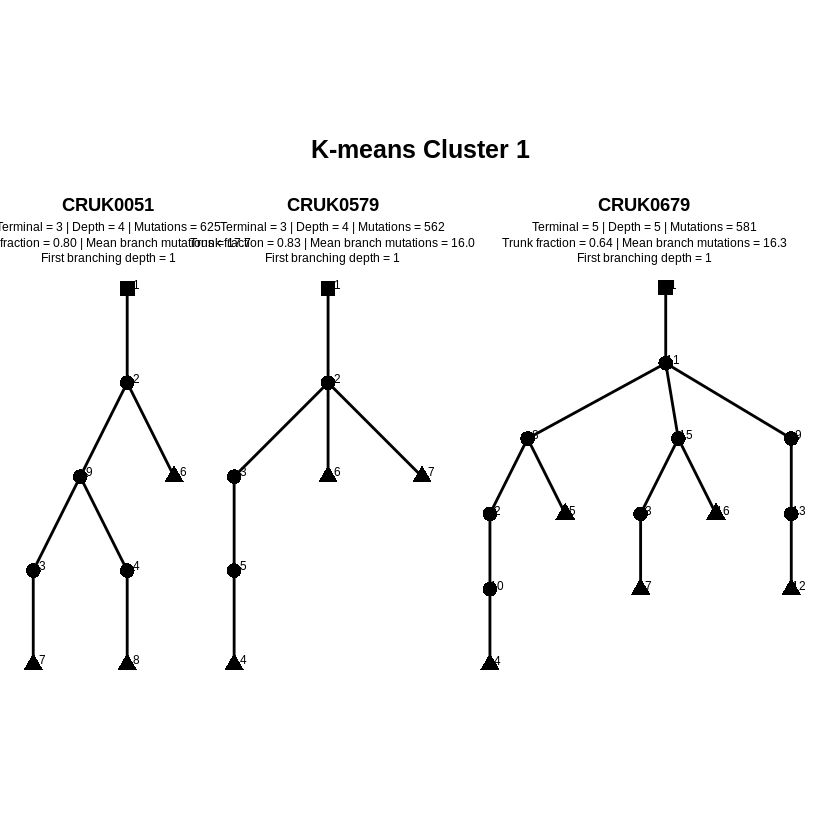

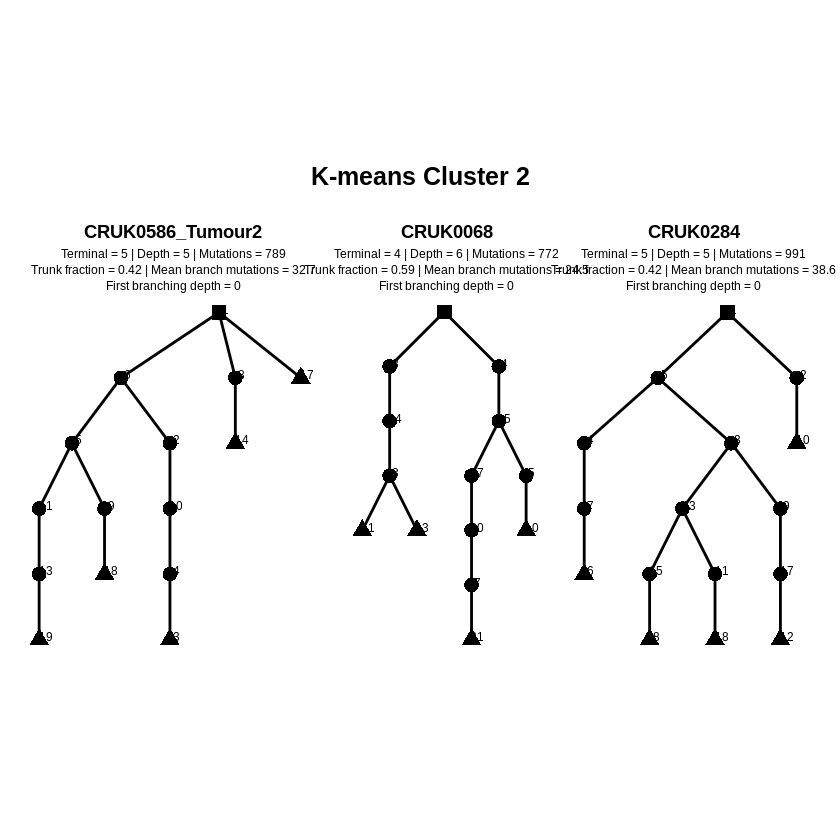


REPRESENTATIVE TREE ANALYSIS COMPLETE

Cluster 1 :
# A tibble: 3 × 9
  patient_id cluster distance_to_centroid n_terminal max_depth total_mutations
  <chr>        <int>                <dbl>      <int>     <dbl>           <dbl>
1 CRUK0051         1                0.735          3         4             625
2 CRUK0579         1                0.780          3         4             562
3 CRUK0679         1                1.06           5         5             581
# ℹ 3 more variables: trunk_mutation_fraction <dbl>,
#   mean_branch_mutations <dbl>, first_branching_depth <dbl>

Cluster 2 :
# A tibble: 3 × 9
  patient_id   cluster distance_to_centroid n_terminal max_depth total_mutations
  <chr>          <int>                <dbl>      <int>     <dbl>           <dbl>
1 CRUK0586_Tu…       2                0.513          5         5             789
2 CRUK0068           2                0.634          4         6             772
3 CRUK0284           2                0.651          5         5  

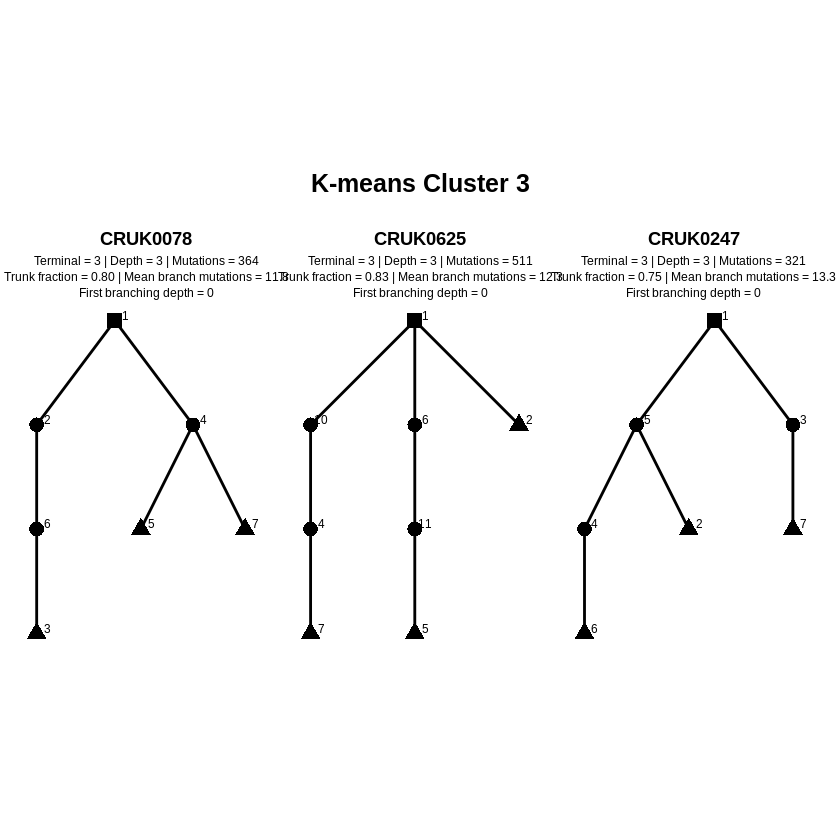

In [ ]:
# ============================================================
# FINAL 6-FEATURE REPRESENTATIVE TREES
#
# 3 REPRESENTATIVE PATIENTS PER CLUSTER
# EACH CLUSTER SEPARATE
# ROOT AT BOTTOM
# TERMINAL CLONES AT TOP
# ============================================================

library(igraph)
library(dplyr)
library(ggplot2)
library(patchwork)


# ============================================================
# 1. REPRESENTATIVE PATIENT TABLE
# Uses existing scaled_features + cluster_kmeans
# ============================================================

kmeans_data <- as.data.frame(
  scaled_features,
  check.names = FALSE
)

kmeans_data$patient_id <- rownames(scaled_features)
kmeans_data$cluster <- as.integer(cluster_kmeans)


feature_cols <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)


# ============================================================
# 2. CALCULATE CLUSTER CENTROIDS
# ============================================================

kmeans_centroids <- kmeans_data %>%
  group_by(cluster) %>%
  summarise(
    across(
      all_of(feature_cols),
      ~ mean(.x, na.rm = TRUE)
    ),
    .groups = "drop"
  )


# ============================================================
# 3. DISTANCE TO OWN CENTROID
# ============================================================

calculate_centroid_distance <- function(cluster_id) {

  idx <- which(
    kmeans_data$cluster == cluster_id
  )

  X_cluster <- as.matrix(
    kmeans_data[
      idx,
      feature_cols,
      drop = FALSE
    ]
  )

  centroid <- as.numeric(
    kmeans_centroids[
      kmeans_centroids$cluster == cluster_id,
      feature_cols
    ]
  )

  difference_matrix <- sweep(
    X_cluster,
    MARGIN = 2,
    STATS = centroid,
    FUN = "-"
  )

  distances <- sqrt(
    rowSums(
      difference_matrix^2
    )
  )

  data.frame(
    patient_id = kmeans_data$patient_id[idx],
    cluster = cluster_id,
    distance_to_centroid = distances
  )
}


cluster_ids <- sort(
  unique(kmeans_data$cluster)
)


all_distances <- bind_rows(
  lapply(
    cluster_ids,
    calculate_centroid_distance
  )
)


# ============================================================
# 4. SELECT 3 REPRESENTATIVE PATIENTS PER CLUSTER
# ============================================================

representative_patients <- all_distances %>%
  group_by(cluster) %>%
  arrange(
    distance_to_centroid,
    .by_group = TRUE
  ) %>%
  slice_head(n = 3) %>%
  ungroup()


# ============================================================
# 5. ADD ORIGINAL SIX FEATURE VALUES
# ============================================================

representative_table <- representative_patients %>%
  left_join(
    patient_level_feature_matrix,
    by = "patient_id"
  ) %>%
  select(
    patient_id,
    cluster,
    distance_to_centroid,
    n_terminal,
    max_depth,
    total_mutations,
    trunk_mutation_fraction,
    mean_branch_mutations,
    first_branching_depth
  ) %>%
  arrange(
    cluster,
    distance_to_centroid
  )


cat("\nRepresentative patients:\n")

print(
  representative_table,
  n = Inf
)


# ============================================================
# 6. FUNCTION TO PREPARE ACTUAL TREE
#
# ROOT AT BOTTOM
# DESCENDANTS / TERMINALS UPWARD
# ============================================================

prepare_tree <- function(pid) {

  tree_obj <- standardized_trees_valid[[pid]]

  if (is.null(tree_obj)) {
    stop(
      paste(
        "Tree not found:",
        pid
      )
    )
  }


  g <- tree_obj$graph

  if (
    is.null(g) ||
    igraph::vcount(g) == 0
  ) {
    stop(
      paste(
        "Invalid graph:",
        pid
      )
    )
  }


  root <- as.character(
    tree_obj$trunk
  )[1]


  root_index <- match(
    root,
    igraph::V(g)$name
  )


  if (is.na(root_index)) {
    stop(
      paste(
        "Root not found:",
        pid
      )
    )
  }


  # ==========================================================
  # TREE LAYOUT
  # ==========================================================

  layout_matrix <- igraph::layout_as_tree(
    g,
    root = root_index,
    circular = FALSE
  )


  # ==========================================================
  # ROOT AT BOTTOM
  #
  # IMPORTANT:
  # Use positive layout y.
  # Do NOT use -layout_matrix[,2]
  # ==========================================================

  node_df <- data.frame(
    node = as.character(
      igraph::V(g)$name
    ),

    x = layout_matrix[, 1],

    y = layout_matrix[, 2],

    stringsAsFactors = FALSE
  )


  # ==========================================================
  # NODE TYPES
  # ==========================================================

  out_degree <- igraph::degree(
    g,
    mode = "out"
  )


  node_df$node_type <- ifelse(

    node_df$node == root,

    "Trunk",

    ifelse(
      out_degree == 0,
      "Terminal",
      "Internal"
    )
  )


  # ==========================================================
  # EDGE TABLE
  #
  # IMPORTANT FIX:
  # explicitly use igraph::as_data_frame()
  # ==========================================================

  edge_df <- igraph::as_data_frame(
    g,
    what = "edges"
  )


  edge_df <- base::as.data.frame(
    edge_df,
    stringsAsFactors = FALSE
  )


  edge_df$from <- as.character(
    edge_df$from
  )

  edge_df$to <- as.character(
    edge_df$to
  )


  # ==========================================================
  # ADD NODE COORDINATES TO EDGES
  # ==========================================================

  from_coordinates <- node_df %>%
    transmute(
      from = node,
      x_from = x,
      y_from = y
    )


  to_coordinates <- node_df %>%
    transmute(
      to = node,
      x_to = x,
      y_to = y
    )


  edge_df <- edge_df %>%

    left_join(
      from_coordinates,
      by = "from"
    ) %>%

    left_join(
      to_coordinates,
      by = "to"
    )


  # Check
  if (
    anyNA(edge_df$x_from) ||
    anyNA(edge_df$y_from) ||
    anyNA(edge_df$x_to) ||
    anyNA(edge_df$y_to)
  ) {

    stop(
      paste(
        "Edge-coordinate matching failed:",
        pid
      )
    )
  }


  return(
    list(
      nodes = node_df,
      edges = edge_df
    )
  )
}


# ============================================================
# 7. FUNCTION TO PLOT ONE TREE
# ============================================================

plot_one_tree <- function(
  pid,
  cluster_id
) {

  tree_data <- prepare_tree(
    pid
  )


  node_df <- tree_data$nodes
  edge_df <- tree_data$edges


  info <- representative_table %>%
    filter(
      patient_id == pid
    ) %>%
    slice(1)


  subtitle_text <- paste0(

    "Terminal = ",
    info$n_terminal,

    " | Depth = ",
    info$max_depth,

    " | Mutations = ",
    round(
      info$total_mutations
    ),

    "\nTrunk fraction = ",
    sprintf(
      "%.2f",
      info$trunk_mutation_fraction
    ),

    " | Mean branch mutations = ",
    sprintf(
      "%.1f",
      info$mean_branch_mutations
    ),

    "\nFirst branching depth = ",
    info$first_branching_depth
  )


  p <- ggplot() +

    # --------------------------------------------------------
    # EDGES
    # --------------------------------------------------------

    geom_segment(
      data = edge_df,

      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to
      ),

      linewidth = 0.8,
      lineend = "round"
    ) +

    # --------------------------------------------------------
    # NODES
    # --------------------------------------------------------

    geom_point(
      data = node_df,

      aes(
        x = x,
        y = y,
        shape = node_type
      ),

      size = 3.8
    ) +

    # --------------------------------------------------------
    # NODE LABELS
    # --------------------------------------------------------

    geom_text(
      data = node_df,

      aes(
        x = x,
        y = y,
        label = node
      ),

      nudge_x = 0.10,
      nudge_y = 0.05,

      size = 2.5,

      check_overlap = TRUE
    ) +

    # --------------------------------------------------------
    # SHAPES
    #
    # Trunk/root = square
    # Internal   = circle
    # Terminal   = triangle
    # --------------------------------------------------------

    scale_shape_manual(
      values = c(
        "Trunk" = 15,
        "Internal" = 16,
        "Terminal" = 17
      )
    ) +

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    labs(
      title = pid,
      subtitle = subtitle_text,
      x = NULL,
      y = NULL
    ) +

    coord_equal(
      clip = "off"
    ) +

    theme_void() +

    theme(

      plot.title = element_text(
        face = "bold",
        size = 11,
        hjust = 0.5
      ),

      plot.subtitle = element_text(
        size = 7.3,
        hjust = 0.5,
        lineheight = 1.08
      ),

      legend.position = "none",

      plot.margin = margin(
        10,
        10,
        10,
        10
      )
    )


  return(p)
}


# ============================================================
# 8. CREATE TREE PLOTS FOR ALL 9 PATIENTS
# ============================================================

tree_plots <- list()


for (
  i in seq_len(
    nrow(
      representative_table
    )
  )
) {

  pid <- representative_table$patient_id[i]

  cl <- representative_table$cluster[i]


  tree_plots[[pid]] <- plot_one_tree(
    pid = pid,
    cluster_id = cl
  )
}


# ============================================================
# 9. CREATE SEPARATE FIGURE FOR EACH CLUSTER
# ============================================================

cluster_figures <- list()


for (cl in cluster_ids) {

  current_patients <- representative_table %>%
    filter(
      cluster == cl
    ) %>%
    pull(
      patient_id
    )


  current_plots <- tree_plots[
    current_patients
  ]


  cluster_figures[[as.character(cl)]] <-

    patchwork::wrap_plots(
      current_plots,
      nrow = 1
    ) +

    patchwork::plot_annotation(

      title = paste0(
        "K-means Cluster ",
        cl
      ),

      theme = theme(

        plot.title = element_text(
          face = "bold",
          size = 15,
          hjust = 0.5
        )
      )
    )
}


# ============================================================
# 10. DISPLAY CLUSTER 1
# ============================================================

print(
  cluster_figures[["1"]]
)


# ============================================================
# 11. DISPLAY CLUSTER 2
# ============================================================

print(
  cluster_figures[["2"]]
)


# ============================================================
# 12. DISPLAY CLUSTER 3
# ============================================================

print(
  cluster_figures[["3"]]
)


# ============================================================
# 13. SAVE EACH CLUSTER SEPARATELY
# ============================================================

for (cl in cluster_ids) {

  current_figure <-
    cluster_figures[[as.character(cl)]]


  ggsave(

    filename = paste0(
      "Final6_KMeans_Cluster_",
      cl,
      "_Representative_Trees.pdf"
    ),

    plot =
      current_figure,

    width = 12,

    height = 5,

    units = "in",

    bg = "white"
  )


  ggsave(

    filename = paste0(
      "Final6_KMeans_Cluster_",
      cl,
      "_Representative_Trees.png"
    ),

    plot =
      current_figure,

    width = 12,

    height = 5,

    units = "in",

    dpi = 600,

    bg = "white"
  )
}


# ============================================================
# 14. SAVE REPRESENTATIVE PATIENT TABLE
# ============================================================

write.csv(
  representative_table,
  "Final6_KMeans_Representative_Patients.csv",
  row.names = FALSE
)


# ============================================================
# 15. FINAL OUTPUT
# ============================================================

cat("\n========================================\n")
cat("REPRESENTATIVE TREE ANALYSIS COMPLETE\n")
cat("========================================\n")

for (cl in cluster_ids) {

  cat(
    "\nCluster",
    cl,
    ":\n"
  )

  print(
    representative_table %>%
      filter(
        cluster == cl
      )
  )
}